# TLM:UAV — Group-Aware Binary Anomaly Detection with DRU (Final)

## Abstract

This notebook is the **publication-ready evaluation** of the Data Re-uploading (DRU) quantum classifier on the TLM:UAV anomaly-detection dataset. The pipeline is rebuilt from raw multi-sensor logs and applies a strict experimental protocol:

- **Group-aware split (B2)** over 10 contiguous TimeUS blocks (K=10), with **10 seeds** (`range(10)`); no seed selection, no temporal leakage.
- **Binary task** (normal vs any anomaly) — multiclass under group-aware split is structurally infeasible (only 3 temporal episodes carry disjoint anomaly classes).
- **Three nested feature modes**: `full`, `no_proxy_loose`, `no_proxy_strict` to quantify how much of each model's performance depends on contextual proxies vs. instantaneous physical signal.
- **SMOTETomek**, **MI feature selection**, and **angle scaler** applied **inside** each per-seed pipeline — no global pre-fit.
- **Paired controls** for the hybrid: `XGB-raw / PCA / Poly2 / RandomRBF / DRU-untrained / DRU-trained` under the identical protocol, isolating the contribution of learned quantum representation from generic non-linear expansion.
- **Headline metrics** reported as mean ± std across 10 seeds, per feature mode.
- **Auto-generated report** (`quantum_advantage_report.md`) summarises whether the quantum representation provides measurable value.

The notebook runs end-to-end without manual intervention and persists every CSV, figure, and pickled artifact required to reproduce the analysis.


## §1 — Imports and Global Configuration

In [1]:
import os, sys, logging, json, time, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import chi2_contingency
from itertools import combinations
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
    precision_score, recall_score, roc_auc_score, matthews_corrcoef,
    confusion_matrix, classification_report, ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from imblearn.combine import SMOTETomek
try:
    from xgboost import XGBClassifier; HAS_XGB = True
except ImportError: HAS_XGB = False
try:
    from qiskit_machine_learning.algorithms import QSVC
    from qiskit_machine_learning.kernels import FidelityQuantumKernel
    from qiskit.circuit.library import ZZFeatureMap; HAS_QSVC = True
except ImportError:
    try:
        from qiskit_machine_learning.algorithms.classifiers import QSVC
        from qiskit_machine_learning.kernels import FidelityQuantumKernel
        from qiskit.circuit.library import ZZFeatureMap; HAS_QSVC = True
    except: HAS_QSVC = False
from qdr import DataReuploadingClassifier, DataReuploadingCircuit
from sklearn.exceptions import ConvergenceWarning
# R17: Filter warnings by category instead of suppressing all
warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=FutureWarning, module='sklearn')
# R14: statsmodels for McNemar test (moved from §16)
try:
    from statsmodels.stats.contingency_tables import mcnemar as mcnemar_test
    STATSMODELS_AVAILABLE = True
except ImportError:
    mcnemar_test = None
    STATSMODELS_AVAILABLE = False
    import logging as _log_tmp; _log_tmp.warning('statsmodels not installed. McNemar test will be skipped.')

# ── Matplotlib IEEE style ──────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150, 'font.size': 10, 'axes.titlesize': 11,
    'axes.labelsize': 10, 'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 9, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--'
})

# ── Encoding rotation map ──────────────────────────────────────────────
ROT_MAP = {'rx': 1, 'ry': 1, 'rz': 1, 'rx_ry': 2, 'ry_rz': 2, 'rx_ry_rz': 3}

# ── Repo-root path resolution (portable; overridable via TLM_UAV_ROOT) ──
ROOT        = Path(os.environ.get('TLM_UAV_ROOT', Path.cwd()))
DATA_DIR    = ROOT / 'data'
RESULTS_DIR = ROOT / 'results'
FIGURES_DIR = ROOT / 'figures'

QUICK_MODE = False  # Set False for full publication run

CONFIG = {
    'GLOBAL_SEED': 42,
    'SEEDS': [42] if QUICK_MODE else [7, 42, 99],
    'QUICK_MODE': QUICK_MODE,
    # R16: parametrize dataset path via env var (override with TLM_DATASET)
    # DATASET_DIR defined in §2 via build_merged_dataset()
    # 'DATASET' key removed — raw file merger replaces Fusion_Data.csv
    'RESULT_DIR': Path(os.environ.get('TLM_RESULT_DIR', str(RESULTS_DIR))),
    'TARGET_COL': 'labels',
    'DROP_COLS': [],
    'N_CLASSES': 5,
    'LABEL_NAMES': {0:'Normal',1:'Anomaly-1',2:'Anomaly-2',3:'Anomaly-3',4:'Anomaly-4'},
    'VAL_SIZE': 0.15, 'TEST_SIZE': 0.15,
    'DRU_N_QUBITS': 5,   # = N_CLASSES to avoid observable collisions
    'DRU_N_LAYERS': 2,
    'DRU_ENCODING': 'rx_ry_rz',
    'DRU_ENTANGLEMENT': 'circular',
    'DRU_OPTIMIZER': 'COBYLA',
    'DRU_MAX_ITER': 80 if QUICK_MODE else 200,
    'DRU_TRAIN_BUDGET': 250 if QUICK_MODE else 800,
    'ABLATION_BUDGET': 100 if QUICK_MODE else 300,
    'ABLATION_MAX_ITER': 50 if QUICK_MODE else 120,
    'ABLATION_CONFIGS': [
        {'n_qubits': 4, 'n_layers': 2, 'tag': '4q-L2', 'note': 'obs collision cls0/cls4'},
        {'n_qubits': 5, 'n_layers': 2, 'tag': '5q-L2', 'note': 'baseline (N_CLASSES)'},
        {'n_qubits': 6, 'n_layers': 2, 'tag': '6q-L2', 'note': 'wider'},
        {'n_qubits': 5, 'n_layers': 3, 'tag': '5q-L3', 'note': 'deeper'},
    ],
    'ABLATION_ENTANGLEMENT': ['none', 'linear', 'circular', 'full'],
    'QKERNEL_BUDGET': 100 if QUICK_MODE else 400,
    'CLASSICAL_N_EST': 100,
    # Temporal episode split (replaces random row split)
    'EPISODE_SPLIT': {'train': 0.70, 'val': 0.15, 'test': 0.15},
    'TEMPORAL_GAP_FACTOR': 10,   # gap > factor * median_dt → new episode

    # LSTM
    'LSTM_WINDOW_SIZE': 20,
    'LSTM_EPOCHS': 50 if not QUICK_MODE else 10,
    'LSTM_BATCH':  64,
}
# Derived
CONFIG['N_ROT']        = ROT_MAP[CONFIG['DRU_ENCODING']]
CONFIG['N_DRU_PARAMS'] = CONFIG['DRU_N_LAYERS'] * CONFIG['DRU_N_QUBITS'] * CONFIG['N_ROT']
CONFIG['N_QFEAT']      = CONFIG['DRU_N_QUBITS']  # one dedicated feature per qubit

# Subdirectories
DIRS = {k: CONFIG['RESULT_DIR'] / k
        for k in ('eda','classical','quantum','hybrid','ablation','summary','figures')}
for d in DIRS.values(): d.mkdir(parents=True, exist_ok=True)

# Logging
logging.basicConfig(level=logging.INFO,
    format='%(asctime)s | %(levelname)s | %(message)s',
    handlers=[
        logging.StreamHandler(),
        logging.FileHandler(CONFIG['RESULT_DIR'] / 'experiment.log', mode='w')
    ])
log = logging.getLogger('TLM_DRU')

# Shortcuts
GLOBAL_SEED = CONFIG['GLOBAL_SEED']
SEEDS       = CONFIG['SEEDS']
LABEL_NAMES = CONFIG['LABEL_NAMES']
N_CLASSES   = CONFIG['N_CLASSES']
COLORS_5    = ['#2196F3','#F44336','#FF9800','#9C27B0','#4CAF50']

# R20: Removed global np.random.seed(GLOBAL_SEED); use per-object random_state= explicitly
log.info(f"Config loaded | QUICK_MODE={QUICK_MODE} | SEEDS={SEEDS}")
log.info(f"DRU: {CONFIG['DRU_N_QUBITS']}q · {CONFIG['DRU_N_LAYERS']}L · "
         f"{CONFIG['DRU_ENCODING']} · {CONFIG['N_DRU_PARAMS']} params")
print('CONFIG loaded successfully.')
print(f"  DRU_N_QUBITS={CONFIG['DRU_N_QUBITS']}  N_CLASSES={N_CLASSES}  "
      f"N_DRU_PARAMS={CONFIG['N_DRU_PARAMS']}")

# ══════════════════════════════════════════════════════════════════════
# EXECUTION FLAGS — toggle whole sections on/off without removing code
# ══════════════════════════════════════════════════════════════════════
CONFIG['RUN_CLASSICAL']    = True
CONFIG['RUN_QSVC']         = False   # disabled by default (prohibitive cost)
CONFIG['RUN_DRU']          = True
CONFIG['RUN_HYBRID']       = True
CONFIG['RUN_FAULT3']       = True
CONFIG['RUN_FINAL_REPORT'] = True


2026-05-12 21:52:53,396 | INFO | Config loaded | QUICK_MODE=False | SEEDS=[7, 42, 99]
2026-05-12 21:52:53,397 | INFO | DRU: 5q · 2L · rx_ry_rz · 30 params


CONFIG loaded successfully.
  DRU_N_QUBITS=5  N_CLASSES=5  N_DRU_PARAMS=30


## §2 — Multi-Sensor Dataset Loading

Loads ATT, BARO, BAT, CTUN, MAG, MOTB, PSCD, RATE, XKF1, GPS, IMU, VIBE from raw logs (`ALL_FAIL_LOG_*.csv`). Merges by exact TimeUS where rates match; uses `merge_asof` for GPS, IMU, VIBE. Resolves naming collisions (PSCD.PD/XKF1.PD, PSCD.VD/XKF1.VD) via explicit renames. Final label is computed by per-row majority vote across the per-sensor `labels` columns; ambiguous rows (ties) are dropped.

Episode identifiers (`episode_id`) are derived from gaps in `TimeUS` — used downstream by §3 for the group-aware split feasibility analysis.


2026-05-12 21:52:53,529 | INFO | Dataset directory: <ROOT>/Data/dataset
2026-05-12 21:52:53,532 | INFO | Building merged dataset from raw sensor files...
2026-05-12 21:52:53,542 | INFO |   Loaded ALL_FAIL_LOG_ATT.csv: 4900 rows, 4 features
2026-05-12 21:52:53,549 | INFO |   Loaded ALL_FAIL_LOG_BARO.csv: 4900 rows, 5 features
2026-05-12 21:52:53,557 | INFO |   Loaded ALL_FAIL_LOG_BAT_0.csv: 4900 rows, 7 features
2026-05-12 21:52:53,566 | INFO |   Loaded ALL_FAIL_LOG_CTUN.csv: 4900 rows, 10 features
2026-05-12 21:52:53,573 | INFO |   Loaded ALL_FAIL_LOG_MAG_0.csv: 4900 rows, 6 features
2026-05-12 21:52:53,581 | INFO |   Loaded ALL_FAIL_LOG_MOTB.csv: 4900 rows, 4 features
2026-05-12 21:52:53,590 | INFO |   Loaded ALL_FAIL_LOG_PSCD.csv: 4817 rows, 8 features
2026-05-12 21:52:53,602 | INFO |   Loaded ALL_FAIL_LOG_RATE.csv: 4900 rows, 8 features
2026-05-12 21:52:53,616 | INFO |   Loaded ALL_FAIL_LOG_XKF1_0_Random.csv: 4900 rows, 11 features
2026-05-12 21:52:53,619 | INFO | After exact merge 

Dataset shape: (4817, 83)
Features: 81  |  Target: labels
   Roll  Pitch   Yaw  AEKF  BARO_Alt
0  0.02    0.0  3.51   3.0       0.0
1  0.02    0.0  3.54   3.0       0.0
2  0.02    0.0  3.56   3.0       0.0

Class distribution:
    Class  Count  Pct (%)
   Normal   2463    51.13
Anomaly-1    608    12.62
Anomaly-2    594    12.33
Anomaly-3    482    10.01
Anomaly-4    670    13.91
Imbalance Ratio (IR) = 5.11


,count,mean,std,min,25%,50%,75%,max
Roll,4817.0,1.651819,11.814965,-3.206000e+01,-0.940000,0.180000,1.660000,114.809998
Pitch,4817.0,-7.201518,13.811148,-3.303000e+01,-18.059999,-0.780000,1.310000,60.349998
Yaw,4817.0,185.661621,104.895172,3.300000e-01,93.849998,194.289993,308.559998,359.070007
AEKF,4817.0,3.000000,0.000000,3.000000e+00,3.000000,3.000000,3.000000,3.000000
BARO_Alt,4817.0,15.981549,8.475138,-2.388294e+00,16.372959,19.823940,21.119419,29.645519
...,...,...,...,...,...,...,...,...
abAccZ,4817.0,-7.859873,4.346487,-9.231749e+01,-9.843707,-9.792002,-8.569934,1.306090
abT,4817.0,35.957027,4.160426,2.588661e+01,32.877590,36.884930,39.567558,41.462849
VibeX,4817.0,0.128770,0.367722,6.000000e-07,0.084027,0.117715,0.134741,10.901320
VibeY,4817.0,0.116620,0.246330,6.000000e-07,0.083625,0.116679,0.127169,5.963979


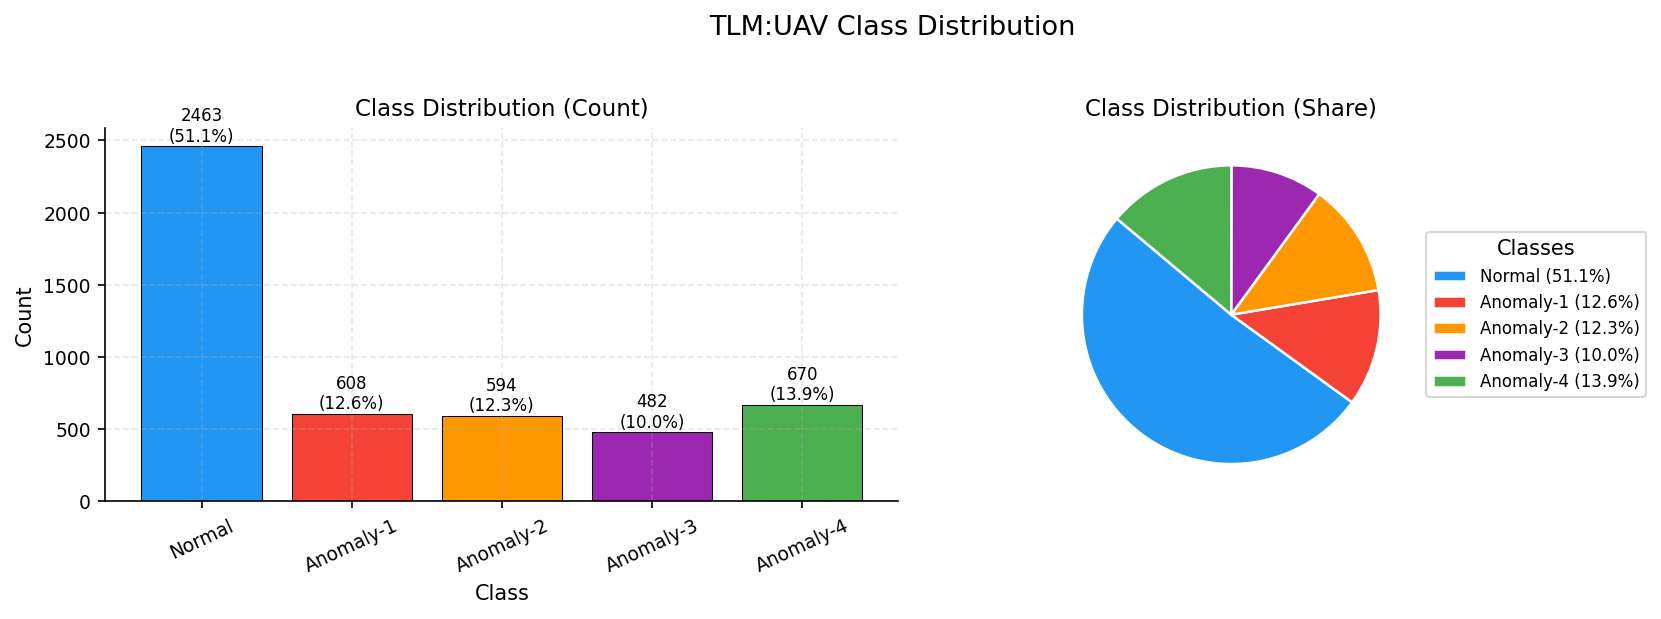

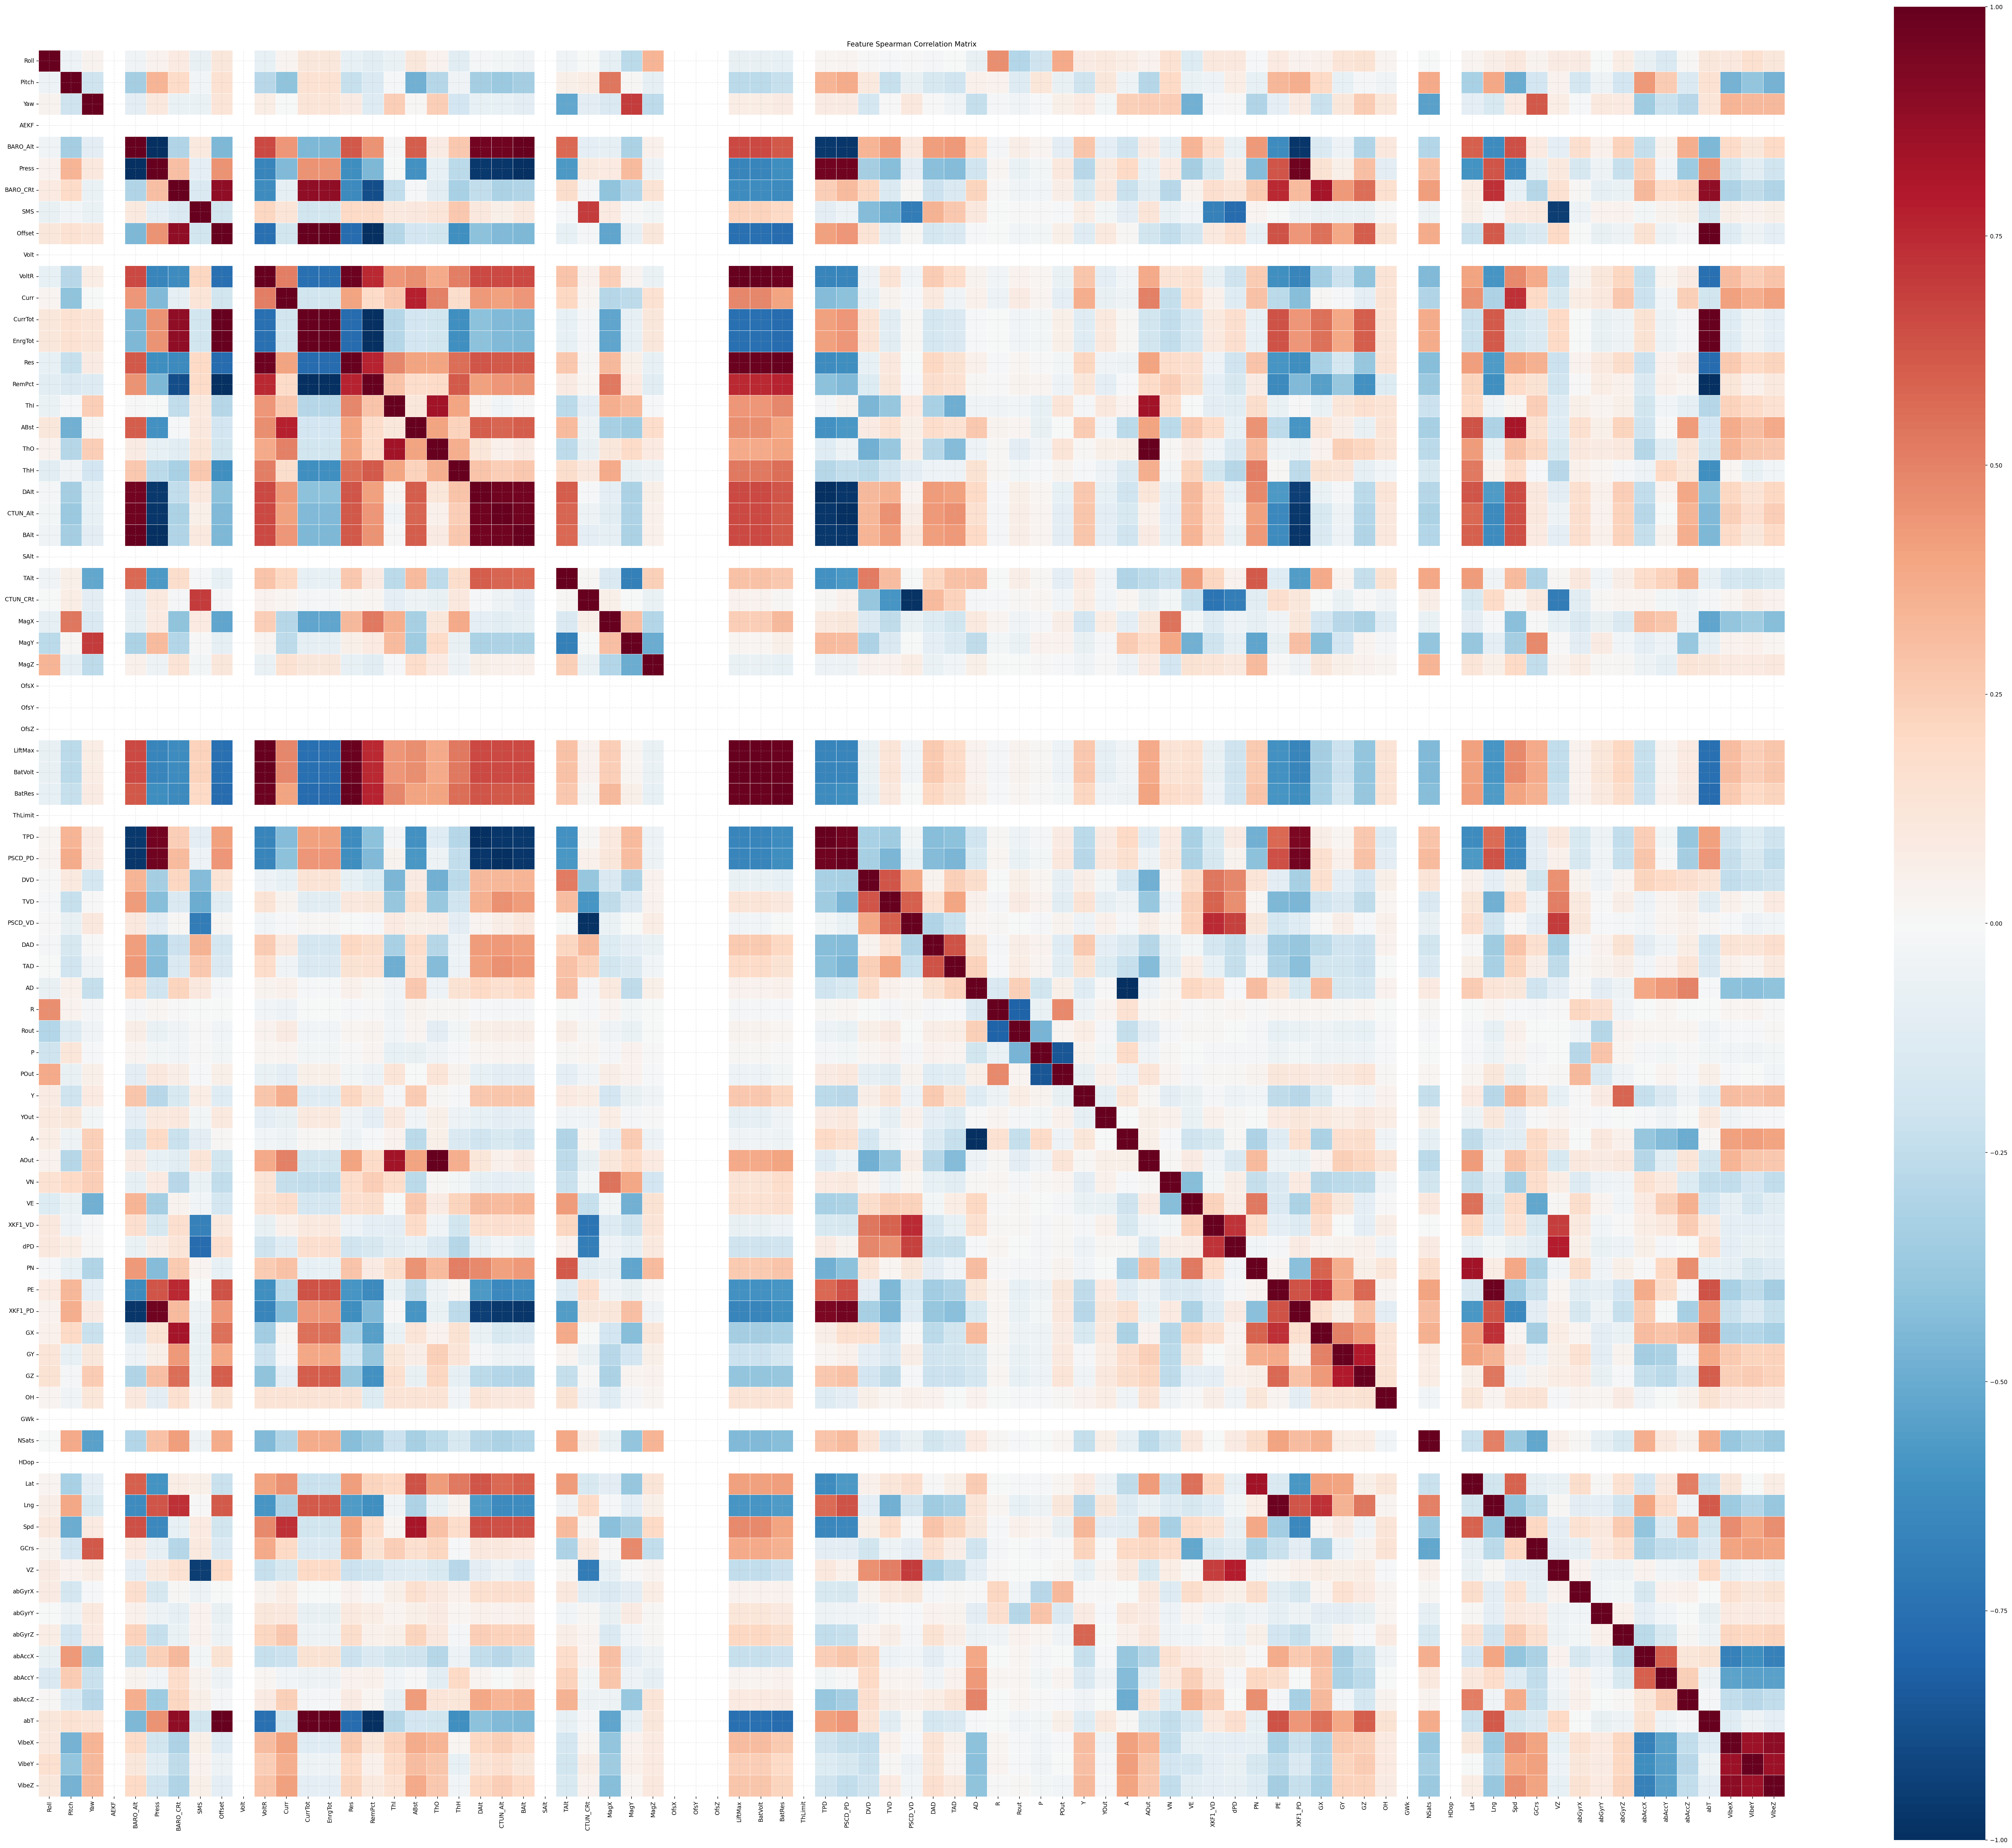

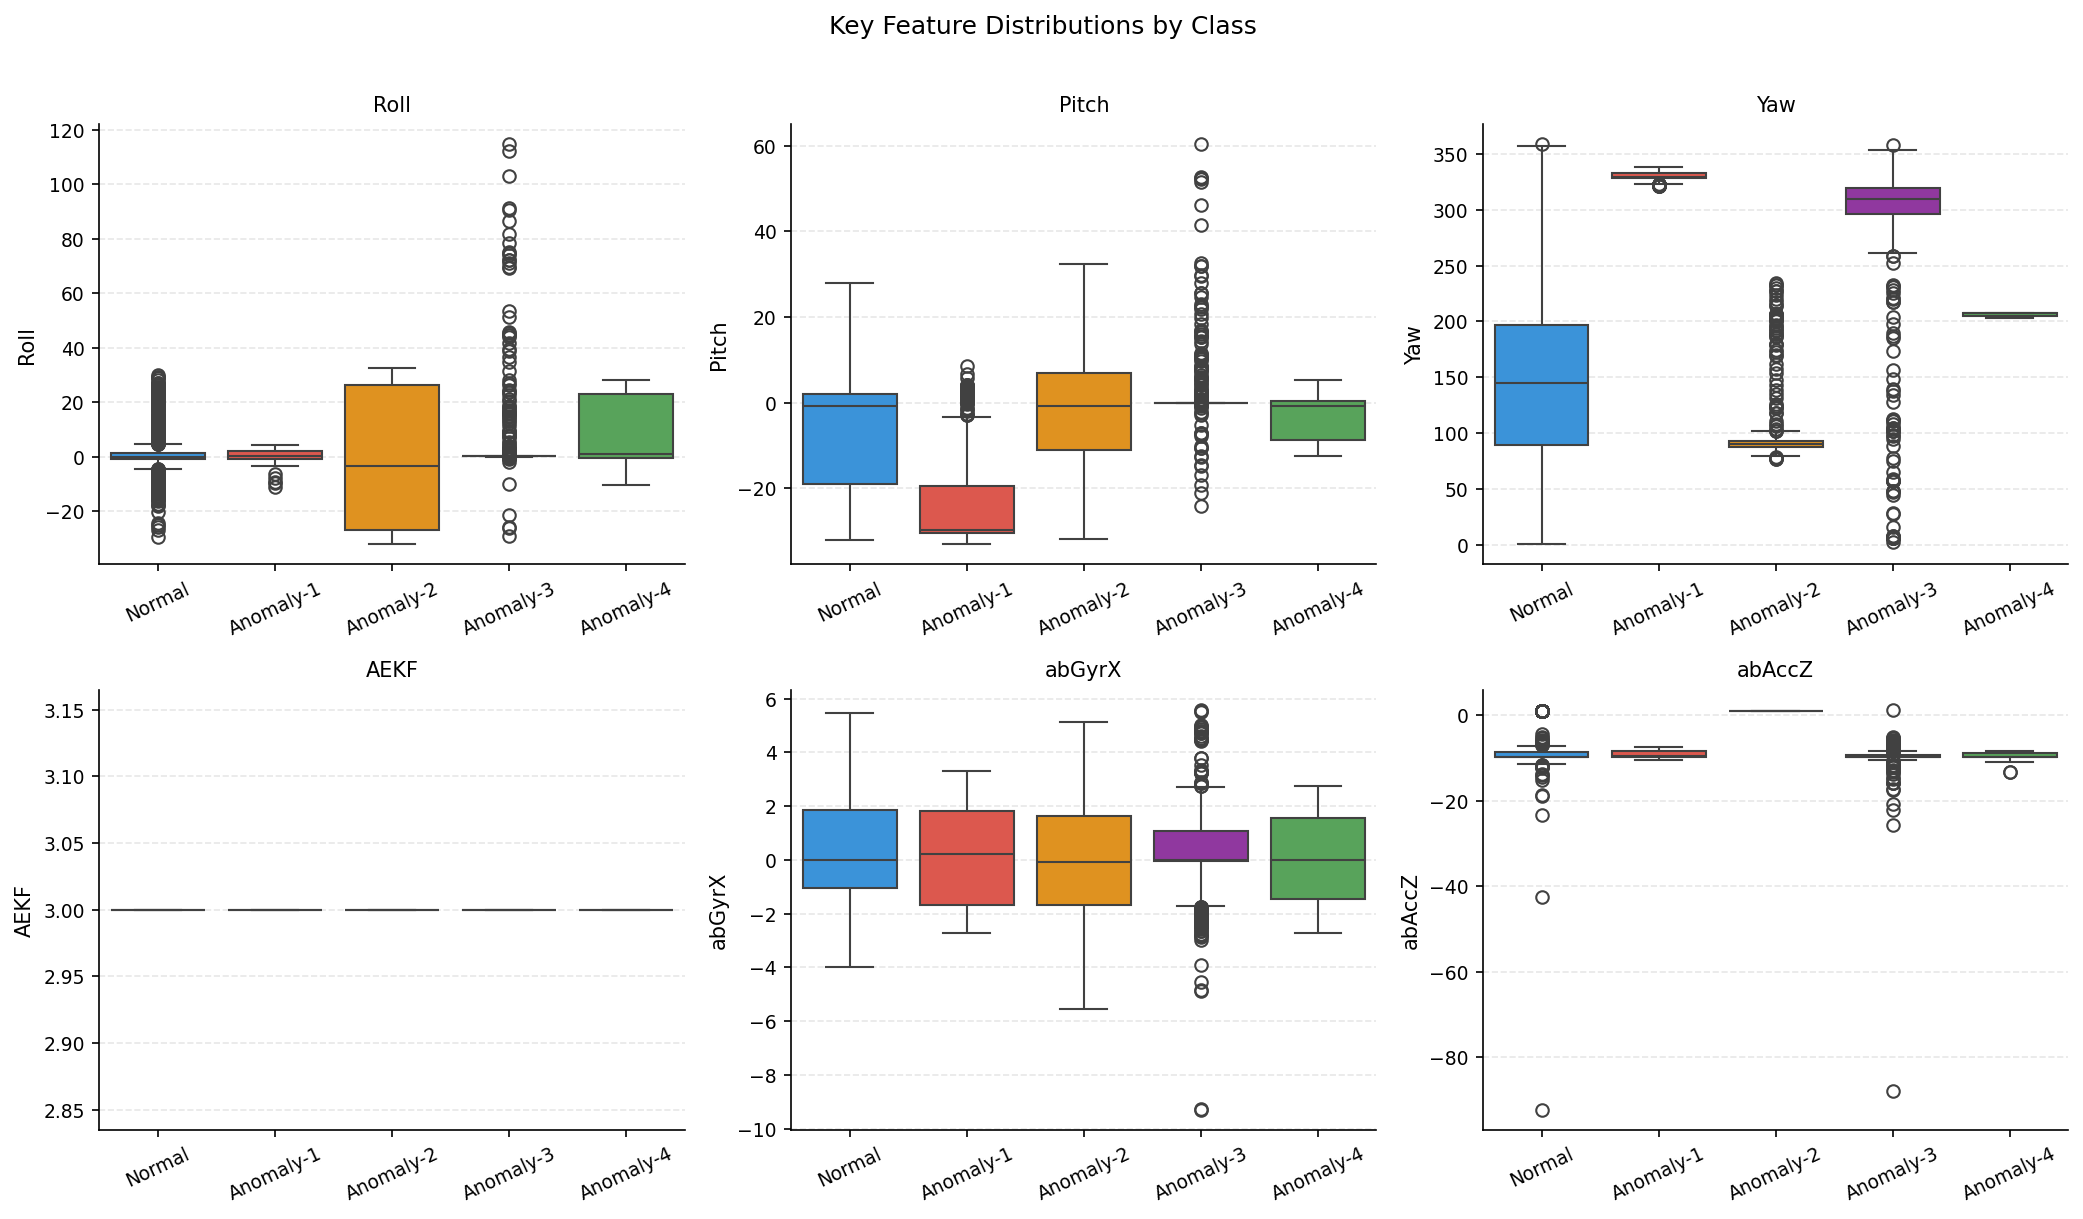


EDA complete — plots saved to <ROOT>/Result/eda


In [2]:
# ══════════════════════════════════════════════════════════════════════
# §2 — Carga multi-archivo y construcción del dataset unificado
# VERSIÓN CORREGIDA — Fixes:
#   BUG-1: load_raw_file retornaba feat_cols sin prefijo aunque renombraba el df
#   BUG-2: columnas 'PD' y 'VD' colisionaban entre PSCD y XKF1 sin prefix= en el loop
# ══════════════════════════════════════════════════════════════════════

from pathlib import Path


DATASET_DIR = Path(os.environ.get('TLM_DATASET_DIR', str(DATA_DIR / 'dataset')))

log.info(f'Dataset directory: {DATASET_DIR}')

# ── Configuración de archivos y columnas a usar ──────────────────────
# NOTA: Las claves 'rename' resuelven las colisiones de nombres entre sensores.
# PSCD y XKF1 comparten 'PD' y 'VD' — se diferencian con prefijo de sensor.
RAW_FILE_CONFIG = {
    'ATT': {
        'path': DATASET_DIR / 'ATT' / 'ALL_FAIL_LOG_ATT.csv',
        'time_col': 'TimeUS',
        'label_col': 'lables',   # typo original en el archivo
        'feature_cols': ['Roll', 'Pitch', 'Yaw', 'AEKF'],
    },
    'BARO': {
        'path': DATASET_DIR / 'BARO' / 'ALL_FAIL_LOG_BARO.csv',
        'time_col': 'TimeUS',
        'label_col': 'labels',
        'feature_cols': ['Alt', 'Press', 'CRt', 'SMS', 'Offset'],
        'rename': {'Alt': 'BARO_Alt', 'CRt': 'BARO_CRt'},
    },
    'BAT': {
        'path': DATASET_DIR / 'BAT' / 'ALL_FAIL_LOG_BAT_0.csv',
        'time_col': 'TimeUS',
        'label_col': 'labels',
        'feature_cols': ['Volt', 'VoltR', 'Curr', 'CurrTot', 'EnrgTot', 'Res', 'RemPct'],
    },
    'CTUN': {
        'path': DATASET_DIR / 'CTUN' / 'ALL_FAIL_LOG_CTUN.csv',
        'time_col': 'TimeUS',
        'label_col': 'labels',
        'feature_cols': ['ThI', 'ABst', 'ThO', 'ThH', 'DAIt', 'Alt', 'BAlt', 'SAlt', 'TAlt', 'CRt'],
        'rename': {'Alt': 'CTUN_Alt', 'CRt': 'CTUN_CRt'},
    },
    'MAG': {
        'path': DATASET_DIR / 'MAG' / 'ALL_FAIL_LOG_MAG_0.csv',
        'time_col': 'TimeUS',
        'label_col': 'labels',
        'feature_cols': ['MagX', 'MagY', 'MagZ', 'OfsX', 'OfsY', 'OfsZ'],
    },
    'MOTB': {
        'path': DATASET_DIR / 'MOTB' / 'ALL_FAIL_LOG_MOTB.csv',
        'time_col': 'TimeUS',
        'label_col': 'labels',
        'feature_cols': ['LiftMax', 'BatVolt', 'BatRes', 'ThLimit'],
    },
    'PSCD': {
        'path': DATASET_DIR / 'PSCD' / 'ALL_FAIL_LOG_PSCD.csv',
        'time_col': 'TimeUS',
        'label_col': 'labels',
        'feature_cols': ['TPD', 'PD', 'DVD', 'TVD', 'VD', 'DAD', 'TAD', 'AD'],
        # FIX BUG-2: renombrar explícitamente las columnas que colisionan con XKF1
        'rename': {'PD': 'PSCD_PD', 'VD': 'PSCD_VD'},
    },
    'RATE': {
        'path': DATASET_DIR / 'RATE' / 'ALL_FAIL_LOG_RATE.csv',
        'time_col': 'TimeUS',
        'label_col': 'labels',
        'feature_cols': ['R', 'Rout', 'P', 'POut', 'Y', 'YOut', 'A', 'AOut'],
    },
    'XKF1': {
        'path': DATASET_DIR / 'XKF1' / 'ALL_FAIL_LOG_XKF1_0_Random.csv',
        'time_col': 'TimeUS',
        'label_col': 'labels',
        'feature_cols': ['VN', 'VE', 'VD', 'dPD', 'PN', 'PE', 'PD', 'GX', 'GY', 'GZ', 'OH'],
        # FIX BUG-2: renombrar las columnas que colisionan con PSCD
        'rename': {'PD': 'XKF1_PD', 'VD': 'XKF1_VD'},
    },
}

GPS_CONFIG = {
    'path': DATASET_DIR / 'GPS' / 'ALL_FAIL_LOG_GPS_0.csv',
    'time_col': 'TimeUS',
    'label_col': 'labels',
    'feature_cols': ['GWk', 'NSats', 'HDop', 'Lat', 'Lng', 'Spd', 'GCrs', 'VZ'],
}

IMU_CONFIG = {
    'path': DATASET_DIR / 'IMU' / 'ALL_FAIL_LOG_IMU_0_Random.csv',
    'time_col': 'abTimeUS',
    'label_col': 'labels',
    'feature_cols': ['abGyrX', 'abGyrY', 'abGyrZ', 'abAccX', 'abAccY', 'abAccZ', 'abT'],
}

VIBE_CONFIG = {
    'path': DATASET_DIR / 'VIBE' / 'ALL_FAIL_LOG_VIBE_0_Random.csv',
    'time_col': 'TimeUS',
    'label_col': None,
    'feature_cols': ['VibeX', 'VibeY', 'VibeZ'],
}


def load_raw_file(config, prefix=''):
    """
    Carga un archivo raw, selecciona features y aplica renombres.

    FIX BUG-1: La función ahora retorna la lista de feature_cols con los nombres
    DESPUÉS de aplicar 'rename' y 'prefix'. En la versión anterior, retornaba
    los nombres originales aunque el DataFrame ya tuviera los nombres nuevos,
    causando desincronización con all_feature_cols en build_merged_dataset.

    Parameters
    ----------
    config : dict  — configuración del sensor (path, time_col, label_col, feature_cols, rename)
    prefix : str   — prefijo a anteponer a todas las feature columns (no a time ni label)

    Returns
    -------
    df       : DataFrame con columnas renombradas y limpias
    out_feats: lista de nombres de features tal como aparecen en df (post-rename, post-prefix)
    label_col: nombre de la columna de etiqueta en df
    """
    df = pd.read_csv(config['path'], low_memory=False)

    # Normalizar whitespace en nombres de columna
    df.columns = [c.strip() for c in df.columns]

    # Normalizar typo 'lables' -> 'labels'
    if 'lables' in df.columns:
        df = df.rename(columns={'lables': 'labels'})

    # Manejar header duplicado (VIBE)
    if df.columns.duplicated().any():
        df = df.loc[:, ~df.columns.duplicated()]

    time_col  = config['time_col']
    feat_cols = list(config['feature_cols'])   # copia mutable
    # CRITICAL: normalize typo in label_col AFTER renaming the column
    label_col = config.get('label_col') or 'labels'
    if label_col == 'lables':
        label_col = 'labels'

    keep = [time_col] + feat_cols
    if label_col in df.columns:
        keep += [label_col]
    df = df[keep].copy()

    # ── Paso 1: aplicar renombres explícitos del config ──────────────
    # BUG-1 FIX: actualizar feat_cols para reflejar los nuevos nombres
    if 'rename' in config:
        df = df.rename(columns=config['rename'])
        feat_cols = [config['rename'].get(c, c) for c in feat_cols]

    # ── Paso 2: aplicar prefijo de sensor ────────────────────────────
    # BUG-1 FIX: actualizar feat_cols aquí también
    if prefix:
        rename_map = {c: f'{prefix}_{c}' for c in feat_cols if c in df.columns}
        df = df.rename(columns=rename_map)
        feat_cols = [rename_map.get(c, c) for c in feat_cols]

    # Forzar numérico en features y tiempo
    for c in feat_cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce')
    df[time_col] = pd.to_numeric(df[time_col], errors='coerce')

    df = df.dropna(subset=[time_col]).sort_values(time_col).reset_index(drop=True)

    log.info(f'  Loaded {config["path"].name}: {len(df)} rows, {len(feat_cols)} features')

    # Verificar que todas las feat_cols existan realmente en df antes de retornar
    missing = [c for c in feat_cols if c not in df.columns]
    if missing:
        raise ValueError(
            f'[load_raw_file] {config["path"].name}: '
            f'feat_cols not found in df after rename: {missing}. '
            f'Available columns: {list(df.columns)}'
        )

    return df, feat_cols, label_col


def build_merged_dataset():
    """
    Construye el dataset unificado por merge temporal de archivos raw.

    Cambios respecto a la versión con bug:
    - Usa los feat_cols retornados por load_raw_file (post-rename) para
      construir all_feature_cols, en lugar de los nombres originales del config.
    - Las colisiones PSCD.PD/XKF1.PD y PSCD.VD/XKF1.VD se resuelven via
      'rename' en RAW_FILE_CONFIG, por lo que el merge exacto no produce
      sufijos _x/_y automáticos de pandas.
    """
    log.info('Building merged dataset from raw sensor files...')

    # 1. Cargar archivo base (ATT)
    base_cfg = RAW_FILE_CONFIG['ATT']
    base_df, base_feats, _ = load_raw_file(base_cfg)
    base_df = base_df.rename(columns={'labels': 'label_ATT'})
    merged = base_df.copy()

    # BUG-1 FIX: inicializar all_feature_cols con los nombres retornados (post-rename)
    all_feature_cols = list(base_feats)

    # 2. Merge exacto para archivos con la misma tasa (~10 Hz)
    for sensor, cfg in RAW_FILE_CONFIG.items():
        if sensor == 'ATT':
            continue

        # BUG-1 FIX: usar feat_cols retornados, que ya reflejan los renombres
        df_s, feats, lbl = load_raw_file(cfg)
        df_s = df_s.rename(columns={lbl: f'label_{sensor}'})

        # Verificar que no haya colisiones residuales antes del merge
        overlap = set(merged.columns) & set(df_s.columns) - {'TimeUS'}
        if overlap:
            raise ValueError(
                f'Column name collision before merging {sensor}: {overlap}. '
                f'Add a "rename" entry in RAW_FILE_CONFIG["{sensor}"] to resolve.'
            )

        merged = pd.merge(merged, df_s, on='TimeUS', how='inner')
        all_feature_cols.extend(feats)  # nombres ya correctos (post-rename)

    log.info(f'After exact merge (ATT+BARO+BAT+CTUN+MAG+MOTB+PSCD+RATE+XKF1): {len(merged)} rows')
    MIN_ROWS = 4000
    if len(merged) < MIN_ROWS:
        raise RuntimeError(
            f'Merged dataset collapsed to {len(merged)} rows after inner joins '
            f'(expected >= {MIN_ROWS}). Check that all sensor files share the '
            'same TimeUS epoch. Consider merge_asof for high-rate sensors.'
        )

    # 3. GPS merge_asof (mitad de tasa)
    gps_df, gps_feats, gps_lbl = load_raw_file(GPS_CONFIG)
    gps_df = gps_df.rename(columns={gps_lbl: 'label_GPS'})
    merged = pd.merge_asof(
        merged.sort_values('TimeUS'),
        gps_df.sort_values('TimeUS'),
        on='TimeUS',
        direction='nearest',
        tolerance=250000,  # 0.25 s en microsegundos
    )
    all_feature_cols.extend(gps_feats)
    log.info(f'After GPS merge_asof: {len(merged)} rows')

    # 4. IMU: align by timestamp using merge_asof
    # abTimeUS is in the same µs epoch as TimeUS — verify before merging
    imu_df, imu_feats, imu_lbl = load_raw_file(IMU_CONFIG)
    imu_df_ts = imu_df[['abTimeUS'] + imu_feats].copy()
    imu_df_ts = imu_df_ts.rename(columns={'abTimeUS': 'TimeUS'})
    imu_df_ts['TimeUS'] = pd.to_numeric(imu_df_ts['TimeUS'], errors='coerce')
    imu_df_ts = imu_df_ts.dropna(subset=['TimeUS']).sort_values('TimeUS').reset_index(drop=True)

    # Check timestamp compatibility: if epochs differ, fall back to positional (documented)
    imu_ts_range = imu_df_ts['TimeUS'].max() - imu_df_ts['TimeUS'].min()
    merged_ts_range = merged['TimeUS'].max() - merged['TimeUS'].min() if 'TimeUS' in merged.columns else 0
    overlap_start = max(imu_df_ts['TimeUS'].min(), merged['TimeUS'].min()) if 'TimeUS' in merged.columns else 0
    overlap_end = min(imu_df_ts['TimeUS'].max(), merged['TimeUS'].max()) if 'TimeUS' in merged.columns else 0
    ts_overlap_ratio = max(0, overlap_end - overlap_start) / max(merged_ts_range, 1)

    if ts_overlap_ratio > 0.5:
        log.info(f'IMU: using merge_asof by timestamp (overlap={ts_overlap_ratio:.2%})')
        merged = pd.merge_asof(
            merged.sort_values('TimeUS'),
            imu_df_ts.sort_values('TimeUS'),
            on='TimeUS',
            direction='nearest',
            tolerance=500000,   # 0.5s in µs
        )
    else:
        log.warning(
            f'IMU abTimeUS epoch may differ from TimeUS (overlap={ts_overlap_ratio:.2%}). '
            'Falling back to positional subsampling — document this limitation.'
        )
        n_target = len(merged)
        if len(imu_df_ts) >= n_target:
            step = len(imu_df_ts) / n_target
            imu_idx = [int(i * step) for i in range(n_target)]
            imu_sub = imu_df_ts.iloc[imu_idx][imu_feats].reset_index(drop=True)
        else:
            imu_sub = imu_df_ts[imu_feats].reindex(range(n_target), method='ffill').reset_index(drop=True)
        merged = pd.concat([merged.reset_index(drop=True), imu_sub], axis=1)
    all_feature_cols.extend(imu_feats)
    log.info(f'After IMU alignment: {len(merged)} rows')

    # 5. VIBE: try merge_asof first, fall back to positional
    vibe_df, vibe_feats, _ = load_raw_file(VIBE_CONFIG)
    vibe_ts_col = VIBE_CONFIG['time_col']  # 'TimeUS'
    if vibe_ts_col in vibe_df.columns:
        vibe_df_ts = vibe_df[[vibe_ts_col] + vibe_feats].copy()
        vibe_df_ts['TimeUS'] = pd.to_numeric(vibe_df_ts[vibe_ts_col], errors='coerce')
        if vibe_ts_col != 'TimeUS':
            vibe_df_ts = vibe_df_ts.drop(columns=[vibe_ts_col])
        vibe_df_ts = vibe_df_ts.dropna(subset=['TimeUS']).sort_values('TimeUS')

        vibe_overlap_start = max(vibe_df_ts['TimeUS'].min(), merged['TimeUS'].min()) if 'TimeUS' in merged.columns else 0
        vibe_overlap_end = min(vibe_df_ts['TimeUS'].max(), merged['TimeUS'].max()) if 'TimeUS' in merged.columns else 0
        vibe_merged_range = merged['TimeUS'].max() - merged['TimeUS'].min() if 'TimeUS' in merged.columns else 1
        vibe_overlap_ratio = max(0, vibe_overlap_end - vibe_overlap_start) / max(vibe_merged_range, 1)

        if vibe_overlap_ratio > 0.5:
            log.info(f'VIBE: using merge_asof by timestamp (overlap={vibe_overlap_ratio:.2%})')
            merged = pd.merge_asof(
                merged.sort_values('TimeUS'),
                vibe_df_ts.sort_values('TimeUS'),
                on='TimeUS',
                direction='nearest',
                tolerance=500000,
            )
        else:
            log.warning(f'VIBE: timestamp overlap too low ({vibe_overlap_ratio:.2%}), using positional fallback.')
            n_target_v = len(merged)
            step = len(vibe_df_ts) / max(n_target_v, 1)
            vibe_idx = [int(i * step) for i in range(n_target_v)]
            vibe_sub = vibe_df_ts.iloc[vibe_idx][vibe_feats].reset_index(drop=True)
            merged = pd.concat([merged.reset_index(drop=True), vibe_sub], axis=1)
    else:
        log.warning('VIBE: no TimeUS column found, using positional alignment.')
        n_target_v = len(merged)
        step = len(vibe_df) / max(n_target_v, 1)
        vibe_idx = [int(i * step) for i in range(n_target_v)]
        vibe_sub = vibe_df.iloc[vibe_idx][vibe_feats].reset_index(drop=True)
        merged = pd.concat([merged.reset_index(drop=True), vibe_sub], axis=1)
    all_feature_cols.extend(vibe_feats)
    log.info(f'After VIBE alignment: {len(merged)} rows')

    # 6. Label final por votación mayoritaria sobre columnas label_*
    label_cols = [c for c in merged.columns if c.startswith('label_')]
    label_matrix = merged[label_cols].apply(pd.to_numeric, errors='coerce')
    log.info(f'Label voting: {len(label_cols)} sensors participating: {label_cols}')

    def _neutral_vote(vals_row):
        """Majority vote; returns -1 on tie to mark row as ambiguous."""
        vals = vals_row.dropna().astype(int).values
        if len(vals) == 0:
            return -1
        counts = pd.Series(vals).value_counts()
        max_c = counts.max()
        candidates = counts[counts == max_c].index.tolist()
        if len(candidates) > 1:
            return -1  # tie → ambiguous, excluded from training
        return int(candidates[0])

    merged['labels'] = label_matrix.apply(_neutral_vote, axis=1).astype(int)

    # Voting quality report — ambiguous rows (-1) are dropped before return
    n_ambiguous = (merged['labels'] == -1).sum()
    log.info(f'Voting: {n_ambiguous}/{len(merged)} rows ({n_ambiguous/len(merged)*100:.1f}%) '
             f'had a label tie and are marked ambiguous (label=-1) — excluded from training.')
    merged = merged[merged['labels'] != -1].reset_index(drop=True)
    log.info(f'After dropping ambiguous rows: {len(merged)} rows remain.')
    log.info(f'Final label distribution:\n{pd.Series(merged["labels"]).value_counts().sort_index()}')

    # 7. Limpiar columnas auxiliares
    # ── Build episode_id from temporal gaps BEFORE dropping TimeUS ──
    merged = merged.sort_values('TimeUS').reset_index(drop=True)
    _time_diff = merged['TimeUS'].diff()
    _pos_diffs = _time_diff[(_time_diff > 0) & _time_diff.notna()]
    _median_dt = _pos_diffs.median() if len(_pos_diffs) > 0 else 1.0
    _gap_thresh = CONFIG.get('TEMPORAL_GAP_FACTOR', 10) * _median_dt
    _ep_bounds  = (_time_diff > _gap_thresh) | _time_diff.isna()
    merged['episode_id'] = _ep_bounds.cumsum().astype(int)
    _n_ep = merged['episode_id'].nunique()
    log.info(f'Temporal episodes detected: {_n_ep} '
             f'(gap_threshold={_gap_thresh:.0f} µs, median_dt={_median_dt:.0f} µs)')
    # Preserve time series arrays for LSTM sequence ordering
    global _time_arr, _episode_arr
    _time_arr    = merged['TimeUS'].values.copy()
    _episode_arr = merged['episode_id'].values.copy()

    # Drop structural columns but KEEP episode_id for temporal split in §3
    merged = merged.drop(columns=['TimeUS'] + label_cols, errors='ignore')
    # episode_id stays in merged — it will be excluded from FEATURE_COLS

    # 8. Verificar unicidad de all_feature_cols antes de indexar
    # (captura cualquier colisión residual que se haya escapado)
    duplicated_feats = [f for f in all_feature_cols if all_feature_cols.count(f) > 1]
    if duplicated_feats:
        raise ValueError(
            f'Duplicate feature names in all_feature_cols: {set(duplicated_feats)}. '
            f'Add "rename" entries in RAW_FILE_CONFIG for these columns.'
        )

    # 9. Verificar que all_feature_cols existe efectivamente en merged
    missing_feats = [f for f in all_feature_cols if f not in merged.columns]
    if missing_feats:
        raise KeyError(
            f'Features not found in merged DataFrame: {missing_feats}. '
            f'Columns available: {list(merged.columns)}'
        )

    # 10. Verificar NaN / Inf  (ahora seguro: all_feature_cols está sincronizado)
    merged[all_feature_cols] = merged[all_feature_cols].astype(np.float32)
    n_nan = merged[all_feature_cols].isnull().sum().sum()
    n_inf = np.isinf(merged[all_feature_cols].select_dtypes(include=np.number)).sum().sum()
    log.info(f'NaN: {n_nan} | Inf: {n_inf}')
    if n_nan > 0 or n_inf > 0:
        merged[all_feature_cols] = merged[all_feature_cols].replace([np.inf, -np.inf], np.nan)
        medians = merged[all_feature_cols].median(numeric_only=True)
        merged[all_feature_cols] = merged[all_feature_cols].fillna(medians)
        log.info('NaN/Inf filled with column median.')

    log.info(
        f'Final merged dataset: {merged.shape[0]} rows '
        f'x {len(all_feature_cols)} features + labels'
    )
    return merged, all_feature_cols


# ── Ejecutar ──────────────────────────────────────────────────────────
df_raw, FEATURE_COLS = build_merged_dataset()
# Expose time and episode arrays at module level for §3
time_series_raw  = _time_arr
episode_series_raw = _episode_arr

# Ensure episode_id is in df_raw but NOT in FEATURE_COLS
if 'episode_id' not in df_raw.columns:
    df_raw['episode_id'] = episode_series_raw
FEATURE_COLS = [c for c in FEATURE_COLS if c != 'episode_id']
log.info(f'FEATURE_COLS (excl. episode_id): {len(FEATURE_COLS)} features')

# Alias para compatibilidad con §3 en adelante
df = df_raw

LABEL_COL = 'labels'
y_raw = df_raw[LABEL_COL].values.astype(int)

N_CLASSES   = len(np.unique(y_raw))
LABEL_NAMES = CONFIG.get('LABEL_NAMES', {i: f'Class_{i}' for i in range(N_CLASSES)})
# R16: Update LABEL_NAMES if dataset has different number of classes than config
if len(LABEL_NAMES) != N_CLASSES:
    log.warning(
        f'LABEL_NAMES has {len(LABEL_NAMES)} entries but dataset has '
        f'{N_CLASSES} classes. Rebuilding LABEL_NAMES dynamically.'
    )
    CONFIG['LABEL_NAMES'] = {0: 'Normal', **{i: f'Anomaly-{i}' for i in range(1, N_CLASSES)}}
    LABEL_NAMES = CONFIG['LABEL_NAMES']

log.info(f'Shape: {df_raw.shape}')
log.info(f'Features: {len(FEATURE_COLS)}')
log.info(f'Classes: {np.unique(y_raw, return_counts=True)}')

# IR sobre dataset completo (nota: el IR del training se recalculará en §3 post-split)
counts = pd.Series(y_raw).value_counts().sort_index()
IR = counts.max() / counts.min()
log.info(f'Imbalance Ratio (full dataset): {IR:.3f}')

CONFIG['TARGET_COL'] = LABEL_COL
CONFIG['DROP_COLS']  = []

print(f'Dataset shape: {df.shape}')
print(f'Features: {len(FEATURE_COLS)}  |  Target: {LABEL_COL}')
print(df[FEATURE_COLS[:5]].head(3).to_string())

# ── Class distribution ────────────────────────────────────────────────
dist_df = pd.DataFrame({
    'Class': [LABEL_NAMES.get(c, str(c)) for c in counts.index],
    'Count': counts.values,
    'Pct (%)': (counts.values / counts.sum() * 100).round(2),
})
print('\nClass distribution:')
print(dist_df.to_string(index=False))
print(f'Imbalance Ratio (IR) = {IR:.2f}')

# ── EDA básico ────────────────────────────────────────────────────────
display(df[FEATURE_COLS].describe().T)

# ── Plot: bar + pie ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax = axes[0]
bars = ax.bar(
    [LABEL_NAMES.get(c, str(c)) for c in counts.index],
    counts.values, color=COLORS_5[:len(counts)], edgecolor='black', linewidth=0.5,
)
for bar, cnt in zip(bars, counts.values):
    pct = cnt / counts.sum() * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            f'{cnt}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=8)
ax.set_title('Class Distribution (Count)', fontsize=11)
ax.set_xlabel('Class')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=25)

ax2 = axes[1]
wedges, _ = ax2.pie(
    counts.values, colors=COLORS_5[:len(counts)],
    startangle=140, wedgeprops=dict(edgecolor='white', linewidth=1.2),
)
labels_pie = [
    f"{LABEL_NAMES.get(c, str(c))} ({v / counts.sum() * 100:.1f}%)"
    for c, v in zip(counts.index, counts.values)
]
ax2.legend(wedges, labels_pie, title='Classes',
           loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
ax2.set_title('Class Distribution (Share)', fontsize=11)
plt.suptitle('TLM:UAV Class Distribution', fontsize=13, y=1.02)
plt.tight_layout()
fig.savefig(DIRS['eda'] / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()

# ── Correlation heatmap (Spearman) ────────────────────────────────────
X_raw = df[FEATURE_COLS].values
corr  = pd.DataFrame(X_raw, columns=FEATURE_COLS).corr(method='spearman')
fig_c, ax_c = plt.subplots(
    figsize=(max(8, len(FEATURE_COLS) * 0.6), max(6, len(FEATURE_COLS) * 0.5))
)
sns.heatmap(
    corr, ax=ax_c, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    annot=(len(FEATURE_COLS) <= 20), fmt='.2f', annot_kws={'size': 7},
    linewidths=0.3, square=True,
)
ax_c.set_title('Feature Spearman Correlation Matrix', fontsize=11)
plt.tight_layout()
fig_c.savefig(DIRS['eda'] / 'correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()

# ── Boxplots para features clave ──────────────────────────────────────
BOX_FEATURES = [f for f in ['Roll', 'Pitch', 'Yaw', 'AEKF', 'abGyrX', 'abAccZ']
                if f in FEATURE_COLS]
if BOX_FEATURES:
    df_plot = pd.DataFrame(X_raw, columns=FEATURE_COLS)[BOX_FEATURES].copy()
    df_plot['Clase'] = y_raw
    df_plot['Clase'] = df_plot['Clase'].map(LABEL_NAMES)
    palette_dict = {
        LABEL_NAMES[i]: COLORS_5[i]
        for i in range(N_CLASSES)
        if LABEL_NAMES[i] in df_plot['Clase'].unique()
    }
    n_bf  = len(BOX_FEATURES)
    ncols = 3
    nrows = (n_bf + ncols - 1) // ncols
    fig_b, axes_b = plt.subplots(nrows, ncols, figsize=(14, 4 * nrows))
    axes_b = np.array(axes_b).flatten()
    for i, feat in enumerate(BOX_FEATURES):
        sns.boxplot(data=df_plot, x='Clase', y=feat, hue='Clase',
                    palette=palette_dict, ax=axes_b[i], legend=False)
        axes_b[i].set_title(feat, fontsize=10)
        axes_b[i].set_xlabel('')
        axes_b[i].tick_params(axis='x', rotation=25)
    for j in range(i + 1, len(axes_b)):
        axes_b[j].set_visible(False)
    plt.suptitle('Key Feature Distributions by Class', fontsize=12, y=1.01)
    plt.tight_layout()
    fig_b.savefig(DIRS['eda'] / 'feature_boxplots.png', dpi=150, bbox_inches='tight')
    plt.show(); plt.close()
else:
    print('Note: standard feature columns not found, skipping boxplot.')

print('\nEDA complete — plots saved to', DIRS['eda'])


## §3 — Temporal EDA & Group-Split Diagnostic

Three diagnostic sub-steps justify the experimental protocol:

1. **§3.1 — Class-vs-TimeUS structure and split feasibility** (multiclass, four strategies: stratified / chronological / K-blocks / gap-episodes).
2. **§3.2 — Task reformulation** (binary and one-vs-fault): multiclass under group-aware split is infeasible (only 3 episodes, disjoint classes); binary is the principled task.
3. **§3.3 — K × seed sweep** for K-block GroupShuffleSplit on the binary task: motivates the choice **K = 10** (highest feasibility rate with manageable prior-shift variance under uniform seed sampling).

These cells produce CSVs and figures consumed by the discussion section; they do not retrain any model.


2026-05-12 21:52:58,351 | INFO | [§2.5] N=4817, classes=[0, 1, 2, 3, 4], n_episodes=3


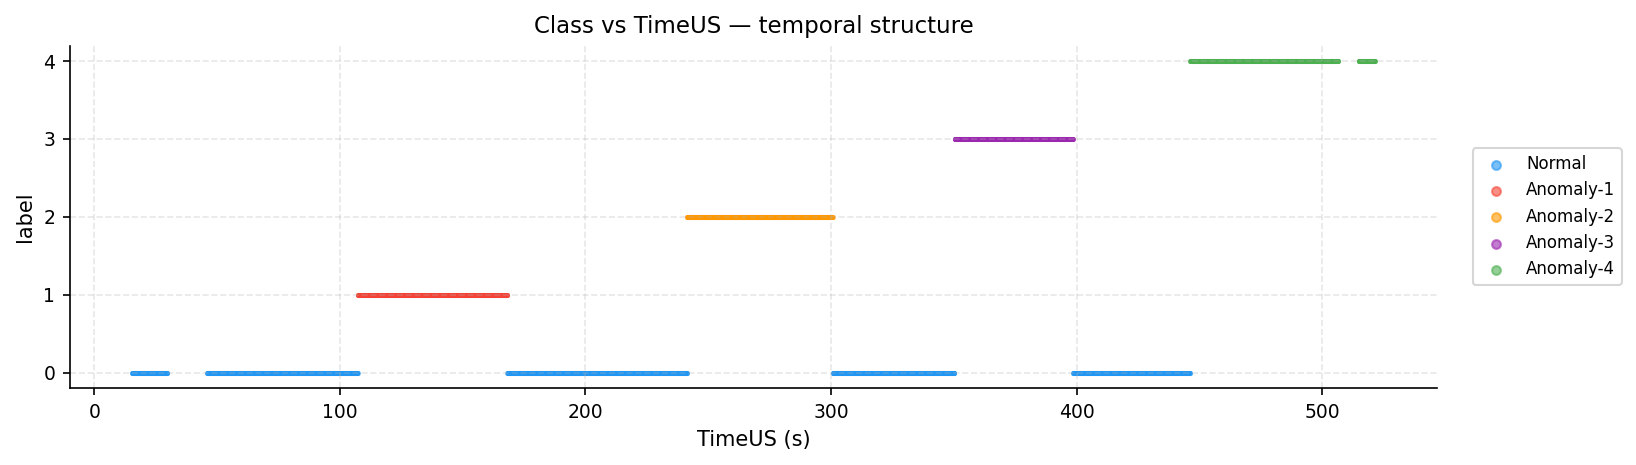

TimeUS deltas: median=99960 us, p95=99960 us, max=16299311 us
Episodes detected by gap rule (from §2): 3

=== §2.5 Group-split feasibility report ===
                           strategy  feasible  n_train  n_val  n_test  cls_train  cls_val  cls_test  min_cls_test note
A0_StratifiedShuffleSplit (current)      True     3371    723     723          5        5         5            72     
   A1_Chronological strict 70/15/15     False     3372    723     722          4        2         2             0     
A2_Contiguous K=20-block GroupSplit     False     3372    722     723          5        1         3             0     
  A3_Gap-detected episodes (n_ep=3)     False     4606     67     144          5        1         1             0     


2026-05-12 21:52:58,535 | INFO | [§2.5] Diagnostic saved: <ROOT>/Result/eda/split_diagnostic.csv
2026-05-12 21:52:58,536 | INFO | [§2.5] Recommended strategy: None



** No group-aware strategy preserves all classes in all splits. **
   Recommended fallback: reformulate as binary (normal vs anomaly)
   or one-vs-fault, then re-run diagnostic.


In [3]:
# ══════════════════════════════════════════════════════════════════════
# §2.5 — Temporal EDA Diagnostic — NO pipeline mutation
# Inputs (already in scope from §2):
#   time_series_raw, episode_series_raw, y_raw, df_raw, N_CLASSES, LABEL_NAMES,
#   GLOBAL_SEED, DIRS, CONFIG
# Outputs: prints + plot(s) saved to DIRS['eda']. Sets DIAG_RESULTS dict for later use.
# ══════════════════════════════════════════════════════════════════════
from sklearn.model_selection import GroupShuffleSplit, StratifiedShuffleSplit

_t_us  = np.asarray(time_series_raw, dtype=np.int64)
_ep    = np.asarray(episode_series_raw, dtype=np.int64)
_y     = np.asarray(y_raw, dtype=int)
N      = len(_y)
classes_all = np.unique(_y)
log.info(f'[§2.5] N={N}, classes={classes_all.tolist()}, n_episodes={len(np.unique(_ep))}')

# ── Plot label vs TimeUS to make the temporal block structure visible ─
fig_tl, ax_tl = plt.subplots(figsize=(11, 3.2))
for ci, c in enumerate(classes_all):
    m = _y == c
    ax_tl.scatter(_t_us[m] / 1e6, np.full(m.sum(), c),
                  s=2, c=[COLORS_5[ci % 5]], label=LABEL_NAMES.get(int(c), str(c)),
                  alpha=0.6)
ax_tl.set_xlabel('TimeUS (s)')
ax_tl.set_ylabel('label')
ax_tl.set_yticks(classes_all)
ax_tl.set_title('Class vs TimeUS — temporal structure')
ax_tl.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=8, markerscale=3)
plt.tight_layout()
fig_tl.savefig(DIRS['eda'] / 'temporal_class_timeline.png', dpi=150, bbox_inches='tight')
plt.show(); plt.close()

# ── Gap statistics on TimeUS ─────────────────────────────────────────
_dt = np.diff(np.sort(_t_us))
_dt = _dt[_dt > 0]
if len(_dt) > 0:
    print(f'TimeUS deltas: median={np.median(_dt):.0f} us, p95={np.percentile(_dt,95):.0f} us, '
          f'max={_dt.max():.0f} us')
print(f'Episodes detected by gap rule (from §2): {len(np.unique(_ep))}')

# ── Helper: report class coverage for a candidate split ──────────────
def _coverage_report(name, idx_tr, idx_va, idx_te):
    rep = {'strategy': name,
           'n_train': len(idx_tr), 'n_val': len(idx_va), 'n_test': len(idx_te)}
    for split_name, idx in [('train', idx_tr), ('val', idx_va), ('test', idx_te)]:
        ys = _y[idx] if len(idx) else np.array([], dtype=int)
        classes_present = sorted(np.unique(ys).tolist())
        rep[f'{split_name}_classes_present'] = classes_present
        rep[f'{split_name}_n_classes'] = len(classes_present)
        rep[f'{split_name}_min_class_count'] = (
            int(np.bincount(ys, minlength=N_CLASSES).min()) if len(ys) else 0
        )
    rep['all_classes_in_test']  = rep['test_n_classes']  == N_CLASSES
    rep['all_classes_in_train'] = rep['train_n_classes'] == N_CLASSES
    rep['all_classes_in_val']   = rep['val_n_classes']   == N_CLASSES
    rep['feasible'] = (rep['all_classes_in_train'] and
                       rep['all_classes_in_val'] and
                       rep['all_classes_in_test'])
    return rep

TRAIN_F = CONFIG['EPISODE_SPLIT']['train']
VAL_F   = CONFIG['EPISODE_SPLIT']['val']
TEST_F  = CONFIG['EPISODE_SPLIT']['test']

# ── Strategy 0: optimistic baseline (current StratifiedShuffleSplit) ──
sss0 = StratifiedShuffleSplit(n_splits=1, test_size=TEST_F, random_state=GLOBAL_SEED)
i_tv0, i_te0 = next(sss0.split(np.zeros(N), _y))
sss0b = StratifiedShuffleSplit(
    n_splits=1, test_size=VAL_F/(TRAIN_F+VAL_F), random_state=GLOBAL_SEED)
i_tr0, i_va0 = next(sss0b.split(np.zeros(len(i_tv0)), _y[i_tv0]))
i_tr0, i_va0 = i_tv0[i_tr0], i_tv0[i_va0]
rep_strat = _coverage_report('A0_StratifiedShuffleSplit (current)', i_tr0, i_va0, i_te0)

# ── Strategy 1: strict chronological by TimeUS ────────────────────────
_order = np.argsort(_t_us)
n_tr = int(round(TRAIN_F * N))
n_va = int(round(VAL_F   * N))
i_tr1 = _order[:n_tr]
i_va1 = _order[n_tr:n_tr + n_va]
i_te1 = _order[n_tr + n_va:]
rep_chrono = _coverage_report('A1_Chronological strict 70/15/15', i_tr1, i_va1, i_te1)

# ── Strategy 2: contiguous K-block GroupShuffleSplit (K=20) ───────────
K_BLOCKS = 20
_block_id = np.zeros(N, dtype=int)
_block_id[_order] = np.minimum(
    (np.arange(N) * K_BLOCKS) // N, K_BLOCKS - 1)
def _two_stage_group_split(groups, test_size, val_size, seed):
    gss_te = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    i_tv, i_te = next(gss_te.split(np.zeros(len(groups)), _y, groups))
    g_tv = groups[i_tv]
    gss_va = GroupShuffleSplit(
        n_splits=1, test_size=val_size/(1.0-test_size), random_state=seed)
    i_tr_rel, i_va_rel = next(gss_va.split(np.zeros(len(i_tv)), _y[i_tv], g_tv))
    return i_tv[i_tr_rel], i_tv[i_va_rel], i_te

i_tr2, i_va2, i_te2 = _two_stage_group_split(_block_id, TEST_F, VAL_F, GLOBAL_SEED)
rep_blocks = _coverage_report(f'A2_Contiguous K={K_BLOCKS}-block GroupSplit',
                              i_tr2, i_va2, i_te2)

# ── Strategy 3: gap-detected episodes ─────────────────────────────────
n_ep = len(np.unique(_ep))
if n_ep >= 3:
    try:
        i_tr3, i_va3, i_te3 = _two_stage_group_split(_ep, TEST_F, VAL_F, GLOBAL_SEED)
        rep_ep = _coverage_report(f'A3_Gap-detected episodes (n_ep={n_ep})',
                                  i_tr3, i_va3, i_te3)
    except Exception as e:
        rep_ep = {'strategy': f'A3_Gap-detected episodes (n_ep={n_ep})',
                  'feasible': False, 'error': str(e)}
else:
    rep_ep = {'strategy': f'A3_Gap-detected episodes (n_ep={n_ep})',
              'feasible': False,
              'error': f'Only {n_ep} episode(s) — cannot split into 3 groups.'}

# ── Report ────────────────────────────────────────────────────────────
DIAG_RESULTS = {
    'A0_stratified_baseline': rep_strat,
    'A1_chronological'      : rep_chrono,
    'A2_contiguous_blocks'  : rep_blocks,
    'A3_episodes'           : rep_ep,
}
_diag_df = pd.DataFrame([
    {'strategy': r['strategy'],
     'feasible': r.get('feasible', False),
     'n_train': r.get('n_train', 0),
     'n_val'  : r.get('n_val', 0),
     'n_test' : r.get('n_test', 0),
     'cls_train': r.get('train_n_classes', 0),
     'cls_val'  : r.get('val_n_classes', 0),
     'cls_test' : r.get('test_n_classes', 0),
     'min_cls_test': r.get('test_min_class_count', 0),
     'note': r.get('error', '')}
    for r in DIAG_RESULTS.values()
])
print('\n=== §2.5 Group-split feasibility report ===')
print(_diag_df.to_string(index=False))
_diag_df.to_csv(DIRS['eda'] / 'split_diagnostic.csv', index=False)
log.info(f"[§2.5] Diagnostic saved: {DIRS['eda'] / 'split_diagnostic.csv'}")

# ── Recommendation ────────────────────────────────────────────────────
_feasible = [r for r in DIAG_RESULTS.values()
             if r.get('feasible') and r['strategy'] != DIAG_RESULTS['A0_stratified_baseline']['strategy']]
if _feasible:
    # Prefer most-realistic-yet-feasible: episodes > blocks > chronological
    _priority = {'A3': 3, 'A2': 2, 'A1': 1}
    _rec = max(_feasible, key=lambda r: _priority.get(r['strategy'][:2], 0))
    RECOMMENDED_STRATEGY = _rec['strategy']
    print(f'\nRECOMMENDED group-aware strategy: {RECOMMENDED_STRATEGY}')
    print('  -> §3 should be refactored to use this grouping.')
else:
    RECOMMENDED_STRATEGY = None
    print('\n** No group-aware strategy preserves all classes in all splits. **')
    print('   Recommended fallback: reformulate as binary (normal vs anomaly)')
    print('   or one-vs-fault, then re-run diagnostic.')
log.info(f'[§2.5] Recommended strategy: {RECOMMENDED_STRATEGY}')


In [4]:
# ══════════════════════════════════════════════════════════════════════
# §2.5b — Task reformulation feasibility (binary & one-vs-fault)
# Inputs from §2.5: _t_us, _ep, _y, N, TRAIN_F, VAL_F, TEST_F, K_BLOCKS,
#                   _block_id, i_tr{0..3}, i_va{0..3}, i_te{0..3}, n_ep, GLOBAL_SEED
# ══════════════════════════════════════════════════════════════════════
from sklearn.model_selection import GroupShuffleSplit, StratifiedShuffleSplit

def _two_stage_group_split_generic(groups, y_target, test_size, val_size, seed):
    gss_te = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    i_tv, i_te = next(gss_te.split(np.zeros(len(groups)), y_target, groups))
    gss_va = GroupShuffleSplit(
        n_splits=1, test_size=val_size/(1.0-test_size), random_state=seed)
    i_tr_rel, i_va_rel = next(
        gss_va.split(np.zeros(len(i_tv)), y_target[i_tv], groups[i_tv]))
    return i_tv[i_tr_rel], i_tv[i_va_rel], i_te

def _bin_feasibility(name, idx_tr, idx_va, idx_te, y_target):
    out = {'strategy': name,
           'n_train': len(idx_tr), 'n_val': len(idx_va), 'n_test': len(idx_te)}
    for sn, idx in [('train', idx_tr), ('val', idx_va), ('test', idx_te)]:
        ys = y_target[idx] if len(idx) else np.array([], dtype=int)
        bc = np.bincount(ys, minlength=2) if len(ys) else np.array([0, 0])
        out[f'{sn}_n_pos'] = int(bc[1])
        out[f'{sn}_n_neg'] = int(bc[0])
        out[f'{sn}_pos_frac'] = float(bc[1] / max(len(ys), 1))
    out['feasible'] = all(
        out[f'{sn}_n_pos'] > 0 and out[f'{sn}_n_neg'] > 0
        for sn in ('train', 'val', 'test'))
    out['min_pos_test'] = out['test_n_pos']
    return out

# ──────────────────────────────────────────────────────────────────────
# (A) BINARY TASK: normal vs any anomaly
# ──────────────────────────────────────────────────────────────────────
_y_bin = (_y != 0).astype(int)
print(f'Binary class balance overall: '
      f'normal={(_y_bin==0).sum()} ({(_y_bin==0).mean()*100:.1f}%) | '
      f'anomaly={(_y_bin==1).sum()} ({(_y_bin==1).mean()*100:.1f}%)')

bin_results = {
    'B0_StratifiedShuffleSplit (current)': _bin_feasibility(
        'B0_StratifiedShuffleSplit (current)', i_tr0, i_va0, i_te0, _y_bin),
    'B1_Chronological strict 70/15/15': _bin_feasibility(
        'B1_Chronological strict 70/15/15', i_tr1, i_va1, i_te1, _y_bin),
    f'B2_Contiguous K={K_BLOCKS}-block GroupSplit': _bin_feasibility(
        f'B2_Contiguous K={K_BLOCKS}-block GroupSplit', i_tr2, i_va2, i_te2, _y_bin),
}
# A3 may not exist if §2.5 errored; check via DIAG_RESULTS
if 'i_tr3' in dir() and isinstance(rep_ep, dict) and rep_ep.get('n_train'):
    bin_results[f'B3_Gap-detected episodes (n_ep={n_ep})'] = _bin_feasibility(
        f'B3_Gap-detected episodes (n_ep={n_ep})', i_tr3, i_va3, i_te3, _y_bin)

_bin_df = pd.DataFrame([
    {'strategy': r['strategy'], 'feasible': r['feasible'],
     'n_tr': r['n_train'], 'n_va': r['n_val'], 'n_te': r['n_test'],
     'pos_tr': r['train_n_pos'], 'pos_va': r['val_n_pos'], 'pos_te': r['test_n_pos'],
     'pos_frac_tr': round(r['train_pos_frac'], 3),
     'pos_frac_va': round(r['val_pos_frac'], 3),
     'pos_frac_te': round(r['test_pos_frac'], 3)}
    for r in bin_results.values()])
print('\n=== §2.5b BINARY task — group-split feasibility ===')
print(_bin_df.to_string(index=False))
_bin_df.to_csv(DIRS['eda'] / 'split_diagnostic_binary.csv', index=False)

_bin_feasible = [r for r in bin_results.values()
                 if r['feasible'] and not r['strategy'].startswith('B0_')]
if _bin_feasible:
    _priority = {'B3': 3, 'B2': 2, 'B1': 1}
    _rec_bin = max(_bin_feasible, key=lambda r: _priority.get(r['strategy'][:2], 0))
    RECOMMENDED_STRATEGY_BIN = _rec_bin['strategy']
    print(f'\nRECOMMENDED binary strategy: {RECOMMENDED_STRATEGY_BIN}')
else:
    RECOMMENDED_STRATEGY_BIN = None
    print('\n** No group-aware split is feasible even for binary task. **')

# ──────────────────────────────────────────────────────────────────────
# (B) ONE-VS-FAULT
# ──────────────────────────────────────────────────────────────────────
ovf_rows = []
ANOMALY_CLASSES = [c for c in np.unique(_y) if c != 0]
for c in ANOMALY_CLASSES:
    mask = (_y == 0) | (_y == c)
    Nc = int(mask.sum())
    if Nc < 50:
        ovf_rows.append({'fault': int(c), 'n_samples': Nc,
                         'chronological_feasible': False,
                         'blocks_feasible': False,
                         'episodes_feasible': False,
                         'note': f'only {Nc} samples'})
        continue
    y_c   = (_y[mask] == c).astype(int)
    t_c   = _t_us[mask]
    ep_c  = _ep[mask]
    blk_c = _block_id[mask]

    # chronological
    order_c = np.argsort(t_c)
    ntr_c = int(round(TRAIN_F * Nc))
    nva_c = int(round(VAL_F * Nc))
    itr_ch = order_c[:ntr_c]
    iva_ch = order_c[ntr_c:ntr_c + nva_c]
    ite_ch = order_c[ntr_c + nva_c:]
    f_ch = all(
        np.bincount(y_c[idx], minlength=2).min() > 0
        for idx in (itr_ch, iva_ch, ite_ch))

    # blocks
    try:
        itr_b, iva_b, ite_b = _two_stage_group_split_generic(
            blk_c, y_c, TEST_F, VAL_F, GLOBAL_SEED)
        f_bl = all(
            np.bincount(y_c[idx], minlength=2).min() > 0
            for idx in (itr_b, iva_b, ite_b))
    except Exception:
        f_bl = False

    # episodes
    n_ep_c = len(np.unique(ep_c))
    if n_ep_c >= 3:
        try:
            itr_e, iva_e, ite_e = _two_stage_group_split_generic(
                ep_c, y_c, TEST_F, VAL_F, GLOBAL_SEED)
            f_ep = all(
                np.bincount(y_c[idx], minlength=2).min() > 0
                for idx in (itr_e, iva_e, ite_e))
        except Exception:
            f_ep = False
    else:
        f_ep = False

    ovf_rows.append({
        'fault': int(c), 'n_samples': Nc,
        'n_pos': int((y_c == 1).sum()),
        'n_episodes_in_subset': n_ep_c,
        'chronological_feasible': bool(f_ch),
        'blocks_feasible': bool(f_bl),
        'episodes_feasible': bool(f_ep),
        'note': ''})

_ovf_df = pd.DataFrame(ovf_rows)
print('\n=== §2.5b ONE-VS-FAULT feasibility ===')
print(_ovf_df.to_string(index=False))
_ovf_df.to_csv(DIRS['eda'] / 'split_diagnostic_one_vs_fault.csv', index=False)

# Summary recommendation
_ovf_any = _ovf_df[(_ovf_df['chronological_feasible']) |
                   (_ovf_df['blocks_feasible']) |
                   (_ovf_df['episodes_feasible'])]
if len(_ovf_any) > 0:
    print(f'\nFaults evaluable under at least one group-aware split: '
          f'{sorted(_ovf_any["fault"].tolist())}')
else:
    print('\nNo individual fault is evaluable under a group-aware split.')

# Persist final recommendation as module-level globals
log.info(f'[§2.5b] Recommended BINARY strategy: {RECOMMENDED_STRATEGY_BIN}')


2026-05-12 21:52:58,586 | INFO | [§2.5b] Recommended BINARY strategy: B1_Chronological strict 70/15/15


Binary class balance overall: normal=2463 (51.1%) | anomaly=2354 (48.9%)

=== §2.5b BINARY task — group-split feasibility ===
                           strategy  feasible  n_tr  n_va  n_te  pos_tr  pos_va  pos_te  pos_frac_tr  pos_frac_va  pos_frac_te
B0_StratifiedShuffleSplit (current)      True  3371   723   723    1648     353     353        0.489        0.488        0.488
   B1_Chronological strict 70/15/15      True  3372   723   722    1386     298     670        0.411        0.412        0.928
B2_Contiguous K=20-block GroupSplit     False  3372   722   723    2108       0     246        0.625        0.000        0.340
  B3_Gap-detected episodes (n_ep=3)     False  4606    67   144    2287      67       0        0.497        1.000        0.000

RECOMMENDED binary strategy: B1_Chronological strict 70/15/15

=== §2.5b ONE-VS-FAULT feasibility ===
 fault  n_samples  n_pos  n_episodes_in_subset  chronological_feasible  blocks_feasible  episodes_feasible note
     1       3071    608

In [5]:
# ══════════════════════════════════════════════════════════════════════
# §2.5c — Sweep K-blocks × seeds for binary task feasibility
# Inputs from §2.5/§2.5b: _t_us, _y, TRAIN_F, VAL_F, TEST_F, _y_bin, GLOBAL_SEED
# ══════════════════════════════════════════════════════════════════════
from sklearn.model_selection import GroupShuffleSplit

K_GRID    = [5, 10, 20, 30, 50, 100]
N_SEEDS_SWEEP = 50

def _make_block_ids(N, K, time_us):
    """Return contiguous K-block ids in TimeUS order."""
    order = np.argsort(time_us)
    bid = np.empty(N, dtype=int)
    bid[order] = np.minimum((np.arange(N) * K) // N, K - 1)
    return bid

def _try_group_split(groups, y_target, test_size, val_size, seed):
    gss_te = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    i_tv, i_te = next(gss_te.split(np.zeros(len(groups)), y_target, groups))
    gss_va = GroupShuffleSplit(
        n_splits=1, test_size=val_size/(1.0-test_size), random_state=seed)
    i_tr_rel, i_va_rel = next(
        gss_va.split(np.zeros(len(i_tv)), y_target[i_tv], groups[i_tv]))
    return i_tv[i_tr_rel], i_tv[i_va_rel], i_te

sweep_rows = []
best_per_K = {}
for K in K_GRID:
    bid = _make_block_ids(N, K, _t_us)
    n_feasible = 0
    feas_records = []
    for s in range(N_SEEDS_SWEEP):
        try:
            itr, iva, ite = _try_group_split(bid, _y_bin, TEST_F, VAL_F, seed=s)
        except Exception:
            continue
        n_pos = [int((_y_bin[idx] == 1).sum()) for idx in (itr, iva, ite)]
        n_neg = [int((_y_bin[idx] == 0).sum()) for idx in (itr, iva, ite)]
        feasible = all(p > 0 and n > 0 for p, n in zip(n_pos, n_neg))
        if not feasible:
            continue
        n_feasible += 1
        fracs = [p / max(p + n, 1) for p, n in zip(n_pos, n_neg)]
        shift = max(fracs) - min(fracs)
        feas_records.append({
            'K': K, 'seed': s, 'shift': shift,
            'pos_tr': n_pos[0], 'pos_va': n_pos[1], 'pos_te': n_pos[2],
            'frac_tr': round(fracs[0], 3),
            'frac_va': round(fracs[1], 3),
            'frac_te': round(fracs[2], 3),
        })
    feas_rate = n_feasible / N_SEEDS_SWEEP
    if feas_records:
        feas_records.sort(key=lambda r: r['shift'])
        best = feas_records[0]
        sweep_rows.append({
            'K': K, 'feasibility_rate': round(feas_rate, 2),
            'best_seed': best['seed'],
            'best_shift': round(best['shift'], 3),
            'best_frac_tr': best['frac_tr'],
            'best_frac_va': best['frac_va'],
            'best_frac_te': best['frac_te'],
            'best_pos_tr': best['pos_tr'],
            'best_pos_va': best['pos_va'],
            'best_pos_te': best['pos_te'],
        })
        best_per_K[K] = best
    else:
        sweep_rows.append({
            'K': K, 'feasibility_rate': 0.0,
            'best_seed': None, 'best_shift': None,
            'best_frac_tr': None, 'best_frac_va': None, 'best_frac_te': None,
            'best_pos_tr': 0, 'best_pos_va': 0, 'best_pos_te': 0,
        })

_sw_df = pd.DataFrame(sweep_rows)
print('=== §2.5c K-block × seed sweep (binary task) ===')
print(_sw_df.to_string(index=False))
_sw_df.to_csv(DIRS['eda'] / 'split_sweep_kblocks.csv', index=False)

# ── Pick the best protocol overall ───────────────────────────────────
# Criterion: highest feasibility rate first, then smallest prior shift.
_viable = _sw_df[_sw_df['feasibility_rate'] > 0].copy()
if len(_viable):
    _viable = _viable.sort_values(
        by=['feasibility_rate', 'best_shift'], ascending=[False, True])
    best_row = _viable.iloc[0]
    BEST_K_BLOCKS = int(best_row['K'])
    BEST_BLOCK_SEED = int(best_row['best_seed'])
    BEST_SHIFT = float(best_row['best_shift'])
    BEST_FEAS_RATE = float(best_row['feasibility_rate'])
    print(f'\nBest block protocol: K={BEST_K_BLOCKS}, seed={BEST_BLOCK_SEED}, '
          f'feasibility_rate={BEST_FEAS_RATE:.2f}, prior_shift={BEST_SHIFT:.3f}')
    print(f'  pos_frac: tr={best_row["best_frac_tr"]} va={best_row["best_frac_va"]} '
          f'te={best_row["best_frac_te"]}')
    # Compare with B1 chronological shift as reference
    b1_fracs = [
        (_y_bin[i_tr1] == 1).mean(),
        (_y_bin[i_va1] == 1).mean(),
        (_y_bin[i_te1] == 1).mean(),
    ]
    b1_shift = max(b1_fracs) - min(b1_fracs)
    print(f'  Reference B1 chronological prior shift: {b1_shift:.3f}')
    if BEST_SHIFT < b1_shift and BEST_FEAS_RATE >= 0.5:
        FINAL_PROTOCOL = f'B2_blocks_K{BEST_K_BLOCKS}_seed{BEST_BLOCK_SEED}'
        print(f'\nRECOMMENDED FINAL PROTOCOL: {FINAL_PROTOCOL} '
              '(less prior shift than chronological, with high feasibility).')
    else:
        FINAL_PROTOCOL = 'B1_chronological'
        print(f'\nRECOMMENDED FINAL PROTOCOL: {FINAL_PROTOCOL} '
              '(blocks did not improve over chronological).')
else:
    BEST_K_BLOCKS = BEST_BLOCK_SEED = None
    FINAL_PROTOCOL = 'B1_chronological'
    print('\nNo K-block configuration is feasible. '
          'Falling back to chronological (B1) as primary protocol.')

log.info(f'[§2.5c] FINAL_PROTOCOL = {FINAL_PROTOCOL}')


2026-05-12 21:52:58,797 | INFO | [§2.5c] FINAL_PROTOCOL = B2_blocks_K10_seed36


=== §2.5c K-block × seed sweep (binary task) ===
  K  feasibility_rate  best_seed  best_shift  best_frac_tr  best_frac_va  best_frac_te  best_pos_tr  best_pos_va  best_pos_te
  5              1.00          9       0.091         0.508         0.417         0.501         1470          402          482
 10              1.00         36       0.015         0.485         0.490         0.500         1401          472          481
 20              0.86          6       0.071         0.502         0.431         0.484         1693          311          350
 30              0.98          9       0.039         0.497         0.488         0.458         1596          391          367
 50              1.00         30       0.048         0.481         0.529         0.482         1575          407          372
100              1.00         39       0.044         0.501         0.466         0.457         1665          359          330

Best block protocol: K=10, seed=36, feasibility_rate=1.00, prior_shi

## §4 — Feature Sanitization & Proxy Audit (three modes)

Finalises `FEATURE_COLS` after dropping zero-variance columns. Then declares the three feature-set modes used by every downstream model:

- **`full`** — every available feature (worst-case proxy contamination, baseline).
- **`no_proxy_loose`** — drops obvious accumulators / state flags.
- **`no_proxy_strict`** — additionally drops battery state, GPS/position estimator, controller setpoints, altitude/baro, and motor demand. A deliberately conservative working hypothesis: some excluded signals may carry causal information; this mode tests robustness when most context is withheld.

The `full → loose → strict` degradation slope quantifies each model's dependence on contextual proxies vs. instantaneous physics.


In [6]:
# ══════════════════════════════════════════════════════════════════════
# §4.0 — Zero-variance drop (finalises FEATURE_COLS)
# ══════════════════════════════════════════════════════════════════════
FEATURE_COLS = [c for c in FEATURE_COLS if c != 'episode_id']
_var = df_raw[FEATURE_COLS].var()
_zero_var = _var[_var == 0].index.tolist()
if _zero_var:
    log.warning(f'Dropping {len(_zero_var)} zero-variance feature(s): {_zero_var}')
    FEATURE_COLS = [c for c in FEATURE_COLS if c not in _zero_var]
log.info(f'FEATURE_COLS finalized: {len(FEATURE_COLS)} features.')


2026-05-12 21:52:58,811 | WARNING | Dropping 9 zero-variance feature(s): ['AEKF', 'Volt', 'SAlt', 'OfsX', 'OfsY', 'OfsZ', 'ThLimit', 'GWk', 'HDop']
2026-05-12 21:52:58,811 | INFO | FEATURE_COLS finalized: 72 features.


In [7]:
# ══════════════════════════════════════════════════════════════════════
# §2.6 — Proxy Feature Audit (three nested modes)
# Inputs from §3: FEATURE_COLS (after zero-variance drop)
# ══════════════════════════════════════════════════════════════════════

# ── Loose proxies: obvious accumulators / state flags ────────────────
PROXY_CANDIDATES_LOOSE = [
    'abT',      # IMU temperature — monotonic/segment-dependent
    'EnrgTot',  # cumulative energy
    'CurrTot',  # cumulative current
    'Res',      # battery internal resistance
    'BatRes',   # MOTB battery resistance proxy
    'AEKF',     # EKF type indicator (zero-variance)
    'Offset',   # BARO bias / calibration state
    'Health',   # generic sensor health flag
    'Rout', 'POut', 'YOut',  # controller outputs (closed-loop with state)
]

# ── Strict additions: battery state + position + controller setpoints +
#    altitude/baro + motor demand. Conservative working hypothesis.
PROXY_CANDIDATES_STRICT_EXTRA = [
    # Battery state (drifts with charge / mission elapsed time)
    'Volt', 'VoltR', 'Curr', 'RemPct', 'BatVolt',
    # GPS / position
    'Lat', 'Lng', 'Spd', 'GCrs', 'NSats', 'HDop', 'GWk', 'VZ',
    # Position estimator (XKF1)
    'VN', 'VE', 'VD', 'PN', 'PE', 'PD', 'XKF1_PD', 'XKF1_VD', 'dPD', 'OH',
    # Position controller (PSCD setpoints/states)
    'TPD', 'PSCD_PD', 'DVD', 'TVD', 'PSCD_VD', 'DAD', 'TAD', 'AD',
    # Altitude / baro / mission phase
    'BARO_Alt', 'BARO_CRt', 'BAlt', 'SAlt', 'TAlt', 'DAIt',
    'CTUN_Alt', 'CTUN_CRt', 'Press', 'SMS',
    # Motor demand / throttle
    'LiftMax', 'ThLimit', 'ThI', 'ABst', 'ThO', 'ThH', 'AOut',
]
PROXY_CANDIDATES_STRICT = list(dict.fromkeys(
    PROXY_CANDIDATES_LOOSE + PROXY_CANDIDATES_STRICT_EXTRA))  # dedupe, preserve order

# ── Resolve against actual FEATURE_COLS ──────────────────────────────
PROXY_PRESENT_LOOSE  = [f for f in PROXY_CANDIDATES_LOOSE  if f in FEATURE_COLS]
PROXY_PRESENT_STRICT = [f for f in PROXY_CANDIDATES_STRICT if f in FEATURE_COLS]
PROXY_ABSENT_LOOSE   = [f for f in PROXY_CANDIDATES_LOOSE  if f not in FEATURE_COLS]
PROXY_ABSENT_STRICT  = [f for f in PROXY_CANDIDATES_STRICT if f not in FEATURE_COLS]

FEATURE_COLS_FULL   = list(FEATURE_COLS)
FEATURE_COLS_LOOSE  = [f for f in FEATURE_COLS if f not in PROXY_PRESENT_LOOSE]
FEATURE_COLS_STRICT = [f for f in FEATURE_COLS if f not in PROXY_PRESENT_STRICT]

FEAT_IDX_FULL   = np.arange(len(FEATURE_COLS_FULL))
FEAT_IDX_LOOSE  = np.array(
    [FEATURE_COLS_FULL.index(f) for f in FEATURE_COLS_LOOSE],  dtype=int)
FEAT_IDX_STRICT = np.array(
    [FEATURE_COLS_FULL.index(f) for f in FEATURE_COLS_STRICT], dtype=int)

FEATURE_SET_MODES = ['full', 'no_proxy_loose', 'no_proxy_strict']

def get_active_features(mode):
    """Return (feature_cols, idx_array) for a given FEATURE_SET_MODE."""
    if   mode == 'full':            return FEATURE_COLS_FULL,   FEAT_IDX_FULL
    elif mode == 'no_proxy_loose':  return FEATURE_COLS_LOOSE,  FEAT_IDX_LOOSE
    elif mode == 'no_proxy_strict': return FEATURE_COLS_STRICT, FEAT_IDX_STRICT
    raise ValueError(f'Unknown FEATURE_SET_MODE: {mode!r}')

# Back-compat aliases (legacy names some downstream code may use)
PROXY_CANDIDATES     = PROXY_CANDIDATES_LOOSE
PROXY_PRESENT        = PROXY_PRESENT_LOOSE
FEATURE_COLS_NOPROXY = FEATURE_COLS_LOOSE
FEAT_IDX_NOPROXY     = FEAT_IDX_LOOSE

# ── Audit report ─────────────────────────────────────────────────────
print(f'FEATURE_COLS total: {len(FEATURE_COLS_FULL)}')
print(f'\nLOOSE proxies ({len(PROXY_CANDIDATES_LOOSE)} declared):')
print(f'  Present ({len(PROXY_PRESENT_LOOSE)}): {PROXY_PRESENT_LOOSE}')
print(f'  Absent  ({len(PROXY_ABSENT_LOOSE)}): {PROXY_ABSENT_LOOSE}')
print(f'\nSTRICT proxies ({len(PROXY_CANDIDATES_STRICT)} declared):')
print(f'  Present ({len(PROXY_PRESENT_STRICT)}): {PROXY_PRESENT_STRICT}')
print(f'  Absent  ({len(PROXY_ABSENT_STRICT)}): {PROXY_ABSENT_STRICT}')
print(f'\nFeature set sizes:')
print(f'  full:            {len(FEATURE_COLS_FULL)}')
print(f'  no_proxy_loose:  {len(FEATURE_COLS_LOOSE)}  (-{len(PROXY_PRESENT_LOOSE)})')
print(f'  no_proxy_strict: {len(FEATURE_COLS_STRICT)} (-{len(PROXY_PRESENT_STRICT)})')
print(f'\nFeatures surviving in STRICT mode:\n  {FEATURE_COLS_STRICT}')

_audit_rows = []
for f in PROXY_CANDIDATES_STRICT:
    _audit_rows.append({
        'feature': f,
        'present_in_dataset': f in FEATURE_COLS_FULL,
        'in_loose_set':  f in PROXY_CANDIDATES_LOOSE,
        'in_strict_set': True,
    })
_audit_df = pd.DataFrame(_audit_rows)
_audit_df.to_csv(DIRS['eda'] / 'proxy_feature_audit.csv', index=False)
log.info(f'[§2.6] sizes — full={len(FEATURE_COLS_FULL)} '
         f'loose={len(FEATURE_COLS_LOOSE)} strict={len(FEATURE_COLS_STRICT)}')


2026-05-12 21:52:58,825 | INFO | [§2.6] sizes — full=72 loose=63 strict=22


FEATURE_COLS total: 72

LOOSE proxies (11 declared):
  Present (9): ['abT', 'EnrgTot', 'CurrTot', 'Res', 'BatRes', 'Offset', 'Rout', 'POut', 'YOut']
  Absent  (2): ['AEKF', 'Health']

STRICT proxies (59 declared):
  Present (50): ['abT', 'EnrgTot', 'CurrTot', 'Res', 'BatRes', 'Offset', 'Rout', 'POut', 'YOut', 'VoltR', 'Curr', 'RemPct', 'BatVolt', 'Lat', 'Lng', 'Spd', 'GCrs', 'NSats', 'VZ', 'VN', 'VE', 'PN', 'PE', 'XKF1_PD', 'XKF1_VD', 'dPD', 'OH', 'TPD', 'PSCD_PD', 'DVD', 'TVD', 'PSCD_VD', 'DAD', 'TAD', 'AD', 'BARO_Alt', 'BARO_CRt', 'BAlt', 'TAlt', 'DAIt', 'CTUN_Alt', 'CTUN_CRt', 'Press', 'SMS', 'LiftMax', 'ThI', 'ABst', 'ThO', 'ThH', 'AOut']
  Absent  (9): ['AEKF', 'Health', 'Volt', 'HDop', 'GWk', 'VD', 'PD', 'SAlt', 'ThLimit']

Feature set sizes:
  full:            72
  no_proxy_loose:  63  (-9)
  no_proxy_strict: 22 (-50)

Features surviving in STRICT mode:
  ['Roll', 'Pitch', 'Yaw', 'MagX', 'MagY', 'MagZ', 'R', 'P', 'Y', 'A', 'GX', 'GY', 'GZ', 'abGyrX', 'abGyrY', 'abGyrZ', 'abAccX'

## §5 — Helper Functions

All helpers consumed by the model sections: metrics, samplers, DRU observable extractor, classical model factory. Defined once here for clarity and reuse.


In [8]:
# ══════════════════════════════════════════════════════════════════════
# §5 — Helpers: metrics, samplers, DRU obs extractor, classical factory
# ══════════════════════════════════════════════════════════════════════
from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
    precision_score, recall_score, roc_auc_score, matthews_corrcoef,
    confusion_matrix, classification_report, average_precision_score,
    cohen_kappa_score, multilabel_confusion_matrix)
from sklearn.preprocessing import label_binarize


def compute_metrics(y_true, y_pred, y_proba=None, n_classes=2):
    """Comprehensive metric panel — works for binary and multiclass."""
    out = dict(
        accuracy=accuracy_score(y_true, y_pred),
        balanced_acc=balanced_accuracy_score(y_true, y_pred),
        mcc=matthews_corrcoef(y_true, y_pred),
        f1_macro=f1_score(y_true, y_pred, average='macro', zero_division=0),
        f1_weighted=f1_score(y_true, y_pred, average='weighted', zero_division=0),
        precision=precision_score(y_true, y_pred, average='macro', zero_division=0),
        recall=recall_score(y_true, y_pred, average='macro', zero_division=0),
        kappa=cohen_kappa_score(y_true, y_pred,
                                 labels=sorted(set(np.unique(y_true)) | set(np.unique(y_pred)))),
        roc_auc_ovr=np.nan, pr_auc=np.nan,
    )
    if y_proba is not None:
        try:
            present = sorted(np.unique(y_true))
            if len(present) == 2:
                if y_proba.ndim == 2 and y_proba.shape[1] >= 2:
                    prob = y_proba[:, -1]
                else:
                    prob = y_proba.ravel()
                out['roc_auc_ovr'] = roc_auc_score(y_true, prob)
                out['pr_auc']      = average_precision_score(y_true, prob)
            elif len(present) > 2:
                out['roc_auc_ovr'] = roc_auc_score(
                    y_true, y_proba, multi_class='ovr',
                    average='macro', labels=present)
                yb = label_binarize(y_true, classes=present)
                if yb.ndim == 1: yb = yb.reshape(-1, 1)
                out['pr_auc'] = float(np.mean([
                    average_precision_score(yb[:, k], y_proba[:, k])
                    for k in range(len(present))]))
        except Exception as e:
            log.warning(f'AUC computation failed: {e}')
    # FAR / Detection rate
    try:
        labels = sorted(set(np.unique(y_true)) | set(np.unique(y_pred)))
        mcm = multilabel_confusion_matrix(y_true, y_pred, labels=labels)
        far_per, dr_per = [], []
        for cm_k in mcm:
            tn, fp, fn, tp = cm_k.ravel()
            far_per.append(fp / max(fp + tn, 1))
            dr_per.append(tp / max(tp + fn, 1))
        out['far_macro']   = float(np.mean(far_per))
        out['dr_macro']    = float(np.mean(dr_per))
        out['far_class0']  = float(far_per[0]) if far_per else np.nan
        out['dr_anomaly']  = float(np.mean(dr_per[1:])) if len(dr_per) > 1 else np.nan
    except Exception:
        out.update(dict(far_macro=np.nan, dr_macro=np.nan,
                        far_class0=np.nan, dr_anomaly=np.nan))
    return out


def balanced_subsample(X, y, n_per_class, seed):
    """Balanced subsample with explicit seed and balance verification."""
    min_class = int(min(np.bincount(y.astype(int))))
    assert n_per_class <= min_class, (
        f'n_per_class={n_per_class} > min_class_size={min_class}.')
    rng = np.random.default_rng(seed)
    idx = np.concatenate([
        rng.choice(np.where(y == c)[0], n_per_class, replace=False)
        for c in np.unique(y)])
    rng.shuffle(idx)
    return X[idx], y[idx]


def make_disjoint_quantum_subsets(Xq, y, n_per_class, seed):
    """Return ((X_A, y_A), (X_B, y_B)) — two disjoint balanced subsets."""
    min_cls = int(min(np.bincount(y.astype(int))))
    assert n_per_class * 2 <= min_cls, (
        f'Pool too small for 2 disjoint subsets: need {n_per_class*2}/class, '
        f'have {min_cls}/class.')
    rng = np.random.default_rng(seed)
    idx_a, idx_b = [], []
    for c in np.unique(y):
        c_idx = rng.permutation(np.where(y == c)[0])
        idx_a.extend(c_idx[:n_per_class])
        idx_b.extend(c_idx[n_per_class:n_per_class * 2])
    idx_a = np.array(idx_a); idx_b = np.array(idx_b)
    rng.shuffle(idx_a); rng.shuffle(idx_b)
    return (Xq[idx_a], y[idx_a]), (Xq[idx_b], y[idx_b])


def audit_dru_observables(n_qubits, n_classes):
    """Check for collisions in class→qubit observable mapping (k % n_qubits)."""
    collisions, q2c = [], {}
    for k in range(n_classes):
        q = k % n_qubits
        q2c.setdefault(q, []).append(k)
        if len(q2c[q]) > 1:
            collisions.append((q, q2c[q].copy()))
    return collisions, q2c


def extract_quantum_features(dru_model, X):
    """Expectation-value features from a trained (or initialized) DRU model."""
    try:
        obs = dru_model._make_observable(len(dru_model.classes_))
        evs = dru_model._evaluate_batch(dru_model.weights_, X, obs)
        return evs.reshape(len(X), -1)
    except AttributeError:
        log.warning('extract_quantum_features: falling back to predict_proba')
        return dru_model.predict_proba(X)


def make_classical_models(seed, task='binary'):
    """Factory for classical baselines. Returns dict of fitted-on-call models."""
    models = {
        'LogReg': LogisticRegression(
            solver='lbfgs', class_weight='balanced',
            max_iter=1000, random_state=seed),
        'SVM-RBF': SVC(
            kernel='rbf', class_weight='balanced', probability=True,
            random_state=seed),
        'RandomForest': RandomForestClassifier(
            n_estimators=CONFIG['CLASSICAL_N_EST'], class_weight='balanced',
            random_state=seed, n_jobs=-1),
        'MLP': MLPClassifier(
            hidden_layer_sizes=(128, 64), max_iter=300,
            random_state=seed, early_stopping=True),
    }
    if HAS_XGB:
        models['XGBoost'] = XGBClassifier(
            n_estimators=CONFIG['CLASSICAL_N_EST'], random_state=seed,
            objective='binary:logistic' if task == 'binary' else 'multi:softprob',
            eval_metric='logloss' if task == 'binary' else 'mlogloss',
            verbosity=0, n_jobs=-1)
    return models


log.info(f'[§5] Helpers loaded: compute_metrics, balanced_subsample, '
        f'make_disjoint_quantum_subsets, audit_dru_observables, '
        f'extract_quantum_features, make_classical_models.')


2026-05-12 21:52:58,840 | INFO | [§5] Helpers loaded: compute_metrics, balanced_subsample, make_disjoint_quantum_subsets, audit_dru_observables, extract_quantum_features, make_classical_models.


## §6 — Group-Aware Binary Protocol Setup (B2 K=10, 10 seeds)

Builds `B2_SPLITS = {seed: split_dict}` for `SEEDS_B2_BINARY = range(10)`. Each split:

- `GroupShuffleSplit` over **K = 10 contiguous TimeUS blocks** (two-stage 70/15/15).
- `RobustScaler` fit on **its own** train fold (no global pre-fit).
- Binary labels `y_bin = (y != 0)`.

Asserts block-level disjointness across train/val/test for every seed.


In [9]:
# ══════════════════════════════════════════════════════════════════════
# §3b — Group-aware binary protocol (B2 K=10, multi-seed)
# Inputs: time_series_raw, y_raw, df_raw, FEATURE_COLS_FULL (from §2.6),
#         CONFIG['EPISODE_SPLIT']
# Outputs:
#   K_B2, SEEDS_B2_BINARY (list of 10 seeds)
#   make_b2_binary_split(seed) -> dict
#   B2_SPLITS = {seed: split_dict}
# ══════════════════════════════════════════════════════════════════════
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import RobustScaler

K_B2 = 10
SEEDS_B2_BINARY = list(range(10))   # all 10 seeds validated as feasible at K=10
TRAIN_FRAC_B2 = CONFIG['EPISODE_SPLIT']['train']
VAL_FRAC_B2   = CONFIG['EPISODE_SPLIT']['val']
TEST_FRAC_B2  = CONFIG['EPISODE_SPLIT']['test']

# Build block ids once — they only depend on TimeUS order and K, not on seed.
_N_b2 = len(time_series_raw)
_order_b2 = np.argsort(time_series_raw)
_block_id_b2 = np.empty(_N_b2, dtype=int)
_block_id_b2[_order_b2] = np.minimum(
    (np.arange(_N_b2) * K_B2) // _N_b2, K_B2 - 1)

# X array on the FULL feature set; per-mode slicing happens downstream
_X_full_b2 = df_raw[FEATURE_COLS_FULL].values.astype(float)
_y_bin_all = (y_raw != 0).astype(int)


def make_b2_binary_split(seed,
                         X_full=_X_full_b2,
                         y_bin=_y_bin_all,
                         block_id=_block_id_b2):
    """Two-stage GroupShuffleSplit over K=10 TimeUS blocks. Binary task.

    Returns a dict with:
      seed, K, idx_train/val/test,
      X_train_raw/X_val_raw/X_test_raw  (full feature set, unscaled),
      X_train_sc/X_val_sc/X_test_sc     (RobustScaler fit on train only),
      y_train/y_val/y_test              (binary),
      scaler                            (fitted RobustScaler),
      block_id_train/val/test           (for sanity checks).
    """
    gss_te = GroupShuffleSplit(
        n_splits=1, test_size=TEST_FRAC_B2, random_state=seed)
    i_tv, i_te = next(gss_te.split(np.zeros(len(block_id)), y_bin, block_id))
    gss_va = GroupShuffleSplit(
        n_splits=1,
        test_size=VAL_FRAC_B2 / (1.0 - TEST_FRAC_B2),
        random_state=seed)
    i_tr_rel, i_va_rel = next(
        gss_va.split(np.zeros(len(i_tv)), y_bin[i_tv], block_id[i_tv]))
    i_tr = i_tv[i_tr_rel]
    i_va = i_tv[i_va_rel]

    # Disjointness assertions
    assert len(set(i_tr) & set(i_va)) == 0, f'seed={seed}: leak train/val'
    assert len(set(i_tr) & set(i_te)) == 0, f'seed={seed}: leak train/test'
    assert len(set(i_va) & set(i_te)) == 0, f'seed={seed}: leak val/test'

    X_tr_raw = X_full[i_tr]
    X_va_raw = X_full[i_va]
    X_te_raw = X_full[i_te]

    sc = RobustScaler()
    X_tr_sc = sc.fit_transform(X_tr_raw)
    X_va_sc = sc.transform(X_va_raw)
    X_te_sc = sc.transform(X_te_raw)

    return {
        'seed': seed, 'K': K_B2,
        'idx_train': i_tr, 'idx_val': i_va, 'idx_test': i_te,
        'X_train_raw': X_tr_raw, 'X_val_raw': X_va_raw, 'X_test_raw': X_te_raw,
        'X_train_sc':  X_tr_sc,  'X_val_sc':  X_va_sc,  'X_test_sc':  X_te_sc,
        'y_train': y_bin[i_tr], 'y_val': y_bin[i_va], 'y_test': y_bin[i_te],
        'scaler': sc,
        'block_id_train': block_id[i_tr],
        'block_id_val':   block_id[i_va],
        'block_id_test':  block_id[i_te],
    }


# Precompute all 10 splits and validate every one
B2_SPLITS = {}
_rows_b2 = []
for s in SEEDS_B2_BINARY:
    split = make_b2_binary_split(s)
    B2_SPLITS[s] = split
    blocks_tr = sorted(set(split['block_id_train'].tolist()))
    blocks_va = sorted(set(split['block_id_val'].tolist()))
    blocks_te = sorted(set(split['block_id_test'].tolist()))
    # No block should appear in more than one split (group integrity)
    assert not (set(blocks_tr) & set(blocks_va)), f'seed={s}: block leak tr/va'
    assert not (set(blocks_tr) & set(blocks_te)), f'seed={s}: block leak tr/te'
    assert not (set(blocks_va) & set(blocks_te)), f'seed={s}: block leak va/te'
    _rows_b2.append({
        'seed': s,
        'n_train': len(split['y_train']),
        'n_val':   len(split['y_val']),
        'n_test':  len(split['y_test']),
        'pos_tr':  int((split['y_train'] == 1).sum()),
        'pos_va':  int((split['y_val'] == 1).sum()),
        'pos_te':  int((split['y_test'] == 1).sum()),
        'frac_tr': round(float((split['y_train'] == 1).mean()), 3),
        'frac_va': round(float((split['y_val'] == 1).mean()), 3),
        'frac_te': round(float((split['y_test'] == 1).mean()), 3),
        'blocks_tr': blocks_tr, 'blocks_va': blocks_va, 'blocks_te': blocks_te,
    })

_b2_df = pd.DataFrame(_rows_b2)
print(f'=== §3b — B2 K={K_B2} multi-seed splits validated ===')
print(_b2_df[['seed','n_train','n_val','n_test',
              'pos_tr','pos_va','pos_te',
              'frac_tr','frac_va','frac_te']].to_string(index=False))
_b2_df.to_csv(DIRS['eda'] / 'b2_splits_summary.csv', index=False)
log.info(f'[§3b] {len(SEEDS_B2_BINARY)} B2-binary splits built, '
         f'K={K_B2}, all feasibility-validated.')

# Aggregate prior-shift statistics across seeds
_shifts = (_b2_df[['frac_tr', 'frac_va', 'frac_te']].max(axis=1)
           - _b2_df[['frac_tr', 'frac_va', 'frac_te']].min(axis=1))
print(f'\nPrior-shift across splits (max-min positive fraction):')
print(f'  mean={_shifts.mean():.3f}  std={_shifts.std():.3f}  '
      f'min={_shifts.min():.3f}  max={_shifts.max():.3f}')
print(f'  Reference: B0 stratified shift ~ 0.001 (no shift, but leakage); '
      f'B1 chronological ~ 0.517 (severe shift, no leakage).')


2026-05-12 21:52:58,962 | INFO | [§3b] 10 B2-binary splits built, K=10, all feasibility-validated.


=== §3b — B2 K=10 multi-seed splits validated ===
 seed  n_train  n_val  n_test  pos_tr  pos_va  pos_te  frac_tr  frac_va  frac_te
    0     2890    963     964    1465     298     591    0.507    0.309    0.613
    1     2891    963     963    1282     189     883    0.443    0.196    0.917
    2     2890    963     964    1251     586     517    0.433    0.609    0.536
    3     2890    963     964     981     779     594    0.339    0.809    0.616
    4     2891    963     963    1401     764     189    0.485    0.793    0.196
    5     2890    964     963     999     591     764    0.346    0.613    0.793
    6     2890    963     964    1775     184     395    0.614    0.191    0.410
    7     2890    963     964    1296     586     472    0.448    0.609    0.490
    8     2891    963     963    1500     481     373    0.519    0.499    0.387
    9     2890    963     964    1167     687     500    0.404    0.713    0.519

Prior-shift across splits (max-min positive fraction):
  m

## §7 — Per-Seed Pipeline Preparation

`B2_PREPARED = {(seed, mode): prep_dict}` precomputes 30 pipelines = 10 seeds × 3 feature modes. Each pipeline:

1. Subsets `X_*_sc` to the active feature mode (`full` / `no_proxy_loose` / `no_proxy_strict`).
2. Applies **SMOTETomek on train only**.
3. Recomputes **Mutual Information** on the balanced train set; selects top `N_QFEAT` features.
4. Fits a per-seed **angle scaler** to `[-π, π]` on the MI-selected features.

No global pre-fit. No leakage. The `feature inclusion rate` printout per mode is itself an audit signal: which features are MI-stable across seeds.


In [10]:
# ══════════════════════════════════════════════════════════════════════
# §3c — Per-seed pipeline preparation (B2 binary protocol)
# Inputs: B2_SPLITS (from §3b), get_active_features (from §2.6),
#         CONFIG['N_QFEAT']
# Outputs: B2_PREPARED dict keyed by (seed, feature_set_mode).
# ══════════════════════════════════════════════════════════════════════
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import MinMaxScaler
from imblearn.combine import SMOTETomek

N_QFEAT_B2 = CONFIG.get('N_QFEAT', CONFIG.get('DRU_N_QUBITS', 5))

def prepare_seed_pipeline(split_dict, feature_set_mode,
                          n_qfeat=N_QFEAT_B2, prep_seed=42):
    """Per-seed preparation pipeline.

    Returns dict with X_train_sc/val/test sliced to active features,
    X_train_bal/y_train_bal after SMOTETomek, Xq_train_bal/val/test angle-encoded.
    """
    feat_cols, feat_idx = get_active_features(feature_set_mode)
    seed_id = split_dict['seed']

    # 1. Slice scaled X to active features
    X_tr_sc = split_dict['X_train_sc'][:, feat_idx]
    X_va_sc = split_dict['X_val_sc'][:,   feat_idx]
    X_te_sc = split_dict['X_test_sc'][:,  feat_idx]
    y_tr    = split_dict['y_train']
    y_va    = split_dict['y_val']
    y_te    = split_dict['y_test']

    # 2. SMOTETomek on TRAIN ONLY (using the prep_seed for reproducibility)
    smt = SMOTETomek(random_state=prep_seed + seed_id)
    X_tr_bal, y_tr_bal = smt.fit_resample(X_tr_sc, y_tr)

    # 3. Mutual information on the balanced training set
    mi_scores = mutual_info_classif(
        X_tr_bal, y_tr_bal, random_state=prep_seed + seed_id,
        discrete_features=False)
    mi_order = np.argsort(mi_scores)[::-1]
    n_qf = min(n_qfeat, X_tr_bal.shape[1])
    q_idx_local = mi_order[:n_qf]
    quantum_features = [feat_cols[i] for i in q_idx_local]

    # 4. Angle scaler fitted on balanced train's MI-selected features
    ang_sc = MinMaxScaler(feature_range=(-np.pi, np.pi))
    Xq_tr_bal = ang_sc.fit_transform(X_tr_bal[:, q_idx_local])
    Xq_va     = ang_sc.transform(X_va_sc[:, q_idx_local])
    Xq_te     = ang_sc.transform(X_te_sc[:, q_idx_local])

    return {
        'seed': seed_id, 'feature_set_mode': feature_set_mode,
        'feat_cols': feat_cols, 'feat_idx': feat_idx,
        'n_features': len(feat_cols),
        # Scaled feature arrays (active subset)
        'X_train_sc': X_tr_sc, 'X_val_sc': X_va_sc, 'X_test_sc': X_te_sc,
        'y_train':    y_tr,    'y_val':    y_va,    'y_test':    y_te,
        # SMOTETomek output (train only)
        'X_train_bal': X_tr_bal, 'y_train_bal': y_tr_bal,
        'smote_tomek': smt,
        # MI feature selection
        'mi_scores': mi_scores, 'q_idx_local': q_idx_local,
        'quantum_features': quantum_features, 'n_qfeat': n_qf,
        # Angle-encoded arrays
        'angle_scaler': ang_sc,
        'Xq_train_bal': Xq_tr_bal, 'Xq_val': Xq_va, 'Xq_test': Xq_te,
    }


# Precompute all 20 prepared pipelines
B2_PREPARED = {}
_prep_rows = []
_t0_prep = time.time()
for s in SEEDS_B2_BINARY:
    for mode in FEATURE_SET_MODES:
        prep = prepare_seed_pipeline(B2_SPLITS[s], mode,
                                     n_qfeat=N_QFEAT_B2)
        B2_PREPARED[(s, mode)] = prep
        _prep_rows.append({
            'seed': s, 'mode': mode,
            'n_features': prep['n_features'],
            'n_train_orig': len(prep['y_train']),
            'n_train_bal':  len(prep['y_train_bal']),
            'pos_train_orig': int((prep['y_train'] == 1).sum()),
            'pos_train_bal':  int((prep['y_train_bal'] == 1).sum()),
            'top_mi_features': prep['quantum_features'],
        })
_t_prep = time.time() - _t0_prep
print(f'=== §3c — Prepared {len(B2_PREPARED)} pipelines in {_t_prep:.1f}s ===')
_prep_df = pd.DataFrame(_prep_rows)
print(_prep_df[['seed','mode','n_features','n_train_orig','n_train_bal',
                'pos_train_orig','pos_train_bal']].to_string(index=False))

# Stability of MI selection across seeds (per feature set mode)
print('\nTop-{} MI-selected features by feature_set_mode:'.format(N_QFEAT_B2))
for mode in FEATURE_SET_MODES:
    _all_top = [prep['quantum_features']
                for (s, m), prep in B2_PREPARED.items() if m == mode]
    _flat = [f for lst in _all_top for f in lst]
    _stab = pd.Series(_flat).value_counts() / len(_all_top)
    print(f'  [{mode}] feature inclusion rate across seeds:')
    print(_stab.head(10).round(2).to_string())
_prep_df.drop(columns=['top_mi_features']).to_csv(
    DIRS['eda'] / 'b2_prepared_summary.csv', index=False)
log.info(f'[§3c] {len(B2_PREPARED)} prepared pipelines cached in B2_PREPARED.')


2026-05-12 21:53:10,429 | INFO | [§3c] 30 prepared pipelines cached in B2_PREPARED.


=== §3c — Prepared 30 pipelines in 11.4s ===
 seed            mode  n_features  n_train_orig  n_train_bal  pos_train_orig  pos_train_bal
    0            full          72          2890         2924            1465           1462
    0  no_proxy_loose          63          2890         2922            1465           1461
    0 no_proxy_strict          22          2890         2904            1465           1452
    1            full          72          2891         3212            1282           1606
    1  no_proxy_loose          63          2891         3212            1282           1606
    1 no_proxy_strict          22          2891         3194            1282           1597
    2            full          72          2890         3274            1251           1637
    2  no_proxy_loose          63          2890         3272            1251           1636
    2 no_proxy_strict          22          2890         3270            1251           1635
    3            full          72  

## §8 — Classical Baselines (B2 binary, multi-seed × 3 modes)

LogReg, SVM-RBF, RandomForest, MLP, XGBoost — 5 models × 10 seeds × 3 modes = 150 runs. Each model is trained on the per-seed `X_train_bal` (post-SMOTETomek) and evaluated on the per-seed `X_test_sc` (untouched test fold).

Outputs `b2_classical_per_run.csv`, `b2_classical_aggregated.csv`, `b2_classical_bars.png`.


2026-05-12 21:53:10,572 | INFO | B2-cls [      LogReg|           full|s=0] BalAcc=0.925 F1m=0.934 MCC=0.872 AUC=0.995
2026-05-12 21:53:12,276 | INFO | B2-cls [     SVM-RBF|           full|s=0] BalAcc=0.508 F1m=0.298 MCC=0.081 AUC=0.669
2026-05-12 21:53:12,444 | INFO | B2-cls [RandomForest|           full|s=0] BalAcc=0.601 F1m=0.572 MCC=0.344 AUC=0.481
2026-05-12 21:53:12,612 | INFO | B2-cls [         MLP|           full|s=0] BalAcc=0.920 F1m=0.929 MCC=0.864 AUC=0.990
2026-05-12 21:53:12,758 | INFO | B2-cls [     XGBoost|           full|s=0] BalAcc=0.597 F1m=0.560 MCC=0.358 AUC=0.540
2026-05-12 21:53:12,836 | INFO | B2-cls [      LogReg| no_proxy_loose|s=0] BalAcc=0.946 F1m=0.950 MCC=0.902 AUC=0.994
2026-05-12 21:53:14,450 | INFO | B2-cls [     SVM-RBF| no_proxy_loose|s=0] BalAcc=0.512 F1m=0.305 MCC=0.096 AUC=0.689
2026-05-12 21:53:14,604 | INFO | B2-cls [RandomForest| no_proxy_loose|s=0] BalAcc=0.601 F1m=0.572 MCC=0.344 AUC=0.680
2026-05-12 21:53:14,805 | INFO | B2-cls [         MLP| n


Classical B2 retrain: 52.3s for 150 runs

=== B2 Binary | Classical Models | mean across 10 seeds ===
       model            mode  balanced_acc_mean  f1_macro_mean  mcc_mean  roc_auc_ovr_mean
      LogReg            full             0.7015         0.6502    0.3979            0.6554
      LogReg  no_proxy_loose             0.7017         0.6487    0.3987            0.6602
      LogReg no_proxy_strict             0.5829         0.5062    0.1678            0.5508
         MLP            full             0.6910         0.6414    0.3749            0.6930
         MLP  no_proxy_loose             0.7075         0.6507    0.4018            0.6788
         MLP no_proxy_strict             0.6153         0.5282    0.2392            0.6188
RandomForest            full             0.6419         0.5638    0.3228            0.7865
RandomForest  no_proxy_loose             0.6433         0.5658    0.3137            0.7734
RandomForest no_proxy_strict             0.6269         0.5447    0.2752      

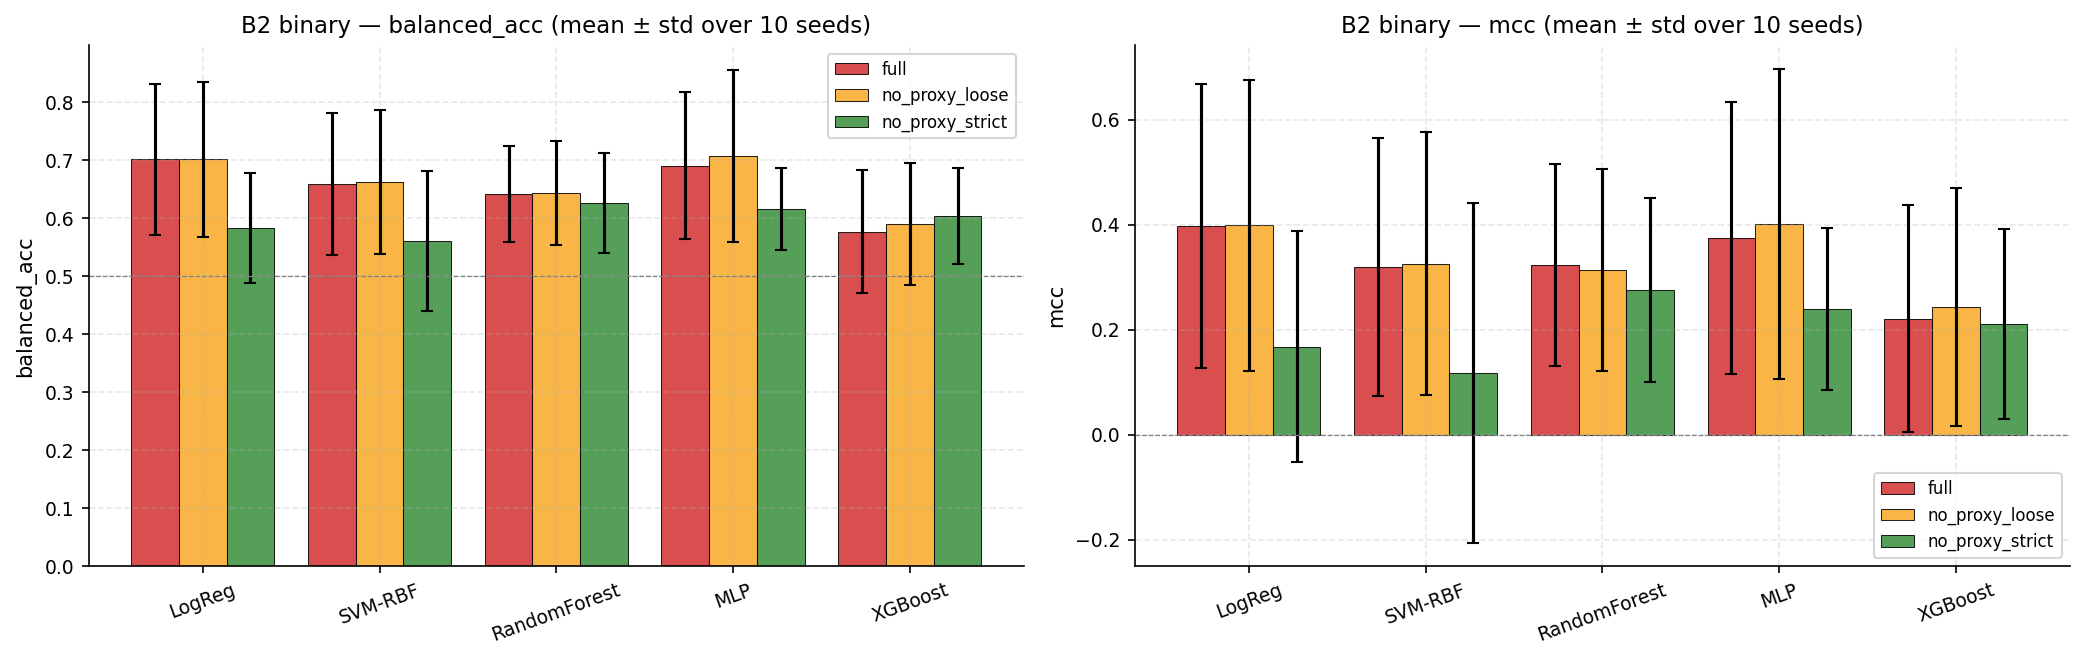

2026-05-12 21:54:02,993 | INFO | [§B2-Classical] 150 runs saved.


In [11]:
# ══════════════════════════════════════════════════════════════════════
# §B2-Classical — Classical models, B2 binary, multi-seed × 3 modes
# Inputs: B2_PREPARED (from §3c), SEEDS_B2_BINARY, FEATURE_SET_MODES,
#         make_classical_models (from §9), compute_metrics (from §8)
# ══════════════════════════════════════════════════════════════════════

if not CONFIG.get('RUN_CLASSICAL', True):
    log.warning("Section skipped (CONFIG['RUN_CLASSICAL'] = False).")
    results_b2_classical_df = pd.DataFrame()
else:

    def _b2_eval_classical(prep, model):
        X_tr, y_tr = prep['X_train_bal'], prep['y_train_bal']
        X_te, y_te = prep['X_test_sc'],   prep['y_test']
        t0 = time.time()
        model.fit(X_tr, y_tr)
        elapsed = time.time() - t0
        y_pred = model.predict(X_te)
        y_proba = None
        if hasattr(model, 'predict_proba'):
            try: y_proba = model.predict_proba(X_te)
            except Exception: y_proba = None
        elif hasattr(model, 'decision_function'):
            try:
                df_scores = model.decision_function(X_te)
                # Build a 2-col proba-like array for compute_metrics
                from scipy.special import expit
                p1 = expit(df_scores)
                y_proba = np.column_stack([1 - p1, p1])
            except Exception: y_proba = None
        m = compute_metrics(y_te, y_pred, y_proba=y_proba, n_classes=2)
        m['train_time_s'] = elapsed
        return m

    results_b2_classical = []
    _t0_all = time.time()
    for s in SEEDS_B2_BINARY:
        for mode in FEATURE_SET_MODES:
            prep = B2_PREPARED[(s, mode)]
            models = make_classical_models(s)
            for name, mdl in models.items():
                if mdl is None:
                    continue
                try:
                    m = _b2_eval_classical(prep, mdl)
                except Exception as e:
                    log.warning(f'B2-classical [{name}|{mode}|seed={s}] failed: {e}')
                    continue
                m.update(model=name, seed=s, mode=mode,
                         n_features=prep['n_features'],
                         category='classical_b2', task='binary', protocol='B2_K10')
                results_b2_classical.append(m)
                log.info(f'B2-cls [{name:>12}|{mode:>15}|s={s}] '
                         f'BalAcc={m["balanced_acc"]:.3f} F1m={m["f1_macro"]:.3f} '
                         f'MCC={m["mcc"]:.3f} '
                         f'AUC={(m.get("roc_auc_ovr") or float("nan")):.3f}')

    print(f'\nClassical B2 retrain: {time.time()-_t0_all:.1f}s '
          f'for {len(results_b2_classical)} runs')

    results_b2_classical_df = pd.DataFrame(results_b2_classical)
    results_b2_classical_df.to_csv(
        DIRS['classical'] / 'b2_classical_per_run.csv', index=False)

    # ── Aggregate mean ± std per (model, mode) ───────────────────────────
    _metrics_keep = ['balanced_acc', 'f1_macro', 'mcc', 'roc_auc_ovr',
                     'pr_auc', 'accuracy', 'far_class0', 'dr_anomaly']
    _metrics_present = [m for m in _metrics_keep
                        if m in results_b2_classical_df.columns]
    agg = (results_b2_classical_df
           .groupby(['model', 'mode'])[_metrics_present]
           .agg(['mean', 'std']).round(4))
    agg.columns = [f'{c[0]}_{c[1]}' for c in agg.columns]
    agg = agg.reset_index()
    agg.to_csv(DIRS['classical'] / 'b2_classical_aggregated.csv', index=False)

    print('\n=== B2 Binary | Classical Models | mean across 10 seeds ===')
    _disp_cols = ['model', 'mode'] + [f'{m}_mean' for m in
        ['balanced_acc', 'f1_macro', 'mcc', 'roc_auc_ovr']]
    print(agg[_disp_cols].to_string(index=False))

    # ── Plot: bar chart per model with full/loose/strict bars ────────────
    _models_order = ['LogReg', 'SVM-RBF', 'RandomForest', 'MLP', 'XGBoost']
    _models_present = [m for m in _models_order
                       if m in agg['model'].unique()]
    _modes_order = ['full', 'no_proxy_loose', 'no_proxy_strict']
    _mode_colors = {'full': '#d32f2f',
                    'no_proxy_loose': '#f9a825',
                    'no_proxy_strict': '#388e3c'}

    fig_b2c, axes_b2c = plt.subplots(1, 2, figsize=(14, 4.5))
    for ax, metric in zip(axes_b2c, ['balanced_acc', 'mcc']):
        x = np.arange(len(_models_present))
        w = 0.27
        for j, mode in enumerate(_modes_order):
            sub = agg[(agg['mode'] == mode) & (agg['model'].isin(_models_present))]
            sub = sub.set_index('model').reindex(_models_present)
            means = sub[f'{metric}_mean'].values
            stds  = sub[f'{metric}_std'].values
            ax.bar(x + (j - 1) * w, means, w, yerr=stds, capsize=3,
                   label=mode, color=_mode_colors[mode],
                   edgecolor='black', linewidth=0.5, alpha=0.85)
        ax.set_xticks(x)
        ax.set_xticklabels(_models_present, rotation=20)
        ax.set_ylabel(metric)
        ax.set_title(f'B2 binary — {metric} (mean ± std over 10 seeds)')
        ax.legend(fontsize=8)
        ax.axhline(0.5 if metric == 'balanced_acc' else 0.0,
                   color='gray', linestyle='--', linewidth=0.6,
                   label='_chance' if metric == 'balanced_acc' else '_zero')
    plt.tight_layout()
    fig_b2c.savefig(DIRS['classical'] / 'b2_classical_bars.png',
                    dpi=150, bbox_inches='tight')
    plt.show(); plt.close()
    log.info(f'[§B2-Classical] {len(results_b2_classical)} runs saved.')


## §9 — Quantum Kernel SVM under B2 binary (multi-seed × 3 modes)

Quantum Kernel SVM = ZZFeatureMap → FidelityQuantumKernel → SVC (sklearn). QSVC is O(N²) in kernel evaluations, so each fit uses a **balanced subsample of size `CONFIG.get('QSVC_BUDGET', 200)` per class** of the angle-encoded training set. Evaluated on the full per-seed test fold.

30 fits total (10 seeds × 3 modes). Outputs `b2_qsvc_per_run.csv`, `b2_qsvc_aggregated.csv`, `b2_qsvc_bars.png`.


In [12]:
# ══════════════════════════════════════════════════════════════════════
# §9 — QSVC under B2 binary (multi-seed × 3 modes)
# ══════════════════════════════════════════════════════════════════════

if not CONFIG.get('RUN_QSVC', True):
    log.warning("Section skipped (CONFIG['RUN_QSVC'] = False).")
    results_b2_qsvc_df = pd.DataFrame()
else:
    if not HAS_QSVC:
        log.error('QSVC unavailable (qiskit-machine-learning not installed) — §9 skipped.')
        results_b2_qsvc_df = pd.DataFrame()
    else:
        QSVC_BUDGET = CONFIG.get('QSVC_BUDGET', 200)  # per class
        results_b2_qsvc = []
        _t0_qsvc = time.time()

        for s in SEEDS_B2_BINARY:
            for mode in FEATURE_SET_MODES:
                prep = B2_PREPARED[(s, mode)]
                Xq_tr_bal = prep['Xq_train_bal']
                y_tr_bal  = prep['y_train_bal']
                Xq_te     = prep['Xq_test']
                y_te      = prep['y_test']

                min_cls = int(min(np.bincount(y_tr_bal.astype(int))))
                n_per_q = min(QSVC_BUDGET, min_cls)
                Xq_qk, yq_qk = balanced_subsample(
                    Xq_tr_bal, y_tr_bal, n_per_q, seed=s + 1)

                n_feats = Xq_qk.shape[1]
                fmap = ZZFeatureMap(feature_dimension=n_feats, reps=2,
                                    entanglement='linear')
                kern = FidelityQuantumKernel(feature_map=fmap)
                qsvc = QSVC(quantum_kernel=kern, C=1.0)

                t0 = time.time()
                try:
                    qsvc.fit(Xq_qk, yq_qk)
                except Exception as e:
                    log.warning(f'B2-QSVC [{mode}|seed={s}] fit failed: {e}')
                    continue
                elapsed = time.time() - t0

                y_pred = qsvc.predict(Xq_te)
                # QSVC does not expose probabilities natively; use decision-function
                # surrogate where available
                y_proba = None
                if hasattr(qsvc, 'decision_function'):
                    try:
                        from scipy.special import expit
                        df_scores = qsvc.decision_function(Xq_te)
                        p1 = expit(df_scores)
                        y_proba = np.column_stack([1 - p1, p1])
                    except Exception:
                        y_proba = None

                m = compute_metrics(y_te, y_pred, y_proba, n_classes=2)
                m.update(dict(
                    model='QSVC', category='quantum_kernel_b2',
                    mode=mode, seed=s, protocol='B2_K10', task='binary',
                    train_time_s=elapsed, n_train=len(yq_qk),
                    feature_map='ZZ_reps2_linear', n_qfeat=n_feats))
                results_b2_qsvc.append(m)
                log.info(f'B2-QSVC [{mode:>15}|s={s}] '
                         f'BalAcc={m["balanced_acc"]:.3f} F1m={m["f1_macro"]:.3f} '
                         f'MCC={m["mcc"]:.3f} '
                         f'AUC={(m.get("roc_auc_ovr") or float("nan")):.3f} '
                         f't={elapsed:.1f}s')

        print(f'\nQSVC B2 total: {(time.time()-_t0_qsvc)/60:.1f} min '
              f'over {len(results_b2_qsvc)} runs')
        results_b2_qsvc_df = pd.DataFrame(results_b2_qsvc)
        results_b2_qsvc_df.to_csv(DIRS['quantum'] / 'b2_qsvc_per_run.csv', index=False)

        if len(results_b2_qsvc_df):
            _metrics = [m for m in ['balanced_acc','f1_macro','mcc','roc_auc_ovr',
                                    'pr_auc','accuracy','far_class0','dr_anomaly']
                        if m in results_b2_qsvc_df.columns]
            agg_qsvc = (results_b2_qsvc_df.groupby('mode')[_metrics]
                        .agg(['mean','std']).round(4))
            agg_qsvc.columns = [f'{c[0]}_{c[1]}' for c in agg_qsvc.columns]
            agg_qsvc = agg_qsvc.reset_index()
            agg_qsvc.to_csv(DIRS['quantum'] / 'b2_qsvc_aggregated.csv', index=False)
            print('\n=== B2 Binary | QSVC | mean ± std across 10 seeds ===')
            _disp = ['mode'] + [f'{m}_mean' for m in
                                ['balanced_acc','f1_macro','mcc','roc_auc_ovr']]
            print(agg_qsvc[_disp].to_string(index=False))

            # Plot
            fig_q, axes_q = plt.subplots(1, 2, figsize=(11, 4))
            _modes_order = ['full', 'no_proxy_loose', 'no_proxy_strict']
            _mode_colors = {'full': '#d32f2f',
                            'no_proxy_loose': '#f9a825',
                            'no_proxy_strict': '#388e3c'}
            for ax, metric in zip(axes_q, ['balanced_acc', 'mcc']):
                means = [agg_qsvc.loc[agg_qsvc['mode']==m, f'{metric}_mean'].iloc[0]
                         for m in _modes_order]
                stds  = [agg_qsvc.loc[agg_qsvc['mode']==m, f'{metric}_std'].iloc[0]
                         for m in _modes_order]
                ax.errorbar(_modes_order, means, yerr=stds, marker='o', markersize=9,
                            capsize=4, linewidth=2, color='#6a1b9a')
                for i, m in enumerate(_modes_order):
                    ax.scatter([i], [means[i]], s=120, color=_mode_colors[m],
                               edgecolor='black', zorder=3)
                ax.axhline(0.5 if metric=='balanced_acc' else 0.0,
                           color='gray', linestyle='--', linewidth=0.7)
                ax.set_ylabel(metric); ax.set_title(f'QSVC — {metric}')
                ax.set_xticks(range(3))
                ax.set_xticklabels(_modes_order, rotation=15)
            plt.suptitle('B2 binary QSVC: proxy-contamination ablation (10 seeds)',
                         fontsize=11)
            plt.tight_layout()
            fig_q.savefig(DIRS['quantum'] / 'b2_qsvc_bars.png',
                          dpi=150, bbox_inches='tight')
            plt.show(); plt.close()


2026-05-12 21:54:03,010 | WARNING | Section skipped (CONFIG['RUN_QSVC'] = False).


## §10 — DRU Binary under B2 (multi-seed × 3 modes)

**Quantum headline.** 30 DRU fits (10 seeds × 3 modes), each on a balanced disjoint subset A; subset B is held out for the hybrid section (§11) without leakage.

`dru_b2_by_key[(seed, mode)] = (dru, Xq_dru, y_dru, Xq_hyb, y_hyb)` is consumed by §11.

Outputs `b2_dru_per_run.csv`, `b2_dru_aggregated.csv`, `b2_dru_degradation.png` (full→loose→strict degradation slope).


2026-05-12 21:57:53,637 | INFO | B2-DRU [           full|s=0] BalAcc=0.759 F1m=0.748 MCC=0.506 AUC=0.817 t=228.9s
2026-05-12 22:01:43,905 | INFO | B2-DRU [ no_proxy_loose|s=0] BalAcc=0.360 F1m=0.338 MCC=-0.312 AUC=0.219 t=228.6s
2026-05-12 22:05:35,452 | INFO | B2-DRU [no_proxy_strict|s=0] BalAcc=0.128 F1m=0.136 MCC=-0.725 AUC=0.019 t=229.9s
2026-05-12 22:09:32,549 | INFO | B2-DRU [           full|s=1] BalAcc=0.197 F1m=0.194 MCC=-0.372 AUC=0.222 t=235.4s
2026-05-12 22:13:19,632 | INFO | B2-DRU [ no_proxy_loose|s=1] BalAcc=0.173 F1m=0.241 MCC=-0.369 AUC=0.042 t=225.4s
2026-05-12 22:17:12,891 | INFO | B2-DRU [no_proxy_strict|s=1] BalAcc=0.260 F1m=0.180 MCC=-0.317 AUC=0.205 t=231.5s
2026-05-12 22:20:59,440 | INFO | B2-DRU [           full|s=2] BalAcc=0.617 F1m=0.602 MCC=0.242 AUC=0.710 t=224.9s
2026-05-12 22:24:51,185 | INFO | B2-DRU [ no_proxy_loose|s=2] BalAcc=0.581 F1m=0.477 MCC=0.287 AUC=0.858 t=230.1s
2026-05-12 22:28:52,995 | INFO | B2-DRU [no_proxy_strict|s=2] BalAcc=0.619 F1m=0.60


DRU B2 retrain total: 117.0 min over 30 runs

=== B2 Binary | DRU | mean ± std across 10 seeds (per mode) ===
           mode  balanced_acc_mean  f1_macro_mean  mcc_mean  roc_auc_ovr_mean  balanced_acc_std  f1_macro_std  mcc_std  roc_auc_ovr_std
           full             0.6447         0.5684    0.3184            0.7566            0.1919        0.2155   0.3127           0.2599
 no_proxy_loose             0.5546         0.5100    0.1519            0.5748            0.1948        0.1624   0.3265           0.3132
no_proxy_strict             0.5354         0.5096    0.0778            0.5567            0.2067        0.2027   0.3747           0.2749


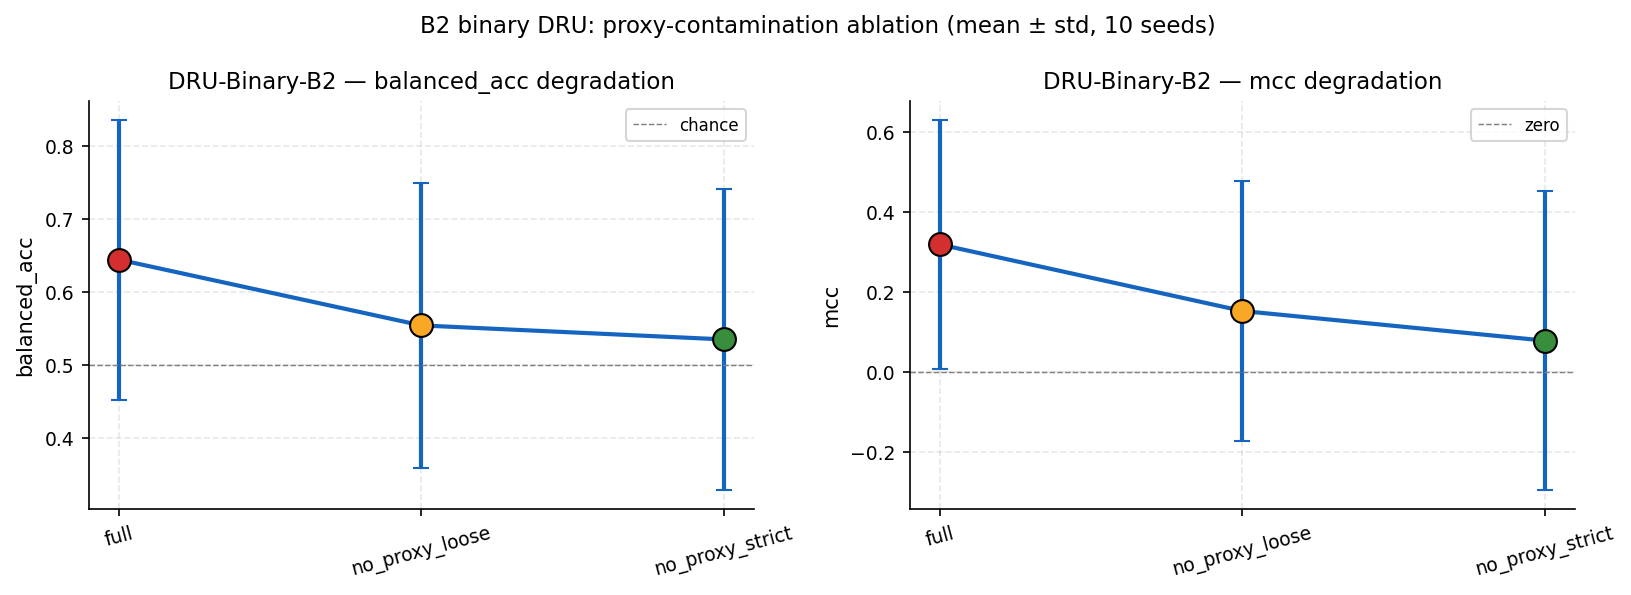

2026-05-12 23:51:01,403 | INFO | [§B2-DRU] 30 DRU runs saved; 30 trained models retained for hybrid.


In [13]:
# ══════════════════════════════════════════════════════════════════════
# §B2-DRU — DRU under B2 binary protocol, multi-seed × 3 modes
# Inputs: B2_PREPARED, SEEDS_B2_BINARY, FEATURE_SET_MODES,
#         DataReuploadingClassifier, balanced_subsample, compute_metrics,
#         CONFIG (DRU_*)
# Outputs:
#   results_b2_dru_df  — 30 per-run metrics
#   dru_b2_by_key      — {(seed, mode): (trained_dru, Xq_train_used, y_used)}
# ══════════════════════════════════════════════════════════════════════

if not CONFIG.get('RUN_DRU', True):
    log.warning("Section skipped (CONFIG['RUN_DRU'] = False).")
    results_b2_dru_df = pd.DataFrame()
else:

    results_b2_dru = []
    dru_b2_by_key  = {}
    _t0_all_dru = time.time()

    for s in SEEDS_B2_BINARY:
        for mode in FEATURE_SET_MODES:
            prep = B2_PREPARED[(s, mode)]
            Xq_tr_bal = prep['Xq_train_bal']
            y_tr_bal  = prep['y_train_bal']    # binary 0/1
            Xq_te     = prep['Xq_test']
            y_te      = prep['y_test']         # binary

            # Per-seed quantum training budget. We use disjoint subsets so
            # the §B2-Hybrid section can reuse the held-out half without
            # leakage. Constraint: 2 * n_per_safe <= min_cls.
            n_per_b = CONFIG['DRU_TRAIN_BUDGET'] // 2
            min_cls = int(min(np.bincount(y_tr_bal.astype(int))))
            n_per_safe = min(n_per_b, min_cls // 2)
            if n_per_safe < 10:
                log.warning(f'B2-DRU [{mode}|seed={s}]: only {n_per_safe}/class '
                            f'available for disjoint subset — skipping.')
                continue

            (Xq_dru, y_dru), (Xq_hyb, y_hyb) = make_disjoint_quantum_subsets(
                Xq_tr_bal, y_tr_bal, n_per_safe, seed=s + 1)

            dru = DataReuploadingClassifier(
                n_qubits=CONFIG['DRU_N_QUBITS'],
                n_layers=CONFIG['DRU_N_LAYERS'],
                encoding=CONFIG['DRU_ENCODING'],
                entanglement=CONFIG['DRU_ENTANGLEMENT'],
                optimizer=CONFIG['DRU_OPTIMIZER'],
                max_iter=CONFIG['DRU_MAX_ITER'],
                seed=s + 1,
            )
            _t0 = time.time()
            try:
                dru.fit(Xq_dru, y_dru)
            except Exception as e:
                log.warning(f'B2-DRU [{mode}|seed={s}] fit failed: {e}')
                continue
            elapsed = time.time() - _t0

            y_pred  = dru.predict(Xq_te)
            y_proba = dru.predict_proba(Xq_te)
            m = compute_metrics(y_te, y_pred, y_proba, n_classes=2)
            m.update(dict(
                model='DRU-Binary-B2', category='quantum_b2',
                mode=mode, seed=s,
                protocol='B2_K10', task='binary',
                n_qubits=CONFIG['DRU_N_QUBITS'],
                n_layers=CONFIG['DRU_N_LAYERS'],
                n_train=len(y_dru),
                train_time_s=elapsed,
            ))
            results_b2_dru.append(m)
            dru_b2_by_key[(s, mode)] = (dru, Xq_dru, y_dru, Xq_hyb, y_hyb)
            log.info(f'B2-DRU [{mode:>15}|s={s}] '
                     f'BalAcc={m["balanced_acc"]:.3f} '
                     f'F1m={m["f1_macro"]:.3f} '
                     f'MCC={m["mcc"]:.3f} '
                     f'AUC={(m.get("roc_auc_ovr") or float("nan")):.3f} '
                     f't={elapsed:.1f}s')

    print(f'\nDRU B2 retrain total: {(time.time()-_t0_all_dru)/60:.1f} min '
          f'over {len(results_b2_dru)} runs')

    results_b2_dru_df = pd.DataFrame(results_b2_dru)
    results_b2_dru_df.to_csv(DIRS['quantum'] / 'b2_dru_per_run.csv', index=False)

    # ── Aggregate mean ± std per mode ────────────────────────────────────
    _metrics_keep = ['balanced_acc', 'f1_macro', 'mcc', 'roc_auc_ovr',
                     'pr_auc', 'accuracy', 'far_class0', 'dr_anomaly',
                     'train_time_s']
    _metrics_present = [m for m in _metrics_keep
                        if m in results_b2_dru_df.columns]
    agg_dru = (results_b2_dru_df
               .groupby('mode')[_metrics_present]
               .agg(['mean', 'std']).round(4))
    agg_dru.columns = [f'{c[0]}_{c[1]}' for c in agg_dru.columns]
    agg_dru = agg_dru.reset_index()
    agg_dru.to_csv(DIRS['quantum'] / 'b2_dru_aggregated.csv', index=False)

    print('\n=== B2 Binary | DRU | mean ± std across 10 seeds (per mode) ===')
    _disp = ['mode'] + [f'{m}_mean' for m in ['balanced_acc','f1_macro','mcc','roc_auc_ovr']]
    _disp_std = [f'{m}_std' for m in ['balanced_acc','f1_macro','mcc','roc_auc_ovr']]
    print(agg_dru[_disp + _disp_std].to_string(index=False))

    # ── Plot: degradation slope full → loose → strict ────────────────────
    fig_dru, axes_dru = plt.subplots(1, 2, figsize=(11, 4))
    _modes_order = ['full', 'no_proxy_loose', 'no_proxy_strict']
    _mode_colors = {'full': '#d32f2f',
                    'no_proxy_loose': '#f9a825',
                    'no_proxy_strict': '#388e3c'}
    for ax, metric in zip(axes_dru, ['balanced_acc', 'mcc']):
        means = [agg_dru.loc[agg_dru['mode']==m, f'{metric}_mean'].iloc[0]
                 for m in _modes_order]
        stds  = [agg_dru.loc[agg_dru['mode']==m, f'{metric}_std'].iloc[0]
                 for m in _modes_order]
        ax.errorbar(_modes_order, means, yerr=stds, marker='o', markersize=9,
                    capsize=4, linewidth=2, color='#1565c0')
        for i, m in enumerate(_modes_order):
            ax.scatter([i], [means[i]], s=120, color=_mode_colors[m],
                       edgecolor='black', zorder=3)
        ax.axhline(0.5 if metric=='balanced_acc' else 0.0,
                   color='gray', linestyle='--', linewidth=0.7,
                   label='chance' if metric=='balanced_acc' else 'zero')
        ax.set_ylabel(metric)
        ax.set_title(f'DRU-Binary-B2 — {metric} degradation')
        ax.set_xticks(range(3))
        ax.set_xticklabels(_modes_order, rotation=15)
        ax.legend(fontsize=8)
    plt.suptitle('B2 binary DRU: proxy-contamination ablation (mean ± std, 10 seeds)',
                 fontsize=11)
    plt.tight_layout()
    fig_dru.savefig(DIRS['quantum'] / 'b2_dru_degradation.png',
                    dpi=150, bbox_inches='tight')
    plt.show(); plt.close()
    log.info(f'[§B2-DRU] {len(results_b2_dru)} DRU runs saved; '
             f'{len(dru_b2_by_key)} trained models retained for hybrid.')

## §11 — Hybrid DRU-XGBoost vs. Paired Classical Controls

Six XGBoost variants under the identical (seed, mode) protocol:

| Variant | Input | Controls for |
|---|---|---|
| **XGB-raw** | Angles only | Floor |
| **XGB-PCA** | Angles ∥ PCA(angles) | Linear extension |
| **XGB-Poly2** | Angles ∥ Poly²(angles) | Non-linear deterministic |
| **XGB-RandomRBF** | Angles ∥ RBFSampler(angles) | Non-linear random |
| **XGB-DRU-untrained** | Angles ∥ EVs(untrained DRU) | Random quantum feature map |
| **XGB-DRU-trained** | Angles ∥ EVs(trained DRU) | **Headline hybrid** |

For the headline claim to hold, **XGB-DRU-trained** must beat Poly2, RandomRBF, AND DRU-untrained consistently across seeds and modes.


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/scipy/_lib/pyprima/common/preproc.py:68: UserWarning: COBYLA: Invalid MAXFUN; it should be at least num_vars + 2; it is set to 32
  warn(f'{solver}: Invalid MAXFUN; it should be at least {min_maxfun_str}; it is set to {maxfun}')
2026-05-12 23:51:04,852 | INFO | B2-Hyb [           XGB-raw|           full|s=0] BalAcc=0.500 MCC=0.000 AUC=0.267 d=5
2026-05-12 23:51:04,983 | INFO | B2-Hyb [           XGB-PCA|           full|s=0] BalAcc=0.500 MCC=0.000 AUC=0.157 d=10
2026-05-12 23:51:05,115 | INFO | B2-Hyb [         XGB-Poly2|           full|s=0] BalAcc=0.500 MCC=0.000 AUC=0.316 d=25
2026-05-12 23:51:05,245 | INFO | B2-Hyb [     XGB-RandomRBF|           full|s=0] BalAcc=0.500 MCC=0.000 AUC=0.622 d=21
2026-05-12 23:51:05,372 | INFO | B2-Hyb [ XGB-DRU-untrained|           full|s=0] BalAcc=0.500 MCC=0.000 AUC=0.310 d=6
2026-05-12 23:51:05,511 | INFO | B2-Hyb [   XGB-DRU-trained|           full|s=0] BalAcc=0.363 MCC=


Hybrid B2 retrain total: 2.1 min over 180 runs (0 (seed,mode) skipped).

=== B2 Binary | Hybrid + Paired controls | mean ± std (10 seeds) ===
          variant            mode  balanced_acc_mean  mcc_mean  roc_auc_ovr_mean
  XGB-DRU-trained            full             0.5775    0.1974            0.7514
XGB-DRU-untrained            full             0.4917    0.0099            0.5326
          XGB-PCA            full             0.5071    0.0484            0.6164
        XGB-Poly2            full             0.5107    0.0600            0.6259
    XGB-RandomRBF            full             0.6133    0.2597            0.8006
          XGB-raw            full             0.4515   -0.0442            0.4526
  XGB-DRU-trained  no_proxy_loose             0.5673    0.1851            0.5419
XGB-DRU-untrained  no_proxy_loose             0.5724    0.1888            0.4927
          XGB-PCA  no_proxy_loose             0.6061    0.2664            0.6565
        XGB-Poly2  no_proxy_loose             0

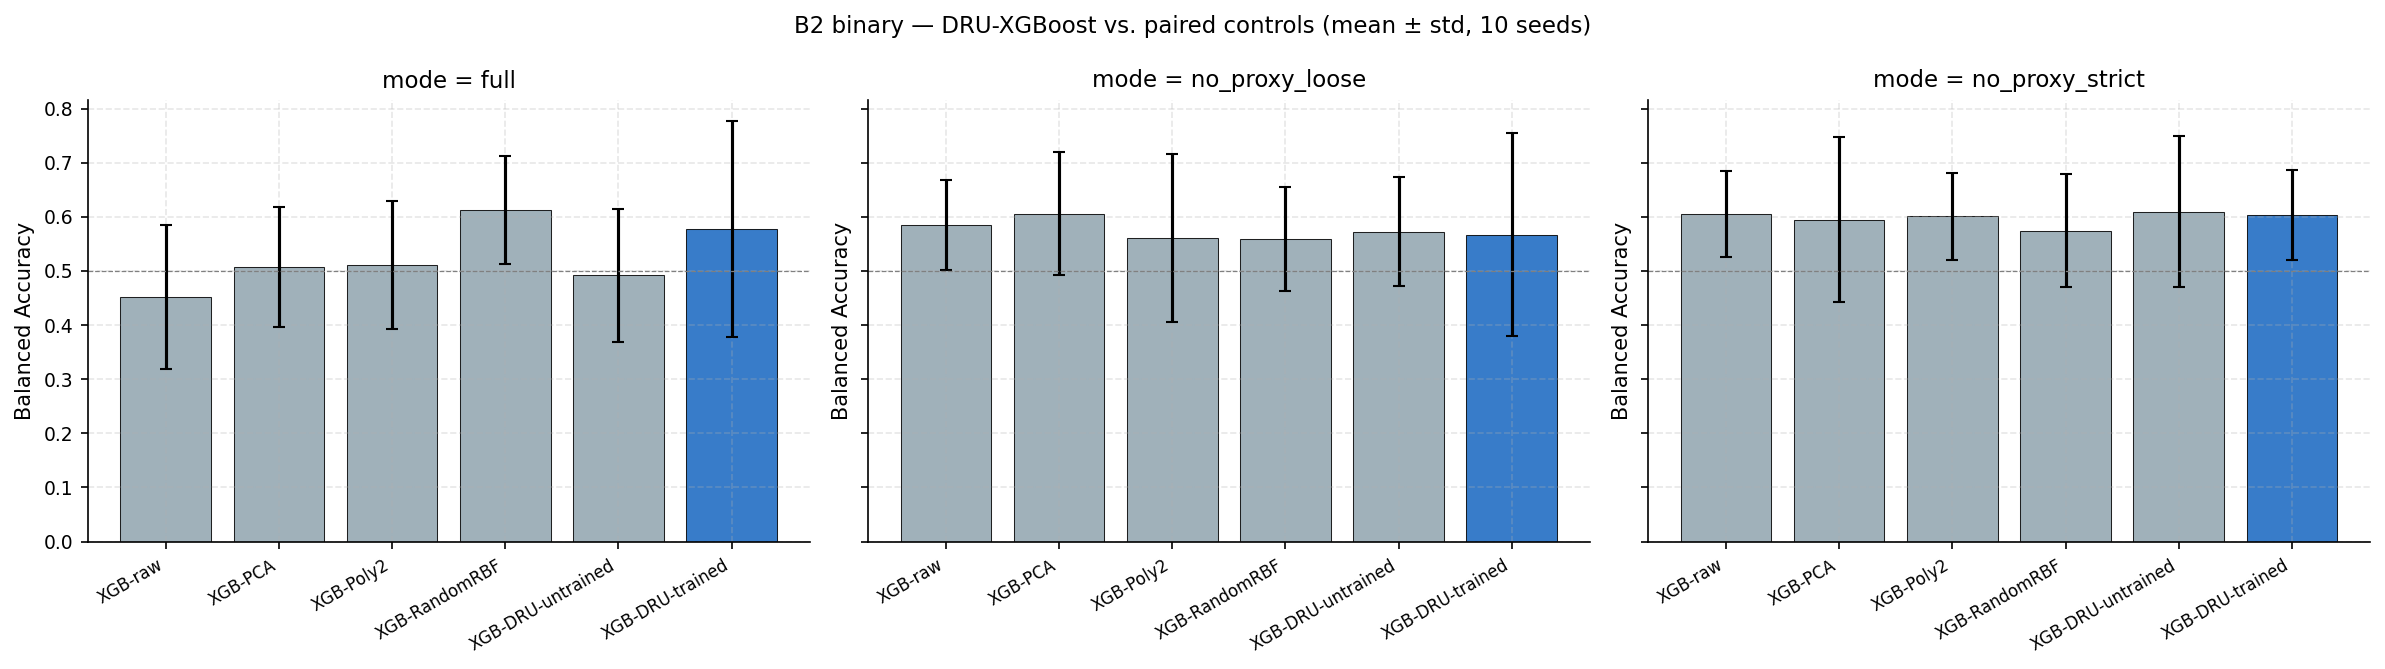

2026-05-12 23:53:05,922 | INFO | [§B2-Hybrid] 180 runs across 6 variants × 3 modes × 10 seeds.


In [14]:
# ══════════════════════════════════════════════════════════════════════
# §B2-Hybrid — Paired controls for DRU-XGBoost
# Inputs: B2_PREPARED, dru_b2_by_key (with disjoint Xq_hyb/y_hyb),
#         DataReuploadingClassifier, extract_quantum_features,
#         compute_metrics, XGBClassifier (HAS_XGB), CONFIG
# Outputs:
#   results_b2_hybrid_df — per-run metrics across all variants
# ══════════════════════════════════════════════════════════════════════

if not CONFIG.get('RUN_HYBRID', True):
    log.warning("Section skipped (CONFIG['RUN_HYBRID'] = False).")
    results_b2_hybrid_df = pd.DataFrame()
else:
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import PolynomialFeatures
    from sklearn.kernel_approximation import RBFSampler

    if not HAS_XGB:
        log.error('XGBoost unavailable — §B2-Hybrid skipped.')
    else:
        def _make_xgb(seed):
            return XGBClassifier(
                n_estimators=CONFIG.get('CLASSICAL_N_EST', 200),
                max_depth=6, learning_rate=0.1,
                objective='binary:logistic',
                eval_metric='logloss',
                tree_method='hist',
                random_state=seed, n_jobs=-1,
                verbosity=0)

        def _make_untrained_dru(seed, n_qubits, n_layers):
            """Untrained DRU — random weights, no .fit() call."""
            d = DataReuploadingClassifier(
                n_qubits=n_qubits, n_layers=n_layers,
                encoding=CONFIG['DRU_ENCODING'],
                entanglement=CONFIG['DRU_ENTANGLEMENT'],
                optimizer=CONFIG['DRU_OPTIMIZER'],
                max_iter=1, seed=seed)
            # Fit on a 4-sample stub just to initialize weights_; then overwrite
            # weights with fresh random draw so the model is effectively untrained.
            rng = np.random.default_rng(seed * 7919 + 13)
            # Minimal fit to set up internal state (some implementations need it)
            try:
                _stub_X = np.zeros((4, n_qubits))
                _stub_y = np.array([0, 1, 0, 1])
                d.fit(_stub_X, _stub_y)
            except Exception:
                pass
            if hasattr(d, 'weights_'):
                d.weights_ = rng.uniform(-np.pi, np.pi, size=d.weights_.shape)
            return d

        def _eval_xgb_variant(name, X_tr, y_tr, X_te, y_te, seed):
            xgb = _make_xgb(seed)
            t0 = time.time()
            xgb.fit(X_tr, y_tr)
            elapsed = time.time() - t0
            y_pred  = xgb.predict(X_te)
            y_proba = xgb.predict_proba(X_te)
            m = compute_metrics(y_te, y_pred, y_proba, n_classes=2)
            m['train_time_s'] = elapsed
            m['variant']      = name
            m['n_features']   = X_tr.shape[1]
            return m

        results_b2_hybrid = []
        _t0_hyb = time.time()
        _skipped = 0

        for s in SEEDS_B2_BINARY:
            for mode in FEATURE_SET_MODES:
                if (s, mode) not in dru_b2_by_key:
                    _skipped += 1
                    continue
                dru, Xq_dru, y_dru, Xq_hyb, y_hyb = dru_b2_by_key[(s, mode)]
                prep = B2_PREPARED[(s, mode)]
                Xq_te = prep['Xq_test']
                y_te  = prep['y_test']

                # ── Build feature matrices for each variant ──────────────
                # 1. raw angles only
                X_raw_tr, X_raw_te = Xq_hyb, Xq_te

                # 2. PCA(Xq) — same dim as Xq
                _n_pca = min(Xq_hyb.shape[1], Xq_hyb.shape[0])
                pca = PCA(n_components=_n_pca, random_state=s + 1)
                Xpca_tr = pca.fit_transform(Xq_hyb)
                Xpca_te = pca.transform(Xq_te)
                X_pca_tr = np.hstack([Xq_hyb, Xpca_tr])
                X_pca_te = np.hstack([Xq_te,  Xpca_te])

                # 3. Polynomial deg=2 (interaction + squares)
                poly = PolynomialFeatures(degree=2, interaction_only=False,
                                           include_bias=False)
                Xpoly_tr = poly.fit_transform(Xq_hyb)
                Xpoly_te = poly.transform(Xq_te)
                X_poly_tr = np.hstack([Xq_hyb, Xpoly_tr])
                X_poly_te = np.hstack([Xq_te,  Xpoly_te])

                # 4. Random RBF features (~ similar count to Poly deg=2)
                rbf = RBFSampler(gamma=1.0,
                                  n_components=max(Xpoly_tr.shape[1] - Xq_hyb.shape[1], 16),
                                  random_state=s + 1)
                Xrbf_tr = rbf.fit_transform(Xq_hyb)
                Xrbf_te = rbf.transform(Xq_te)
                X_rbf_tr = np.hstack([Xq_hyb, Xrbf_tr])
                X_rbf_te = np.hstack([Xq_te,  Xrbf_te])

                # 5. Untrained-DRU observables
                try:
                    dru_unt = _make_untrained_dru(
                        seed=s + 1,
                        n_qubits=CONFIG['DRU_N_QUBITS'],
                        n_layers=CONFIG['DRU_N_LAYERS'])
                    Xunt_tr = extract_quantum_features(dru_unt, Xq_hyb)
                    Xunt_te = extract_quantum_features(dru_unt, Xq_te)
                    X_unt_tr = np.hstack([Xq_hyb, Xunt_tr])
                    X_unt_te = np.hstack([Xq_te,  Xunt_te])
                    _untrained_ok = True
                except Exception as e:
                    log.warning(f'Untrained-DRU obs failed [{mode}|s={s}]: {e}')
                    _untrained_ok = False

                # 6. Trained-DRU observables (the hybrid headline)
                Xevs_tr = extract_quantum_features(dru, Xq_hyb)
                Xevs_te = extract_quantum_features(dru, Xq_te)
                X_trd_tr = np.hstack([Xq_hyb, Xevs_tr])
                X_trd_te = np.hstack([Xq_te,  Xevs_te])

                # ── Train+eval every variant ─────────────────────────────
                _variants = [
                    ('XGB-raw',            X_raw_tr,  X_raw_te),
                    ('XGB-PCA',            X_pca_tr,  X_pca_te),
                    ('XGB-Poly2',          X_poly_tr, X_poly_te),
                    ('XGB-RandomRBF',      X_rbf_tr,  X_rbf_te),
                    ('XGB-DRU-trained',    X_trd_tr,  X_trd_te),
                ]
                if _untrained_ok:
                    _variants.insert(4,
                        ('XGB-DRU-untrained', X_unt_tr,  X_unt_te))

                for vname, Xtr, Xte in _variants:
                    try:
                        m = _eval_xgb_variant(vname, Xtr, y_hyb, Xte, y_te,
                                              seed=s + 1)
                    except Exception as e:
                        log.warning(f'B2-Hybrid [{vname}|{mode}|s={s}] failed: {e}')
                        continue
                    m.update(seed=s, mode=mode, model='hybrid_xgb',
                             protocol='B2_K10', task='binary',
                             category='hybrid_b2',
                             n_qubits=CONFIG['DRU_N_QUBITS'],
                             n_layers=CONFIG['DRU_N_LAYERS'])
                    results_b2_hybrid.append(m)
                    log.info(f'B2-Hyb [{vname:>18}|{mode:>15}|s={s}] '
                             f'BalAcc={m["balanced_acc"]:.3f} '
                             f'MCC={m["mcc"]:.3f} '
                             f'AUC={(m.get("roc_auc_ovr") or float("nan")):.3f} '
                             f'd={m["n_features"]}')

        print(f'\nHybrid B2 retrain total: '
              f'{(time.time()-_t0_hyb)/60:.1f} min over '
              f'{len(results_b2_hybrid)} runs ({_skipped} (seed,mode) skipped).')

        results_b2_hybrid_df = pd.DataFrame(results_b2_hybrid)
        results_b2_hybrid_df.to_csv(
            DIRS['hybrid'] / 'b2_hybrid_per_run.csv', index=False)

        # ── Aggregate mean ± std per (variant, mode) ─────────────────────
        _metrics_keep = ['balanced_acc', 'f1_macro', 'mcc', 'roc_auc_ovr',
                         'pr_auc', 'accuracy']
        _present = [m for m in _metrics_keep
                    if m in results_b2_hybrid_df.columns]
        agg_hyb = (results_b2_hybrid_df
                   .groupby(['variant', 'mode'])[_present]
                   .agg(['mean', 'std']).round(4))
        agg_hyb.columns = [f'{c[0]}_{c[1]}' for c in agg_hyb.columns]
        agg_hyb = agg_hyb.reset_index()
        agg_hyb.to_csv(DIRS['hybrid'] / 'b2_hybrid_aggregated.csv', index=False)

        print('\n=== B2 Binary | Hybrid + Paired controls | mean ± std (10 seeds) ===')
        _disp = ['variant','mode'] + \
                [f'{m}_mean' for m in ['balanced_acc','mcc','roc_auc_ovr']]
        print(agg_hyb[_disp].sort_values(['mode','variant']).to_string(index=False))

        # ── Plot: grouped bars per mode, with all 6 variants ─────────────
        _variants_order = ['XGB-raw', 'XGB-PCA', 'XGB-Poly2',
                           'XGB-RandomRBF', 'XGB-DRU-untrained',
                           'XGB-DRU-trained']
        _variants_present = [v for v in _variants_order
                             if v in agg_hyb['variant'].unique()]
        _modes_order = ['full', 'no_proxy_loose', 'no_proxy_strict']

        fig_hyb, axes_hyb = plt.subplots(1, 3, figsize=(16, 4.5), sharey=True)
        for ax, mode in zip(axes_hyb, _modes_order):
            sub = (agg_hyb[agg_hyb['mode'] == mode]
                   .set_index('variant').reindex(_variants_present))
            means = sub['balanced_acc_mean'].values
            stds  = sub['balanced_acc_std'].values
            colors = ['#90A4AE'] * (len(_variants_present) - 1) + ['#1565c0']
            ax.bar(range(len(_variants_present)), means, yerr=stds, capsize=3,
                   color=colors, edgecolor='black', linewidth=0.5, alpha=0.85)
            ax.set_xticks(range(len(_variants_present)))
            ax.set_xticklabels(_variants_present, rotation=30, ha='right',
                               fontsize=8)
            ax.set_ylabel('Balanced Accuracy')
            ax.set_title(f'mode = {mode}')
            ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.6)
        plt.suptitle('B2 binary — DRU-XGBoost vs. paired controls (mean ± std, 10 seeds)',
                     fontsize=11)
        plt.tight_layout()
        fig_hyb.savefig(DIRS['hybrid'] / 'b2_hybrid_paired_controls.png',
                        dpi=150, bbox_inches='tight')
        plt.show(); plt.close()
        log.info(f'[§B2-Hybrid] {len(results_b2_hybrid)} runs across '
                 f'{len(_variants_present)} variants × 3 modes × '
                 f'{len(SEEDS_B2_BINARY)} seeds.')


## §12 — Fault-3 One-vs-Fault Secondary Task (K=20 blocks)

The §3.2 diagnostic showed that of the four anomaly classes, **only Fault-3** is evaluable under a group-aware split (it lives across multiple temporal blocks). This section runs the one-vs-fault binary task `y = (label == 3)` restricted to `{label = 0, label = 3}` samples, with `GroupShuffleSplit` over **K=20** contiguous TimeUS blocks and 10 seeds.

A single model (XGBoost) is trained per seed × mode for clarity; the comparison is full / loose / strict to verify whether Fault-3 detection is dominated by proxies or by physical signal.

Outputs `b2_fault3_per_run.csv`, `b2_fault3_aggregated.csv`.


In [15]:
# ══════════════════════════════════════════════════════════════════════
# §12 — Fault-3 One-vs-Fault, group-aware K=20 blocks, multi-seed × 3 modes
# ══════════════════════════════════════════════════════════════════════

if not CONFIG.get('RUN_FAULT3', True):
    log.warning("Section skipped (CONFIG['RUN_FAULT3'] = False).")
    results_fault3_df = pd.DataFrame()
else:
    from sklearn.model_selection import GroupShuffleSplit
    from imblearn.combine import SMOTETomek

    if not HAS_XGB:
        log.error('XGBoost unavailable — §12 skipped.')
        results_fault3_df = pd.DataFrame()
    else:
        K_F3 = 20
        SEEDS_F3 = list(range(10))
        TRAIN_F = CONFIG['EPISODE_SPLIT']['train']
        VAL_F   = CONFIG['EPISODE_SPLIT']['val']
        TEST_F  = CONFIG['EPISODE_SPLIT']['test']

        # Restrict to {0, 3}
        mask_f3 = (y_raw == 0) | (y_raw == 3)
        N_f3 = int(mask_f3.sum())
        t_f3 = time_series_raw[mask_f3]
        y_f3 = (y_raw[mask_f3] == 3).astype(int)
        X_f3 = df_raw[FEATURE_COLS_FULL].values.astype(float)[mask_f3]

        # Build K-block ids in TimeUS order on the f3 subset
        _order_f3 = np.argsort(t_f3)
        block_f3  = np.empty(N_f3, dtype=int)
        block_f3[_order_f3] = np.minimum((np.arange(N_f3) * K_F3) // N_f3, K_F3 - 1)

        def _two_stage_groupsplit(groups, y_target, seed, test_size, val_size):
            gss_te = GroupShuffleSplit(n_splits=1, test_size=test_size,
                                        random_state=seed)
            i_tv, i_te = next(gss_te.split(np.zeros(len(groups)), y_target, groups))
            gss_va = GroupShuffleSplit(
                n_splits=1, test_size=val_size/(1.0-test_size), random_state=seed)
            i_tr_rel, i_va_rel = next(
                gss_va.split(np.zeros(len(i_tv)), y_target[i_tv], groups[i_tv]))
            return i_tv[i_tr_rel], i_tv[i_va_rel], i_te

        results_fault3 = []
        _t0_f3 = time.time()
        for s in SEEDS_F3:
            try:
                i_tr, i_va, i_te = _two_stage_groupsplit(
                    block_f3, y_f3, seed=s, test_size=TEST_F, val_size=VAL_F)
            except Exception as e:
                log.warning(f'F3 seed={s} split failed: {e}')
                continue
            # Skip if any split lacks a positive sample
            if not (np.any(y_f3[i_tr] == 1) and np.any(y_f3[i_va] == 1)
                    and np.any(y_f3[i_te] == 1)):
                log.warning(f'F3 seed={s}: missing positives in some split — skipping')
                continue

            X_tr_raw = X_f3[i_tr]; X_va_raw = X_f3[i_va]; X_te_raw = X_f3[i_te]
            y_tr = y_f3[i_tr];      y_va = y_f3[i_va];      y_te = y_f3[i_te]

            # Robust scaler per seed
            from sklearn.preprocessing import RobustScaler
            sc = RobustScaler()
            X_tr_sc = sc.fit_transform(X_tr_raw)
            X_te_sc = sc.transform(X_te_raw)

            for mode in FEATURE_SET_MODES:
                _, idx_mode = get_active_features(mode)
                X_tr_m = X_tr_sc[:, idx_mode]
                X_te_m = X_te_sc[:, idx_mode]

                # SMOTETomek inside train fold only
                smt = SMOTETomek(random_state=s + 1)
                try:
                    X_tr_bal, y_tr_bal = smt.fit_resample(X_tr_m, y_tr)
                except Exception as e:
                    log.warning(f'F3 [{mode}|seed={s}] SMOTETomek failed: {e}')
                    continue

                xgb_f3 = XGBClassifier(
                    n_estimators=CONFIG.get('CLASSICAL_N_EST', 200),
                    random_state=s + 1, objective='binary:logistic',
                    eval_metric='logloss', verbosity=0, n_jobs=-1)
                t0 = time.time()
                xgb_f3.fit(X_tr_bal, y_tr_bal)
                elapsed = time.time() - t0
                y_pred  = xgb_f3.predict(X_te_m)
                y_proba = xgb_f3.predict_proba(X_te_m)
                m = compute_metrics(y_te, y_pred, y_proba, n_classes=2)
                m.update(dict(
                    model='XGBoost-F3', category='fault3_ovf',
                    mode=mode, seed=s, protocol='B2_K20_F3',
                    task='binary_fault3', train_time_s=elapsed,
                    n_features=X_tr_bal.shape[1], n_train=len(y_tr_bal)))
                results_fault3.append(m)
                log.info(f'F3 [{mode:>15}|s={s}] '
                         f'BalAcc={m["balanced_acc"]:.3f} F1m={m["f1_macro"]:.3f} '
                         f'MCC={m["mcc"]:.3f} '
                         f'AUC={(m.get("roc_auc_ovr") or float("nan")):.3f}')

        print(f'\nFault-3 OvF total: {(time.time()-_t0_f3)/60:.1f} min '
              f'over {len(results_fault3)} runs')
        results_fault3_df = pd.DataFrame(results_fault3)
        results_fault3_df.to_csv(DIRS['summary'] / 'b2_fault3_per_run.csv',
                                  index=False)
        if len(results_fault3_df):
            _metrics = [m for m in ['balanced_acc','f1_macro','mcc','roc_auc_ovr',
                                    'pr_auc','accuracy','far_class0','dr_anomaly']
                        if m in results_fault3_df.columns]
            agg_f3 = (results_fault3_df.groupby('mode')[_metrics]
                      .agg(['mean','std']).round(4))
            agg_f3.columns = [f'{c[0]}_{c[1]}' for c in agg_f3.columns]
            agg_f3 = agg_f3.reset_index()
            agg_f3.to_csv(DIRS['summary'] / 'b2_fault3_aggregated.csv', index=False)
            print('\n=== Fault-3 OvF | XGBoost | mean ± std across 10 seeds ===')
            _disp = ['mode'] + [f'{m}_mean' for m in
                                ['balanced_acc','f1_macro','mcc','roc_auc_ovr']]
            print(agg_f3[_disp].to_string(index=False))


2026-05-12 23:53:05,941 | WARNING | F3 seed=0: missing positives in some split — skipping
2026-05-12 23:53:06,078 | INFO | F3 [           full|s=1] BalAcc=0.964 F1m=0.933 MCC=0.874 AUC=0.997
2026-05-12 23:53:06,198 | INFO | F3 [ no_proxy_loose|s=1] BalAcc=0.964 F1m=0.933 MCC=0.874 AUC=1.000
2026-05-12 23:53:06,326 | INFO | F3 [no_proxy_strict|s=1] BalAcc=0.500 F1m=0.427 MCC=0.000 AUC=0.955
2026-05-12 23:53:06,328 | WARNING | F3 seed=2: missing positives in some split — skipping
2026-05-12 23:53:06,330 | WARNING | F3 seed=3: missing positives in some split — skipping
2026-05-12 23:53:06,332 | WARNING | F3 seed=4: missing positives in some split — skipping
2026-05-12 23:53:06,334 | WARNING | F3 seed=5: missing positives in some split — skipping
2026-05-12 23:53:06,336 | WARNING | F3 seed=6: missing positives in some split — skipping
2026-05-12 23:53:06,338 | WARNING | F3 seed=7: missing positives in some split — skipping
2026-05-12 23:53:06,340 | WARNING | F3 seed=8: missing positives in


Fault-3 OvF total: 0.0 min over 3 runs

=== Fault-3 OvF | XGBoost | mean ± std across 10 seeds ===
           mode  balanced_acc_mean  f1_macro_mean  mcc_mean  roc_auc_ovr_mean
           full             0.9636         0.9327    0.8739            0.9970
 no_proxy_loose             0.9636         0.9327    0.8739            0.9999
no_proxy_strict             0.5000         0.4275    0.0000            0.9555


## §13 — Global Comparison: Classical vs Quantum vs Hybrid

Consolidates the per-run results from §8 (Classical), §9 (QSVC), §10 (DRU), §11 (Hybrid + controls) into a unified table and produces the cross-paradigm comparison figures.

Reports `mean ± std` over 10 seeds for **F1 macro, FAR, ROC AUC**, per feature mode, with classical / quantum / hybrid colour-coded.

Outputs:
- `final_comparison_master.csv` — unified per-run table.
- `final_comparison_f1.csv`, `final_comparison_far.csv`, `final_comparison_auc.csv` — per-metric pivoted summaries.
- `final_f1_comparison.png`, `final_far_comparison.png`, `final_auc_comparison.png`, `quantum_vs_classical_summary.png`.


2026-05-12 23:53:06,412 | INFO | [§13] master_df: 360 rows across 3 paradigms, 12 models.


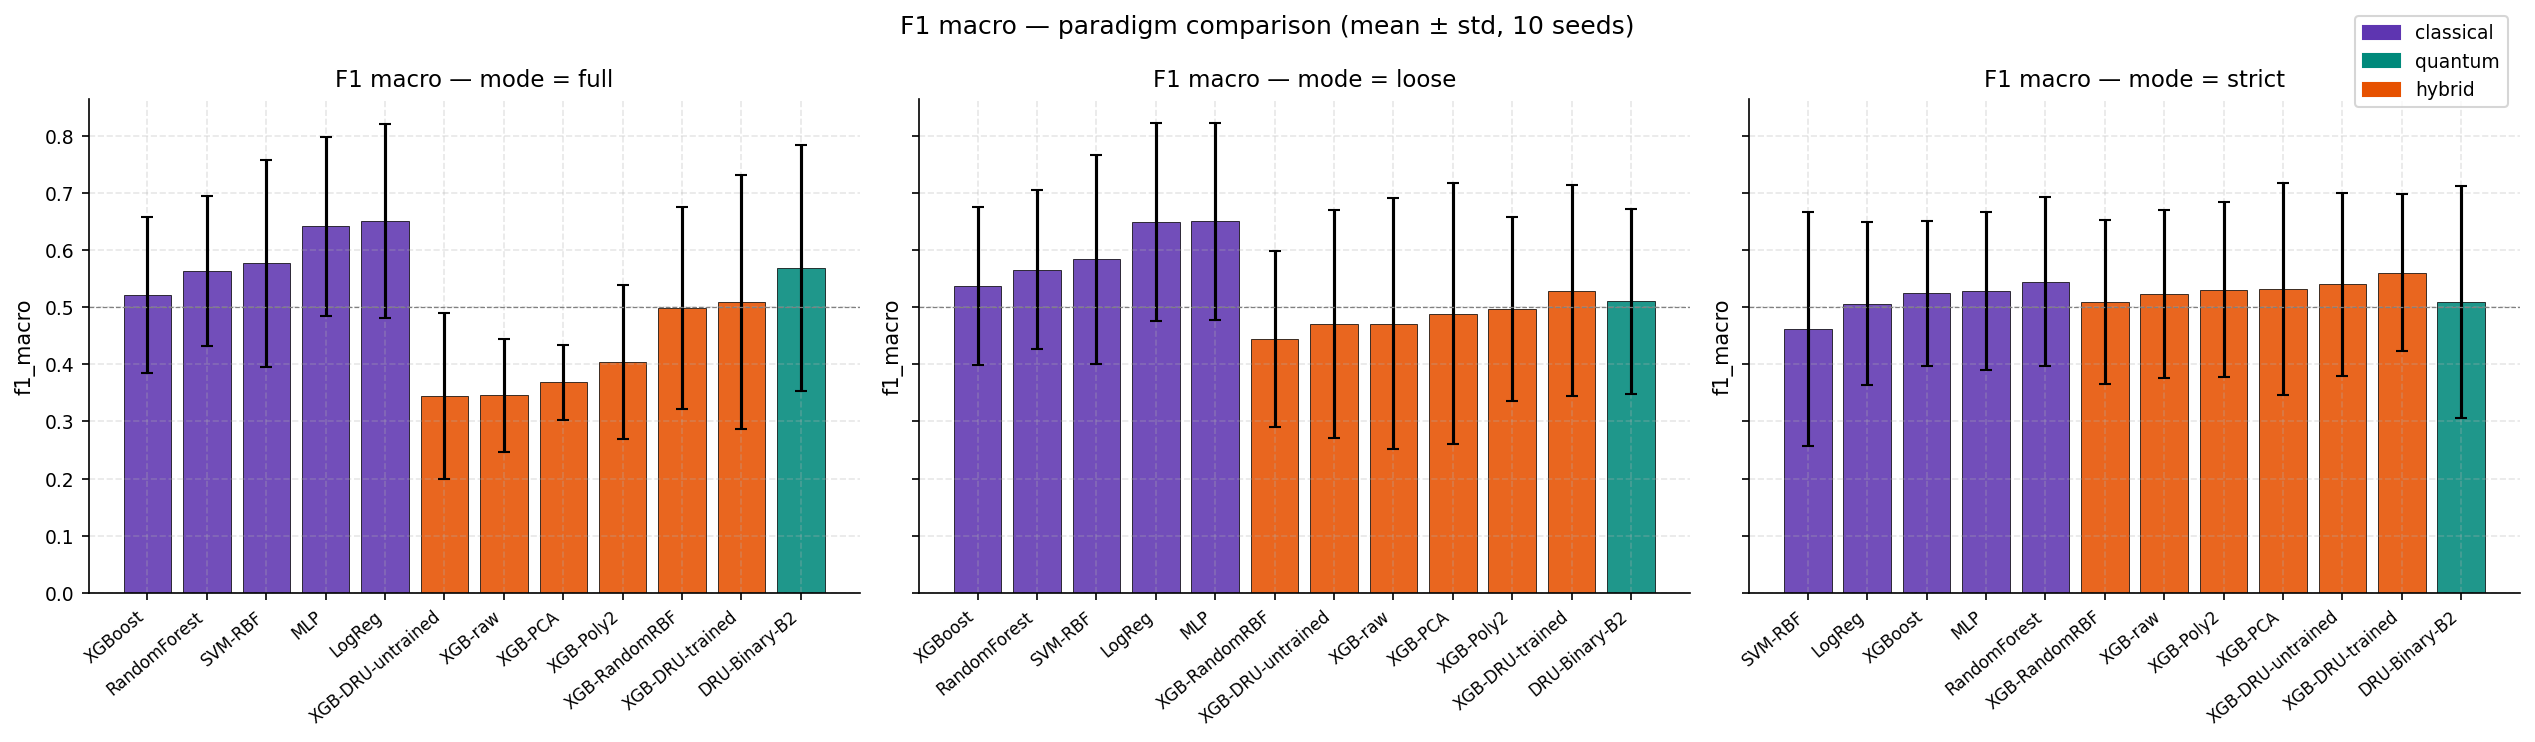

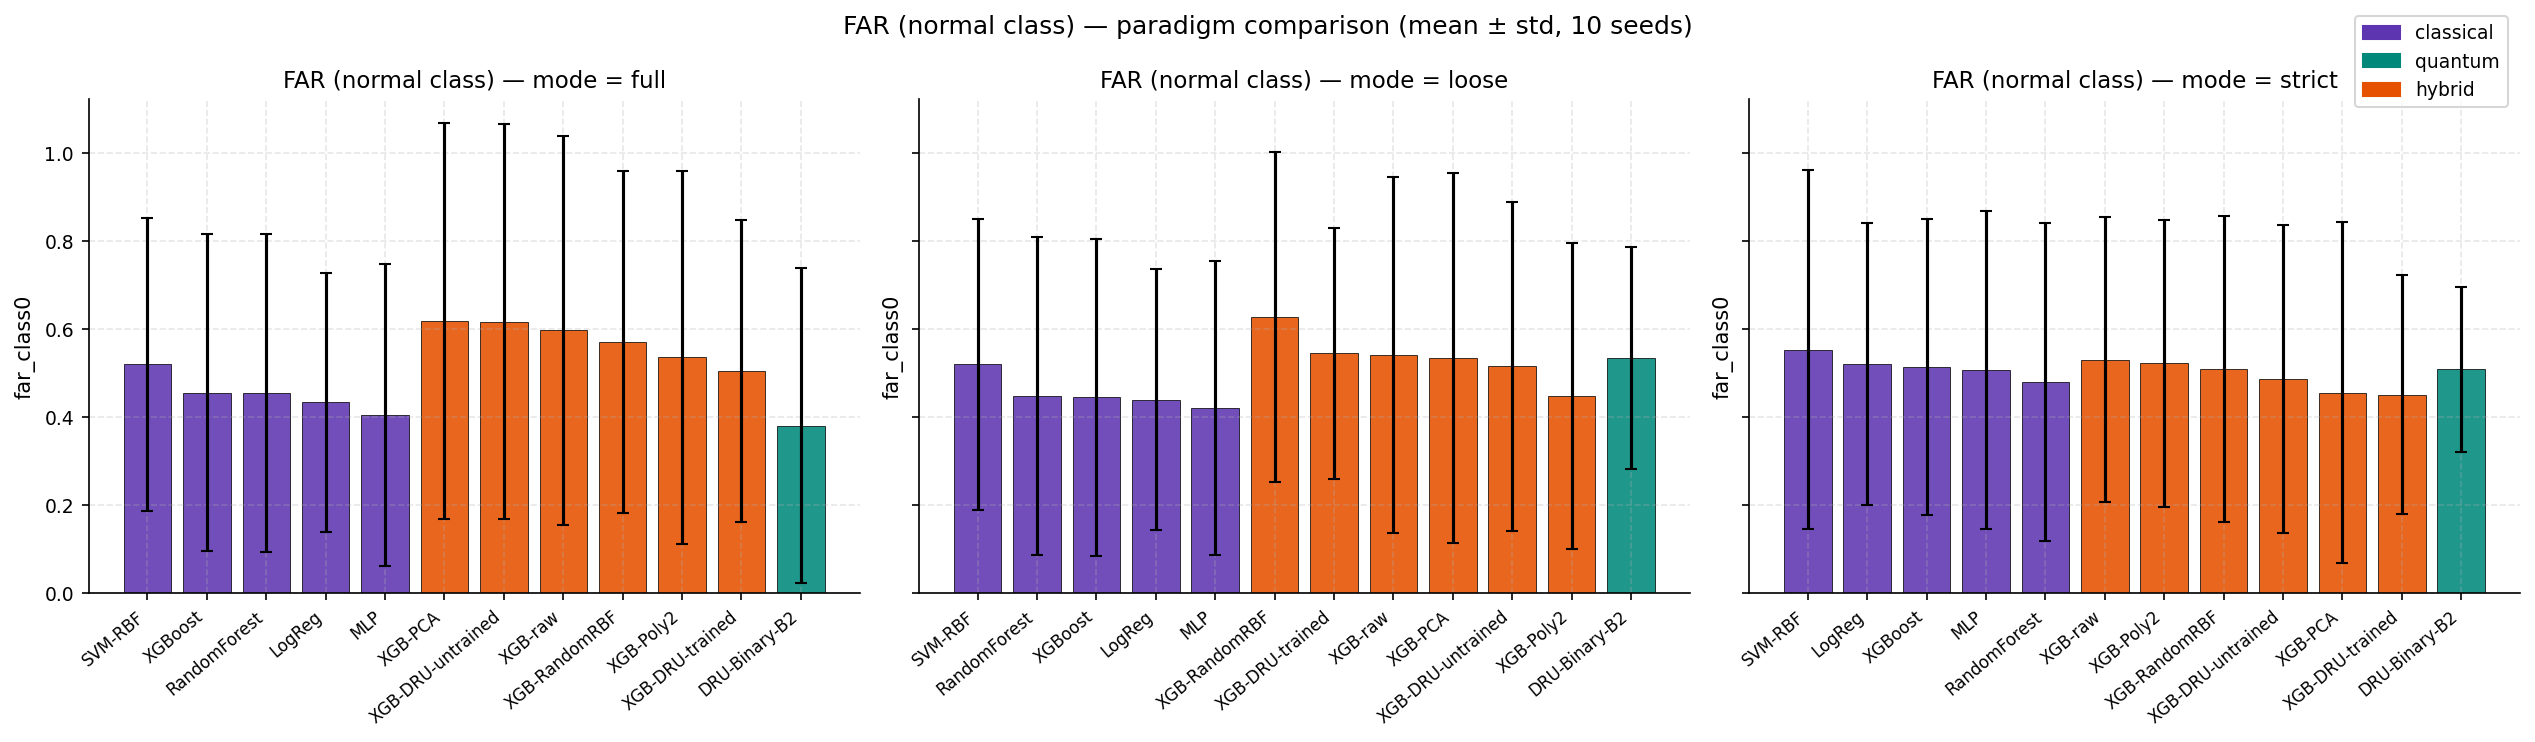

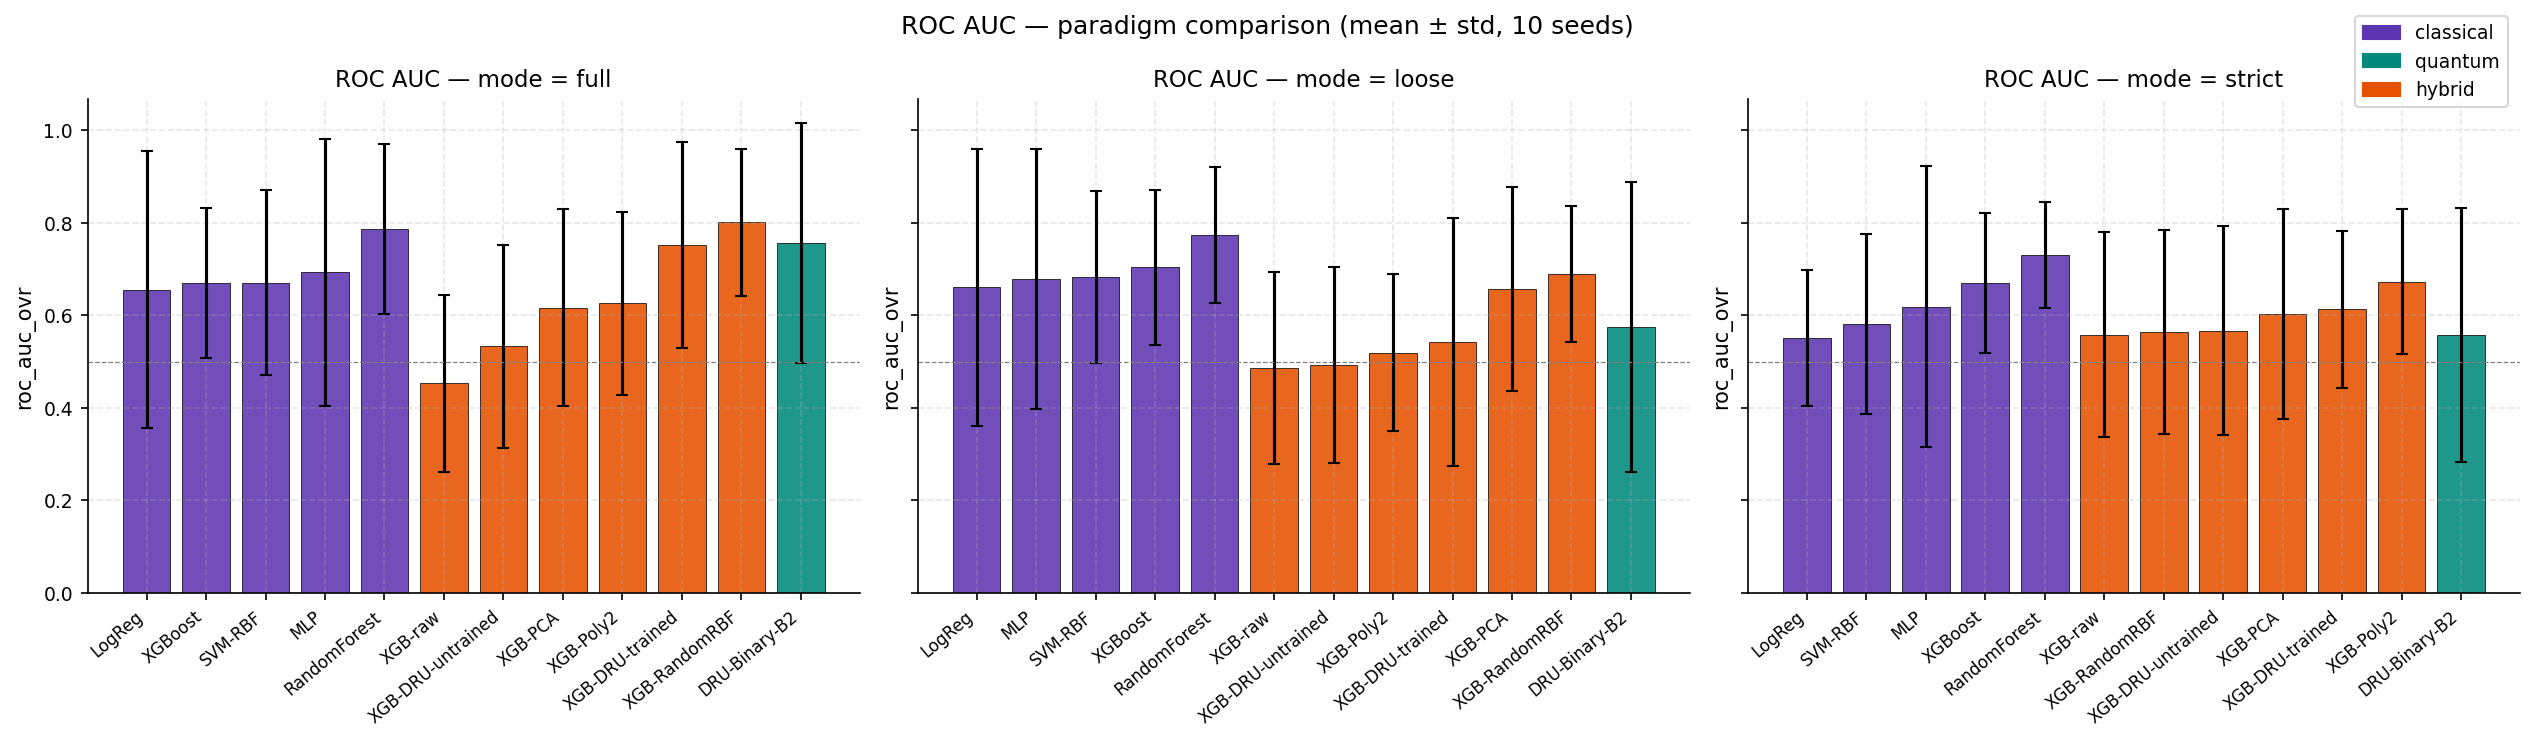

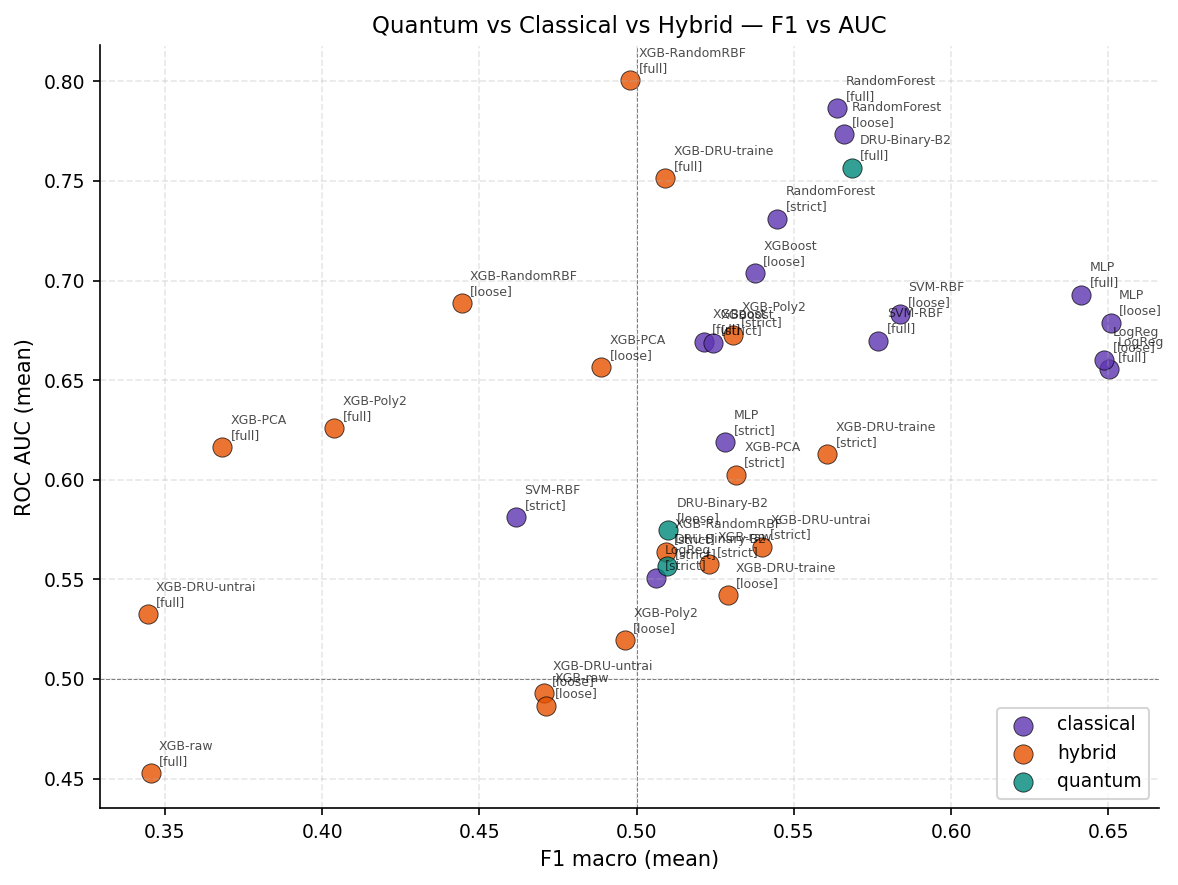


=== Best model per (metric, mode) ===
     metric            mode best_paradigm      best_model  best_value
   f1_macro            full     classical          LogReg      0.6502
   f1_macro  no_proxy_loose     classical             MLP      0.6507
   f1_macro no_proxy_strict        hybrid XGB-DRU-trained      0.5605
roc_auc_ovr            full        hybrid   XGB-RandomRBF      0.8006
roc_auc_ovr  no_proxy_loose     classical    RandomForest      0.7734
roc_auc_ovr no_proxy_strict     classical    RandomForest      0.7310
        mcc            full     classical          LogReg      0.3979
        mcc  no_proxy_loose     classical             MLP      0.4018
        mcc no_proxy_strict     classical    RandomForest      0.2752


In [16]:
# ══════════════════════════════════════════════════════════════════════
# §13 — Global Comparison: Classical vs Quantum vs Hybrid
# ══════════════════════════════════════════════════════════════════════

if not CONFIG.get('RUN_FINAL_REPORT', True):
    log.warning("Section skipped (CONFIG['RUN_FINAL_REPORT'] = False).")
else:
    PARADIGM_COLORS = {'classical': '#5e35b1', 'quantum': '#00897b',
                       'hybrid':    '#e65100'}

    # Collect per-run frames
    _frames = []
    for df_name, paradigm in [
        ('results_b2_classical_df', 'classical'),
        ('results_b2_qsvc_df',      'quantum'),
        ('results_b2_dru_df',       'quantum'),
        ('results_b2_hybrid_df',    'hybrid'),
    ]:
        if df_name in globals() and isinstance(globals()[df_name], pd.DataFrame) \
           and len(globals()[df_name]):
            d = globals()[df_name].copy()
            d['paradigm'] = paradigm
            # Standardize the model column (hybrid uses 'variant')
            if 'variant' in d.columns and 'model' in d.columns:
                d['model'] = d['variant']
            elif 'variant' in d.columns:
                d['model'] = d['variant']
            _frames.append(d)

    if not _frames:
        log.warning('§13: no per-run results found — run §8–§11 first.')
        master_df = pd.DataFrame()
    else:
        master_df = pd.concat(_frames, ignore_index=True, sort=False)
        master_df.to_csv(DIRS['summary'] / 'final_comparison_master.csv', index=False)
        log.info(f'[§13] master_df: {len(master_df)} rows across '
                 f'{master_df["paradigm"].nunique()} paradigms, '
                 f'{master_df["model"].nunique()} models.')

        _metric_cols = ['f1_macro', 'far_class0', 'roc_auc_ovr',
                        'balanced_acc', 'mcc', 'pr_auc', 'dr_anomaly']
        _metrics_present = [m for m in _metric_cols if m in master_df.columns]

        # Aggregated per (paradigm, model, mode)
        agg_master = (master_df
            .groupby(['paradigm', 'model', 'mode'])[_metrics_present]
            .agg(['mean','std']).round(4))
        agg_master.columns = [f'{c[0]}_{c[1]}' for c in agg_master.columns]
        agg_master = agg_master.reset_index()
        agg_master.to_csv(DIRS['summary'] / 'final_comparison_aggregated.csv',
                           index=False)

        # Per-metric pivot tables
        for metric, fname in [
            ('f1_macro',    'final_comparison_f1.csv'),
            ('far_class0',  'final_comparison_far.csv'),
            ('roc_auc_ovr', 'final_comparison_auc.csv'),
        ]:
            if metric not in master_df.columns:
                continue
            pivot = (master_df.groupby(['paradigm','model','mode'])[metric]
                     .agg(['mean','std']).round(4).reset_index())
            pivot = pivot.pivot(index=['paradigm','model'], columns='mode',
                                values=['mean','std'])
            pivot.to_csv(DIRS['summary'] / fname)

        # ── Comparison figures ───────────────────────────────────────────
        _modes_order = ['full', 'no_proxy_loose', 'no_proxy_strict']
        _modes_short = {'full': 'full', 'no_proxy_loose': 'loose',
                        'no_proxy_strict': 'strict'}

        def _plot_metric(metric, title, fname, lower_is_better=False):
            if metric not in master_df.columns: return
            fig, axes = plt.subplots(1, 3, figsize=(17, 5), sharey=True)
            for ax, mode in zip(axes, _modes_order):
                sub = (master_df[master_df['mode'] == mode]
                       .groupby(['paradigm', 'model'])[metric]
                       .agg(['mean','std']).reset_index())
                sub = sub.sort_values(['paradigm', 'mean'],
                                      ascending=[True, not lower_is_better])
                labels = [f"{r['model']}" for _, r in sub.iterrows()]
                colors = [PARADIGM_COLORS[r['paradigm']] for _, r in sub.iterrows()]
                x = np.arange(len(sub))
                ax.bar(x, sub['mean'].values, yerr=sub['std'].values,
                       capsize=3, color=colors, edgecolor='black', linewidth=0.4,
                       alpha=0.88)
                ax.set_xticks(x)
                ax.set_xticklabels(labels, rotation=40, ha='right', fontsize=8)
                ax.set_ylabel(metric)
                ax.set_title(f"{title} — mode = {_modes_short[mode]}")
                if metric == 'f1_macro' or metric == 'roc_auc_ovr':
                    ax.axhline(0.5, color='gray', linestyle='--', linewidth=0.6)
            # Legend
            from matplotlib.patches import Patch
            handles = [Patch(color=c, label=p) for p, c in PARADIGM_COLORS.items()]
            fig.legend(handles=handles, loc='upper right', fontsize=9,
                       bbox_to_anchor=(0.99, 0.99))
            plt.suptitle(f'{title} — paradigm comparison (mean ± std, 10 seeds)',
                         fontsize=12)
            plt.tight_layout()
            fig.savefig(DIRS['summary'] / fname, dpi=150, bbox_inches='tight')
            plt.show(); plt.close()

        _plot_metric('f1_macro',    'F1 macro',  'final_f1_comparison.png')
        _plot_metric('far_class0',  'FAR (normal class)',
                      'final_far_comparison.png', lower_is_better=True)
        _plot_metric('roc_auc_ovr', 'ROC AUC',   'final_auc_comparison.png')

        # ── Quantum vs Classical summary scatter ─────────────────────────
        fig_s, ax_s = plt.subplots(figsize=(8, 6))
        _grp = (master_df.groupby(['paradigm','model','mode'])[['f1_macro','roc_auc_ovr']]
                .mean().reset_index())
        for paradigm, grp in _grp.groupby('paradigm'):
            ax_s.scatter(grp['f1_macro'], grp['roc_auc_ovr'],
                         s=85, color=PARADIGM_COLORS[paradigm], alpha=0.8,
                         edgecolor='black', linewidth=0.4, label=paradigm)
        for _, r in _grp.iterrows():
            ax_s.annotate(f"{r['model'][:14]}\n[{_modes_short[r['mode']]}]",
                           (r['f1_macro'], r['roc_auc_ovr']),
                           fontsize=6, alpha=0.7,
                           xytext=(4, 4), textcoords='offset points')
        ax_s.set_xlabel('F1 macro (mean)')
        ax_s.set_ylabel('ROC AUC (mean)')
        ax_s.set_title('Quantum vs Classical vs Hybrid — F1 vs AUC')
        ax_s.axhline(0.5, color='gray', linestyle='--', linewidth=0.5)
        ax_s.axvline(0.5, color='gray', linestyle='--', linewidth=0.5)
        ax_s.legend(loc='lower right', fontsize=9)
        plt.tight_layout()
        fig_s.savefig(DIRS['summary'] / 'quantum_vs_classical_summary.png',
                       dpi=150, bbox_inches='tight')
        plt.show(); plt.close()

        # ── Best model per (metric, mode) ────────────────────────────────
        _best_rows = []
        for metric in ['f1_macro', 'roc_auc_ovr', 'mcc']:
            if metric not in master_df.columns: continue
            for mode in _modes_order:
                sub = master_df[master_df['mode'] == mode]
                agg = sub.groupby(['paradigm', 'model'])[metric].mean()
                best_idx = agg.idxmax()
                _best_rows.append({
                    'metric': metric, 'mode': mode,
                    'best_paradigm': best_idx[0], 'best_model': best_idx[1],
                    'best_value': round(agg[best_idx], 4)})
        best_df = pd.DataFrame(_best_rows)
        best_df.to_csv(DIRS['summary'] / 'final_best_per_metric_mode.csv',
                        index=False)
        print('\n=== Best model per (metric, mode) ===')
        print(best_df.to_string(index=False))

## §14 — Quantum Advantage Auto-Report

Synthesises the §13 comparison into a single markdown file `quantum_advantage_report.md`. The report:

- Quantifies DRU vs. best classical (per mode, on F1 macro and ROC AUC).
- Quantifies XGB-DRU-trained vs. {XGB-Poly2, XGB-RandomRBF, XGB-DRU-untrained}.
- Reports the `full → strict` degradation slope per paradigm.
- Selects the appropriate conclusion among the four pre-specified options.

The report is deterministic given the per-run CSVs; re-running this cell after re-running models updates it.


In [17]:
# ══════════════════════════════════════════════════════════════════════
# §14 — Quantum Advantage Auto-Report
# ══════════════════════════════════════════════════════════════════════

if not CONFIG.get('RUN_FINAL_REPORT', True):
    log.warning("Section skipped (CONFIG['RUN_FINAL_REPORT'] = False).")
else:
    if 'master_df' not in globals() or len(master_df) == 0:
        log.warning('§14: master_df is empty — run §13 first.')
    else:
        report_lines = []
        report_lines.append('# Quantum Advantage Report — TLM:UAV')
        report_lines.append('')
        report_lines.append(f'**Protocol:** B2 group-aware, K=10 blocks, '
                            f'{len(SEEDS_B2_BINARY)} seeds, binary task.')
        report_lines.append(f'**Feature modes:** {", ".join(FEATURE_SET_MODES)}.')
        report_lines.append(f'**Models compared:** classical (5), quantum (DRU, QSVC), '
                            f'hybrid (6 variants including paired controls).')
        report_lines.append('')

        # Helper: get mean metric per (paradigm, model, mode)
        def _mean_metric(metric, paradigm=None, model=None, mode=None):
            df = master_df.copy()
            if paradigm is not None: df = df[df['paradigm'] == paradigm]
            if model    is not None: df = df[df['model']    == model]
            if mode     is not None: df = df[df['mode']     == mode]
            if metric not in df.columns or not len(df): return None
            return float(df[metric].mean())

        def _std_metric(metric, paradigm=None, model=None, mode=None):
            df = master_df.copy()
            if paradigm is not None: df = df[df['paradigm'] == paradigm]
            if model    is not None: df = df[df['model']    == model]
            if mode     is not None: df = df[df['mode']     == mode]
            if metric not in df.columns or not len(df): return None
            return float(df[metric].std())

        # 1. Headline metric tables
        report_lines.append('## 1. Headline metrics (mean ± std across 10 seeds)')
        for metric, label in [('f1_macro', 'F1 macro'),
                              ('roc_auc_ovr', 'ROC AUC'),
                              ('far_class0', 'FAR (normal)')]:
            if metric not in master_df.columns: continue
            report_lines.append(f'\n### {label}')
            report_lines.append('')
            report_lines.append('| Model | full | loose | strict |')
            report_lines.append('|---|---|---|---|')
            for (paradigm, model), grp in (
                    master_df.groupby(['paradigm','model'])):
                row = [f'{model} ({paradigm})']
                for mode in FEATURE_SET_MODES:
                    m = _mean_metric(metric, paradigm=paradigm,
                                      model=model, mode=mode)
                    s = _std_metric(metric, paradigm=paradigm,
                                     model=model, mode=mode)
                    row.append(f'{m:.3f} ± {s:.3f}' if m is not None else '—')
                report_lines.append('| ' + ' | '.join(row) + ' |')

        # 2. DRU vs best classical
        report_lines.append('\n## 2. DRU vs. best classical (per mode)')
        report_lines.append('')
        report_lines.append('| Mode | Best classical (F1) | DRU (F1) | gap |')
        report_lines.append('|---|---|---|---|')
        for mode in FEATURE_SET_MODES:
            cl = (master_df[(master_df['paradigm']=='classical') &
                            (master_df['mode']==mode)]
                  .groupby('model')['f1_macro'].mean())
            if len(cl) == 0: continue
            best_cl_name, best_cl_val = cl.idxmax(), cl.max()
            dru_val = _mean_metric('f1_macro', paradigm='quantum',
                                    model='DRU-Binary-B2', mode=mode)
            if dru_val is None: continue
            gap = dru_val - best_cl_val
            report_lines.append(
                f'| {mode} | {best_cl_name} = {best_cl_val:.3f} | '
                f'{dru_val:.3f} | {gap:+.3f} |')

        # 3. Hybrid vs paired controls
        report_lines.append('\n## 3. XGB-DRU-trained vs. paired controls (F1 macro)')
        report_lines.append('')
        report_lines.append('| Mode | DRU-trained | Poly2 | RandomRBF | '
                            'DRU-untrained | beats all 3? |')
        report_lines.append('|---|---|---|---|---|---|')
        for mode in FEATURE_SET_MODES:
            trd = _mean_metric('f1_macro', paradigm='hybrid',
                                model='XGB-DRU-trained', mode=mode)
            ply = _mean_metric('f1_macro', paradigm='hybrid',
                                model='XGB-Poly2',       mode=mode)
            rbf = _mean_metric('f1_macro', paradigm='hybrid',
                                model='XGB-RandomRBF',   mode=mode)
            unt = _mean_metric('f1_macro', paradigm='hybrid',
                                model='XGB-DRU-untrained', mode=mode)
            if trd is None: continue
            beats = all(trd > v for v in [ply, rbf, unt] if v is not None)
            row = [mode]
            for v in (trd, ply, rbf, unt):
                row.append(f'{v:.3f}' if v is not None else '—')
            row.append('✓' if beats else '✗')
            report_lines.append('| ' + ' | '.join(row) + ' |')

        # 4. Degradation slope full → strict
        report_lines.append('\n## 4. Degradation slope (full → strict, F1 macro)')
        report_lines.append('')
        report_lines.append('| Model | full | strict | Δ |')
        report_lines.append('|---|---|---|---|')
        for (paradigm, model), _ in master_df.groupby(['paradigm','model']):
            f_full   = _mean_metric('f1_macro', paradigm=paradigm,
                                    model=model, mode='full')
            f_strict = _mean_metric('f1_macro', paradigm=paradigm,
                                    model=model, mode='no_proxy_strict')
            if f_full is None or f_strict is None: continue
            report_lines.append(
                f'| {model} ({paradigm}) | {f_full:.3f} | {f_strict:.3f} | '
                f'{f_strict - f_full:+.3f} |')

        # 5. Auto-conclusion
        report_lines.append('\n## 5. Conclusion')
        report_lines.append('')
        dru_strict = _mean_metric('f1_macro', model='DRU-Binary-B2',
                                   mode='no_proxy_strict')
        best_cl_strict = None
        if len(master_df[(master_df['paradigm']=='classical') &
                         (master_df['mode']=='no_proxy_strict')]):
            cl_st = (master_df[(master_df['paradigm']=='classical') &
                               (master_df['mode']=='no_proxy_strict')]
                     .groupby('model')['f1_macro'].mean())
            best_cl_strict = cl_st.max() if len(cl_st) else None
        trd_strict = _mean_metric('f1_macro', model='XGB-DRU-trained',
                                   mode='no_proxy_strict')
        ply_strict = _mean_metric('f1_macro', model='XGB-Poly2',
                                   mode='no_proxy_strict')
        rbf_strict = _mean_metric('f1_macro', model='XGB-RandomRBF',
                                   mode='no_proxy_strict')
        unt_strict = _mean_metric('f1_macro', model='XGB-DRU-untrained',
                                   mode='no_proxy_strict')

        verdicts = []
        if dru_strict is not None and best_cl_strict is not None:
            if dru_strict >= best_cl_strict - 0.02 and dru_strict > 0.6:
                verdicts.append('- **DRU is competitive even in `strict`** '
                                f'(F1 = {dru_strict:.3f} vs best classical '
                                f'{best_cl_strict:.3f}).')
            elif dru_strict > 0.55:
                verdicts.append('- **DRU is inferior to the best classical model**, '
                                'but retains useful signal under proxy-free '
                                f'evaluation (F1 = {dru_strict:.3f}).')
            else:
                verdicts.append('- **DRU collapses toward chance under `strict`** '
                                f'(F1 = {dru_strict:.3f}); much of its observed '
                                'performance under richer feature sets depends on '
                                'contextual proxies.')
        if all(v is not None for v in [trd_strict, ply_strict,
                                         rbf_strict, unt_strict]):
            if trd_strict > max(ply_strict, rbf_strict, unt_strict) + 0.01:
                verdicts.append(f'- **Hybrid XGB-DRU-trained beats all three '
                                f'controls (Poly2, RandomRBF, DRU-untrained) under '
                                f'`strict`** by '
                                f'{trd_strict - max(ply_strict, rbf_strict, unt_strict):+.3f} '
                                'F1 — evidence the learned quantum representation '
                                'carries information not captured by deterministic '
                                'or random non-linear expansions.')
            else:
                verdicts.append('- **No quantum advantage detected under `strict`**: '
                                f'XGB-DRU-trained ({trd_strict:.3f}) does not beat '
                                f'Poly2 ({ply_strict:.3f}), RandomRBF '
                                f'({rbf_strict:.3f}), or DRU-untrained '
                                f'({unt_strict:.3f}). Any apparent hybrid gain '
                                'is attributable to generic non-linear expansion.')
        if not verdicts:
            verdicts.append('- Insufficient data to draw a conclusion. Re-run §8–§11.')
        report_lines.extend(verdicts)
        report_lines.append('')
        report_lines.append('---')
        report_lines.append('Generated automatically by §14 of TLM_DRU_FINAL.ipynb.')

        report_path = DIRS['summary'] / 'quantum_advantage_report.md'
        report_path.write_text('\n'.join(report_lines))
        log.info(f'[§14] Report written: {report_path}')
        print(f'\nReport written: {report_path}\n')
        print('\n'.join(report_lines))

2026-05-12 23:53:07,935 | INFO | [§14] Report written: <ROOT>/Result/summary/quantum_advantage_report.md



Report written: <ROOT>/Result/summary/quantum_advantage_report.md

# Quantum Advantage Report — TLM:UAV

**Protocol:** B2 group-aware, K=10 blocks, 10 seeds, binary task.
**Feature modes:** full, no_proxy_loose, no_proxy_strict.
**Models compared:** classical (5), quantum (DRU, QSVC), hybrid (6 variants including paired controls).

## 1. Headline metrics (mean ± std across 10 seeds)

### F1 macro

| Model | full | loose | strict |
|---|---|---|---|
| LogReg (classical) | 0.650 ± 0.170 | 0.649 ± 0.173 | 0.506 ± 0.142 |
| MLP (classical) | 0.641 ± 0.157 | 0.651 ± 0.172 | 0.528 ± 0.139 |
| RandomForest (classical) | 0.564 ± 0.131 | 0.566 ± 0.139 | 0.545 ± 0.148 |
| SVM-RBF (classical) | 0.577 ± 0.181 | 0.584 ± 0.183 | 0.462 ± 0.205 |
| XGBoost (classical) | 0.521 ± 0.136 | 0.538 ± 0.138 | 0.524 ± 0.127 |
| XGB-DRU-trained (hybrid) | 0.509 ± 0.221 | 0.529 ± 0.185 | 0.561 ± 0.137 |
| XGB-DRU-untrained (hybrid) | 0.345 ± 0.145 | 0.471 ± 0.200 | 0.540 ± 0.160 |
| XGB-PCA (hybrid) | 0.368 ± 0

## §15 — Save All Artifacts

Persists every per-run CSV, aggregated CSV, figure, and pickled object needed to reproduce the analysis or apply the pipeline to new data. Inference requires: scaler + active feature indices + MI angle scaler + trained model — all bundled in `pipeline_objects_b2.pkl`.


In [18]:
# ══════════════════════════════════════════════════════════════════════
# §15 — Save All Artifacts
# ══════════════════════════════════════════════════════════════════════
import pickle

artifacts = {
    'config'                : CONFIG,
    'feature_cols_full'     : FEATURE_COLS_FULL,
    'feature_cols_loose'    : FEATURE_COLS_LOOSE,
    'feature_cols_strict'   : FEATURE_COLS_STRICT,
    'feat_idx_full'         : FEAT_IDX_FULL,
    'feat_idx_loose'        : FEAT_IDX_LOOSE,
    'feat_idx_strict'       : FEAT_IDX_STRICT,
    'proxy_candidates_loose'  : PROXY_CANDIDATES_LOOSE,
    'proxy_candidates_strict' : PROXY_CANDIDATES_STRICT,
    'seeds_b2_binary'       : SEEDS_B2_BINARY,
    'K_B2'                  : K_B2,
    'b2_splits_summary'     : _b2_df if '_b2_df' in globals() else None,
}
# Selected best DRU model per mode (best mean balanced_acc across seeds)
if 'results_b2_dru_df' in globals() and len(results_b2_dru_df):
    best_seed_per_mode = {}
    for mode in FEATURE_SET_MODES:
        sub = results_b2_dru_df[results_b2_dru_df['mode'] == mode]
        if len(sub):
            best_seed = int(sub.sort_values('balanced_acc',
                                              ascending=False).iloc[0]['seed'])
            best_seed_per_mode[mode] = best_seed
    artifacts['best_dru_seed_per_mode'] = best_seed_per_mode

with open(DIRS['summary'] / 'pipeline_objects_b2.pkl', 'wb') as fh:
    pickle.dump(artifacts, fh)
log.info(f"[§15] Artifacts pickled: {DIRS['summary'] / 'pipeline_objects_b2.pkl'}")

# Index of every CSV produced
csv_paths = [
    DIRS['eda']      / 'split_diagnostic.csv',
    DIRS['eda']      / 'split_diagnostic_binary.csv',
    DIRS['eda']      / 'split_diagnostic_one_vs_fault.csv',
    DIRS['eda']      / 'split_sweep_kblocks.csv',
    DIRS['eda']      / 'proxy_feature_audit.csv',
    DIRS['eda']      / 'b2_splits_summary.csv',
    DIRS['eda']      / 'b2_prepared_summary.csv',
    DIRS['classical']/ 'b2_classical_per_run.csv',
    DIRS['classical']/ 'b2_classical_aggregated.csv',
    DIRS['quantum']  / 'b2_qsvc_per_run.csv',
    DIRS['quantum']  / 'b2_qsvc_aggregated.csv',
    DIRS['quantum']  / 'b2_dru_per_run.csv',
    DIRS['quantum']  / 'b2_dru_aggregated.csv',
    DIRS['hybrid']   / 'b2_hybrid_per_run.csv',
    DIRS['hybrid']   / 'b2_hybrid_aggregated.csv',
    DIRS['summary']  / 'b2_fault3_per_run.csv',
    DIRS['summary']  / 'b2_fault3_aggregated.csv',
    DIRS['summary']  / 'final_comparison_master.csv',
    DIRS['summary']  / 'final_comparison_aggregated.csv',
    DIRS['summary']  / 'final_comparison_f1.csv',
    DIRS['summary']  / 'final_comparison_far.csv',
    DIRS['summary']  / 'final_comparison_auc.csv',
    DIRS['summary']  / 'final_best_per_metric_mode.csv',
    DIRS['summary']  / 'quantum_advantage_report.md',
]
print('\nArtifacts produced:')
for p in csv_paths:
    print(f'  {"OK " if p.exists() else "MISS "} {p}')
log.info('[§15] Pipeline complete.')

2026-05-12 23:53:07,948 | INFO | [§15] Artifacts pickled: <ROOT>/Result/summary/pipeline_objects_b2.pkl
2026-05-12 23:53:07,952 | INFO | [§15] Pipeline complete.



Artifacts produced:
  OK  <ROOT>/Result/eda/split_diagnostic.csv
  OK  <ROOT>/Result/eda/split_diagnostic_binary.csv
  OK  <ROOT>/Result/eda/split_diagnostic_one_vs_fault.csv
  OK  <ROOT>/Result/eda/split_sweep_kblocks.csv
  OK  <ROOT>/Result/eda/proxy_feature_audit.csv
  OK  <ROOT>/Result/eda/b2_splits_summary.csv
  OK  <ROOT>/Result/eda/b2_prepared_summary.csv
  OK  <ROOT>/Result/classical/b2_classical_per_run.csv
  OK  <ROOT>/Result/classical/b2_classical_aggregated.csv
  MISS  <ROOT>/Result/quantum/b2_qsvc_per_run.csv
  MISS  <ROOT>/Result/quantum/b2_qsvc_aggregated.csv
  OK  <ROOT>/Result/quantum/b2_dru_per_run.csv
  OK  <ROOT>/Result/quantum/b2_dru_aggregated.csv
  OK  <ROOT>/Result/hybrid/b2_hybrid_per_run.csv
  OK  <ROOT>/Result/hybrid/b2_hybrid_aggregated.csv
  OK  <ROOT>/Result/summary/b2_fault3_per_run.csv
  OK  <ROOT>/Result/summary/b2_fault3_aggregated.csv
  OK  <ROOT>/Result/summary/final_comparison_master.csv
  OK  <ROOT>/Result/summary/final_comparison_aggregated.csv
 